# Mini-project: Applying supervised learning to predict student dropout

**Welcome to your Mini-project: Applying supervised learning to predict student dropout rate**

In this project, we will examine student data and use supervised learning techniques to predict whether a student will drop out. In the education sector, retaining students is vital for the institution's financial stability and for students’ academic success and personal development. A high dropout rate can lead to significant revenue loss, diminished institutional reputation, and lower overall student satisfaction.

You will work with the data in three distinct stages:

1.  Applicant and course information
2.  Student and engagement data
3.  Academic performance data

These stages reflect Study Group’s real-world data journey and how student information has progressed and become available. Additionally, this approach enables you, through data exploration, to support Study Group in better understanding and identifying key metrics to monitor. This approach will also assist you in determining at which stage of the student journey interventions would be most effective.

Please set aside approximately **12 hours** to complete the mini-project.

## Business context
Study Group specialises in providing educational services and resources to students and professionals across various fields. The company's primary focus is on enhancing learning experiences through a range of services, including online courses, tutoring, and educational consulting. By leveraging cutting-edge technology and a team of experienced educators, Study Group aims to bridge the gap between traditional learning methods and the evolving needs of today's learners.

Study Group serves its university partners by establishing strategic partnerships to enhance the universities’ global reach and diversity. It supports the universities in their efforts to attract international students, thereby enriching the cultural and academic landscape of their campuses. It works closely with university faculty and staff to ensure that the universities are prepared and equipped to welcome and support a growing international student body. Its partnership with universities also offers international students a seamless transition into their chosen academic environment.

Study Group runs several International Study Centres across the UK and Dublin in partnership with universities with the aim of preparing a pipeline of talented international students from diverse backgrounds for degree study. These centres help international students adapt to the academic, cultural, and social aspects of studying abroad. This is achieved by improving conversational and subject-specific language skills and academic readiness before students progress to a full degree programme at university.

Through its comprehensive suite of services, it supports learners and universities at every stage of their educational journey, from high school to postgraduate studies. Its approach is tailored to meet the unique needs of each learner, offering personalised learning paths and flexible scheduling options to accommodate various learning styles and commitments.

Study Group's services are designed to be accessible and affordable, making quality education a reality for many individuals. By focusing on the integration of technology and personalised learning, the company aims to empower learners to achieve their full potential and succeed in their academic and professional pursuits. Study Group is at the forefront of transforming how people learn and grow through its dedication to innovation and excellence.

Study Group has provided you with 3 data sets.


## Objective
By the end of this mini-project, you will have developed the skills and knowledge to apply advanced machine learning techniques to create a predictive model for student dropout. This project will involve comprehensive data exploration, preprocessing, and feature engineering to ensure high-quality input for the models. You will employ and compare multiple predictive algorithms, such as XGBoost, and a neural network-based model, to determine the most effective model for predicting student dropout.

In the Notebook, you will:
- explore the data sets, taking a phased approach
- preprocess the data and conduct feature engineering
- predict the dropout rate using XGBoost, and a neural network-based model.

You will also write a report summarising the results of your findings and recommendations.

## Assessment criteria
By completing this project, you’ll be able to provide evidence that you can:

- develop accurate predictions across diverse organisational scenarios by building and testing advanced ML models
- inform data-driven decision-making with advanced machine learning algorithms and models
- propose and present effective solutions to organisational problems using data preprocessing, model selection, and insightful analysis techniques.

## Project guidance
1.   Navigate to **Mini-project 6.3 Applying supervised learning to predict student dropout**, and save a copy of the activity Notebook to your Drive.

2. Please refer to the Rubric for specific steps to be performed as part of the project activity. Every step mentioned in the rubric will be assessed separately.

3. When you’ve completed the activity:
  - download your completed Notebook as an IPYNB (Jupyter Notebook) or PY (Python) file
  - save the file as follows: **LastName_FirstName_CAM_C201_Week_6_Mini-project**.

4. Prepare a detailed report (800–1,000 words) that includes an overview of your approach, a description of your analysis, and an explanation of the insights you identified - Please refer to the Rubric for further details that should form a part of your analysis and report. Save the document as a PDF named according to the following convention: **LastName_FirstName_CAM_C201_W6_Mini-project.pdf**.

5. Submit your Notebook and PDF document.




# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from keras import models
from keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score
import numpy as np
import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)


# Above are the libraries I can think from the top of my head, but we will definitely import more along the way!

# Stage 1 data

In [ ]:
# File URL
file_url = "https://drive.google.com/uc?id=1pA8DDYmQuaLyxADCOZe1QaSQwF16q1J6"

**Stage 1: Pre-processing instructions**
- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with > 50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.

In [ ]:
# Start coding from here with Stage 1 dataset

# Read the data

df = pd.read_csv(file_url)

print(df.shape)
df.head()

(25059, 16)


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen


In [ ]:
# Check for info and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CentreName             25059 non-null  object
 1   LearnerCode            25059 non-null  int64 
 2   BookingType            25059 non-null  object
 3   LeadSource             25059 non-null  object
 4   DiscountType           7595 non-null   object
 5   DateofBirth            25059 non-null  object
 6   Gender                 25059 non-null  object
 7   Nationality            25059 non-null  object
 8   HomeState              8925 non-null   object
 9   HomeCity               21611 non-null  object
 10  CourseLevel            25059 non-null  object
 11  CourseName             25059 non-null  object
 12  IsFirstIntake          25059 non-null  bool  
 13  CompletedCourse        25059 non-null  object
 14  ProgressionDegree      24184 non-null  object
 15  ProgressionUniversi

In [ ]:
# Check for duplicates

df.duplicated().sum()

np.int64(0)

In [ ]:
# Check for nulls

df.isnull().sum()

,0
CentreName,0
LearnerCode,0
BookingType,0
LeadSource,0
DiscountType,17464
DateofBirth,0
Gender,0
Nationality,0
HomeState,16134
HomeCity,3448


In [ ]:
# Check for cardinality

for column in df.columns:
  print(f"Number of unique values in {column}: {df[column].nunique()}")

Number of unique values in CentreName: 19
Number of unique values in LearnerCode: 24877
Number of unique values in BookingType: 2
Number of unique values in LeadSource: 7
Number of unique values in DiscountType: 11
Number of unique values in DateofBirth: 4705
Number of unique values in Gender: 2
Number of unique values in Nationality: 151
Number of unique values in HomeState: 2448
Number of unique values in HomeCity: 5881
Number of unique values in CourseLevel: 4
Number of unique values in CourseName: 172
Number of unique values in IsFirstIntake: 2
Number of unique values in CompletedCourse: 2
Number of unique values in ProgressionDegree: 2616
Number of unique values in ProgressionUniversity: 40


In [ ]:
# Split data into predictors and target

X = df.drop(columns = ["CompletedCourse"])
y = df["CompletedCourse"]

print(X.shape)
print(y.shape)

(25059, 15)
(25059,)


**Feature engineering**

In [ ]:
# Convert DateofBirth into Age

# Set a cut-off date for consistency and reproducibility
today = "2026-03-07"

X["DateofBirth"] = pd.to_datetime(X["DateofBirth"])
X["Age"] = (pd.to_datetime(today) - X["DateofBirth"]).dt.days // 365

X = X.drop(columns = ["DateofBirth"])

X.head()

/tmp/ipykernel_1244/2829585448.py:6: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  X["DateofBirth"] = pd.to_datetime(X["DateofBirth"])


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,ProgressionDegree,ProgressionUniversity,Age
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Msc Econ Accounting and Investment Management,University of Aberdeen,28
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,BSc Biological Sciences,University of Aberdeen,28
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,MA Finance,University of Aberdeen,25
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,MA Business Management,University of Aberdeen,26
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,MSc International Business Management,University of Aberdeen,29


**Data Preprocessing**

In [ ]:
# Check for caridnality again before dropping columns

for column in X.columns:
  print(f"Number of unique values in {column}: {X[column].nunique()}")

Number of unique values in CentreName: 19
Number of unique values in LearnerCode: 24877
Number of unique values in BookingType: 2
Number of unique values in LeadSource: 7
Number of unique values in DiscountType: 11
Number of unique values in Gender: 2
Number of unique values in Nationality: 151
Number of unique values in HomeState: 2448
Number of unique values in HomeCity: 5881
Number of unique values in CourseLevel: 4
Number of unique values in CourseName: 172
Number of unique values in IsFirstIntake: 2
Number of unique values in ProgressionDegree: 2616
Number of unique values in ProgressionUniversity: 40
Number of unique values in Age: 38


In [ ]:
# Drop column that is not useful in analysis

X = X.drop(columns = ["LearnerCode"])


# Drop categorical columns with high cardinality (>200 unique values)

for column in X.columns:
  if X[column].nunique() > 200:
    X = X.drop(columns = [column])


# Drop columns with >50% missing

for column in X.columns:
  if X[column].isnull().sum() > 0.5 * len(X):
    X = X.drop(columns = [column])


print(X.shape)
X.head()

(25059, 10)


,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,ProgressionUniversity,Age
0,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,University of Aberdeen,28
1,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,University of Aberdeen,28
2,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,International Year Two,Business Management and Finance International ...,False,University of Aberdeen,25
3,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,International Year Two,Business Management and Finance International ...,True,University of Aberdeen,26
4,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,University of Aberdeen,29


In [ ]:
# Check for unique values before encoding, to determine ordinal or not

for column in X.columns:
  print(f"Unique values in {column}: {X[column].unique()}\n")

Unique values in CentreName: ['ISC_Aberdeen' 'ISC_Cardiff' 'ISC_Dublin' 'ISC_Durham' 'ISC_Holland'
 'ISC_Huddersfield' 'ISC_Kingston' 'ISC_LJMU' 'ISC_Lancaster' 'ISC_Leeds'
 'ISC_Lincoln' 'ISC_London' 'ISC_Online' 'ISC_RHUL' 'ISC_Sheffield'
 'ISC_Strathclyde' 'ISC_Surrey' 'ISC_Sussex' 'ISC_Teesside']

Unique values in BookingType: ['Agent' 'Direct']

Unique values in LeadSource: ['Standard Agent Booking' 'Sponsor' 'APD' 'Digital (Web)' 'Referrals'
 'Walk-in' 'Re-enrolment']

Unique values in Gender: ['Male' 'Female']

Unique values in Nationality: ['Chinese' 'Iraqi' 'Kenyan' 'British' 'Kazakhstani' 'Taiwanese' 'Lebanese'
 'Kuwaiti' 'Qatari' 'Vietnamese' 'Egyptian' 'Emirati' 'Hong Kong Chinese'
 'Nigerian' 'Indian' 'Myanmarian' 'Singaporean' 'Bahraini' 'Japanese'
 'Bangladeshi' 'Libyan' 'Jordanian' 'Saudi' 'Angolan' 'Namibian'
 'Zimbabwean' 'Ghanaian' 'American' 'Omani' 'Senegalese' 'Brazilian'
 'Ugandan' 'Turkish' 'Mexican' 'Peruvian' 'Mozambican' 'Syrian'
 'Pakistani' 'Mauritanian' 'G

In [ ]:
# Label encode the target variable

y = y.map({"Yes": 1, "No": 0})

y.head()

,CompletedCourse
0,1
1,1
2,1
3,1
4,1


**Train-test split**

In [ ]:
# 80/20 train - test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# 10% of the training data as validaiton data
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size = 0.1,
    random_state = 42,
    stratify = y_train_full
)

**Data Preprocessing - Continued**

In [ ]:
# Ordinal encoding for ordinal data.

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

oe = OrdinalEncoder(
    categories=[[
        "Foundation",
        "International Year One",
        "International Year Two",
        "Pre-Masters"
    ]]
)

oe.fit(X_train[["CourseLevel"]])

# Transform all datasets
X_train["CourseLevel"] = oe.transform(X_train[["CourseLevel"]])
X_val["CourseLevel"] = oe.transform(X_val[["CourseLevel"]])
X_test["CourseLevel"] = oe.transform(X_test[["CourseLevel"]])

X_train.head()

,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,ProgressionUniversity,Age
2165,ISC_Durham,Agent,Standard Agent Booking,Male,Vietnamese,0.0,Humanities; Law and Social Science Internation...,False,Durham University,26
5559,ISC_Huddersfield,Direct,Digital (Web),Male,Egyptian,3.0,Pre-Masters Business; Management and Marketing...,False,University of Huddersfield,33
18919,ISC_Sheffield,Direct,Sponsor,Male,Iraqi,0.0,International Foundation Year Science and Engi...,False,University of Sheffield International College,25
20971,ISC_Strathclyde,Agent,Sponsor,Female,Kuwaiti,0.0,Engineering and Sciences Undergraduate Foundat...,False,University of Strathclyde,23
1031,ISC_Cardiff,Agent,Standard Agent Booking,Male,Hong Kong Chinese,1.0,International Year One - Accounting and Finance,False,Cardiff University,24


In [ ]:
# Convert IsFirstIntake and Gender to binary values

first_intake_map = {True: 1, False: 0}
gender_map = {"Male": 1, "Female": 0}

# Apply to datasets
for df in [X_train, X_val, X_test]:
    df["IsFirstIntake"] = df["IsFirstIntake"].map(first_intake_map)
    df["Gender"] = df["Gender"].map(gender_map)

X_train.head()

,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,ProgressionUniversity,Age
2165,ISC_Durham,Agent,Standard Agent Booking,1,Vietnamese,0.0,Humanities; Law and Social Science Internation...,0,Durham University,26
5559,ISC_Huddersfield,Direct,Digital (Web),1,Egyptian,3.0,Pre-Masters Business; Management and Marketing...,0,University of Huddersfield,33
18919,ISC_Sheffield,Direct,Sponsor,1,Iraqi,0.0,International Foundation Year Science and Engi...,0,University of Sheffield International College,25
20971,ISC_Strathclyde,Agent,Sponsor,0,Kuwaiti,0.0,Engineering and Sciences Undergraduate Foundat...,0,University of Strathclyde,23
1031,ISC_Cardiff,Agent,Standard Agent Booking,1,Hong Kong Chinese,1.0,International Year One - Accounting and Finance,0,Cardiff University,24


In [ ]:
# Check for data types again
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18042 entries, 2165 to 11982
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CentreName             18042 non-null  object 
 1   BookingType            18042 non-null  object 
 2   LeadSource             18042 non-null  object 
 3   Gender                 18042 non-null  int64  
 4   Nationality            18042 non-null  object 
 5   CourseLevel            18042 non-null  float64
 6   CourseName             18042 non-null  object 
 7   IsFirstIntake          18042 non-null  int64  
 8   ProgressionUniversity  18042 non-null  object 
 9   Age                    18042 non-null  int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 1.5+ MB


**Quick EDA**

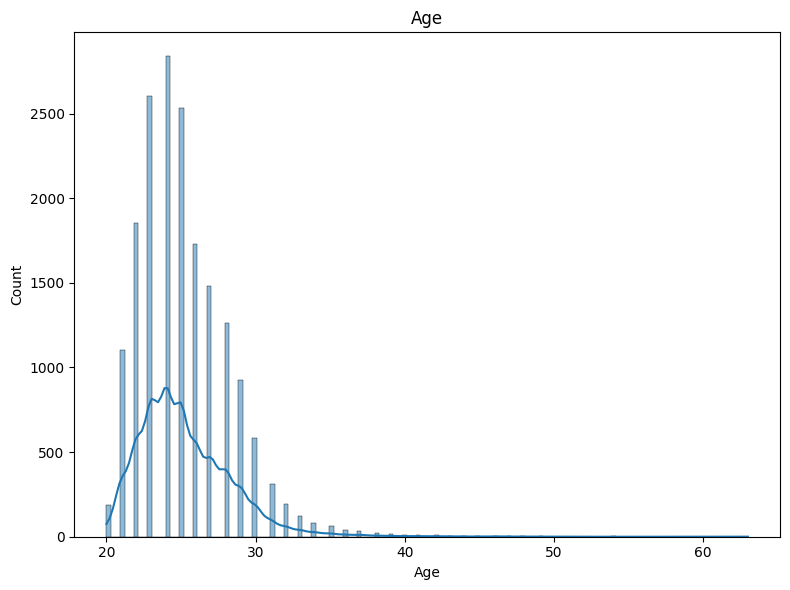

In [ ]:
# Quick EDA - to check distribution of comtinuous numerical features

plt.figure(figsize=(8, 6))

sns.histplot(
      data = X_train,
      x = X_train["Age"],
      kde = True
)
plt.title("Age")
plt.tight_layout()
plt.show()

The distribution of Age is heavily right-skewed.

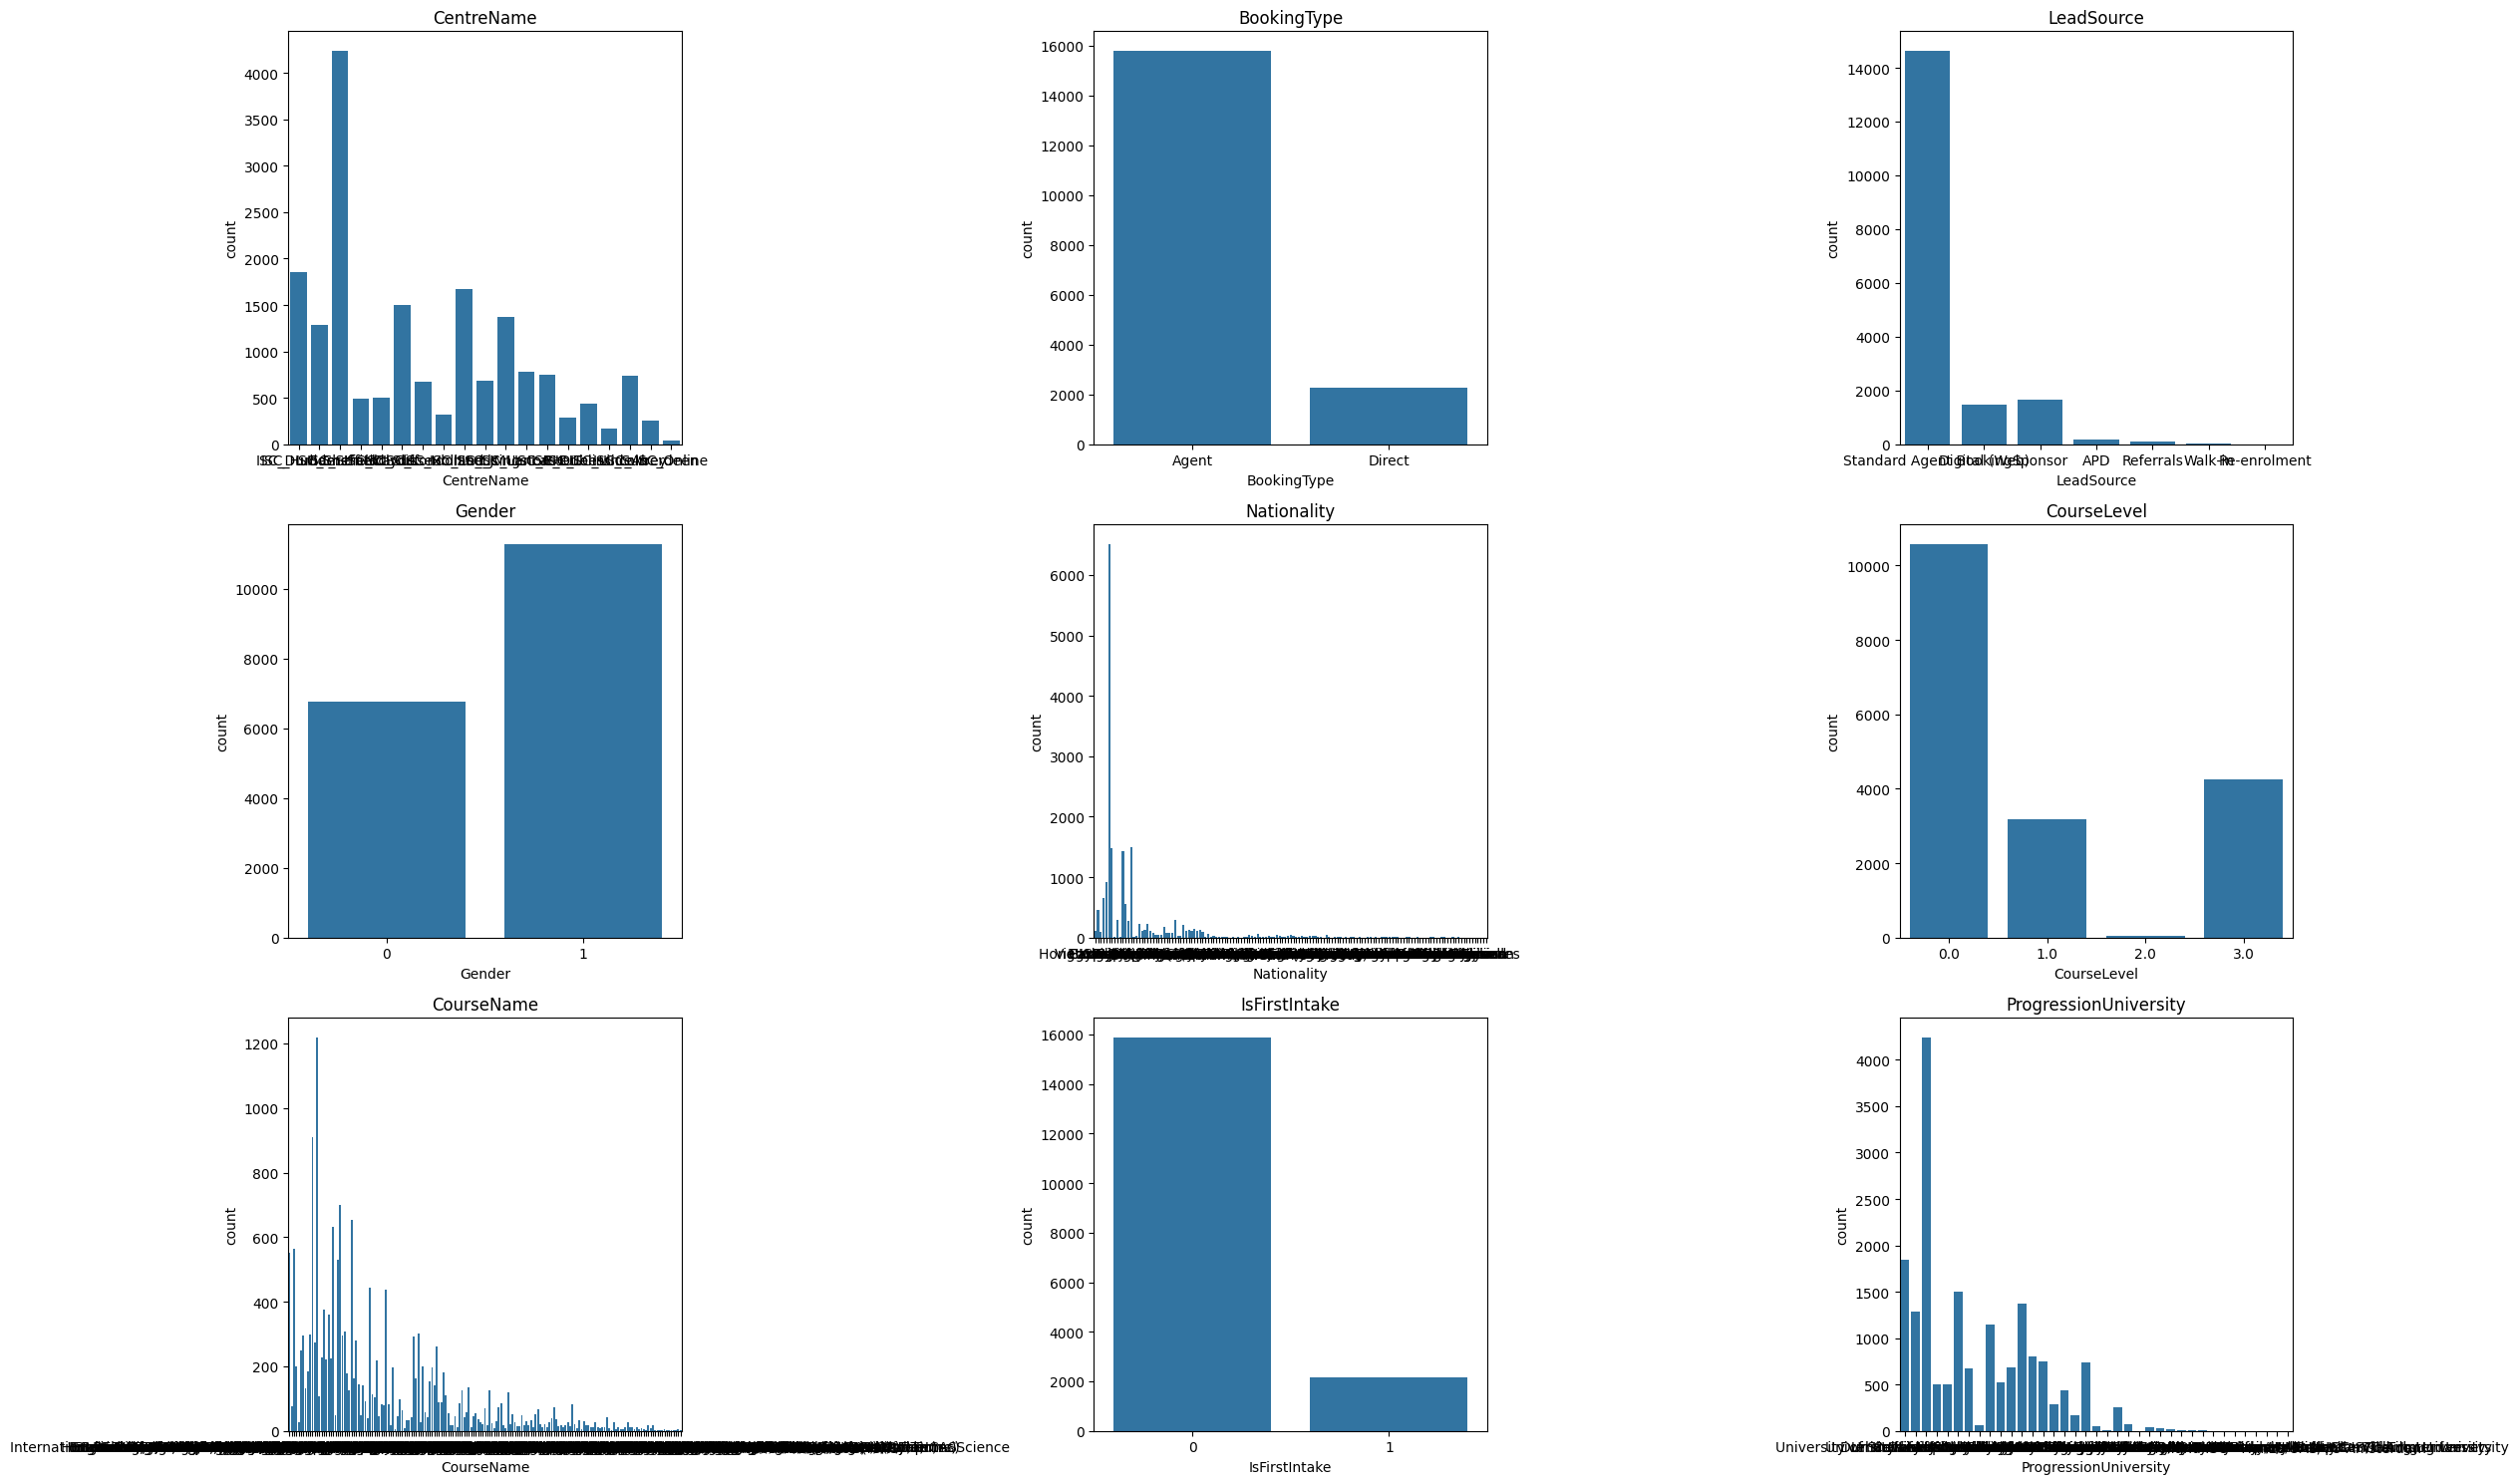

In [ ]:
# Quick EDA - bar charts to see distribution of categorical values

cat_columns = X_train.drop(columns="Age").columns

plt.figure(figsize=(25, 15))

for i, cat_column in enumerate(cat_columns):
  plt.subplot(3, 3, i+1)
  sns.countplot(
      data = X_train,
      x = X_train[cat_column],
  )
  plt.title(cat_column)

plt.tight_layout()
plt.show()

In [ ]:
# One-hot encoding for all other categorical data (that are not bool, float, or int)

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
ohe_columns = X_train.select_dtypes(include=["object"]).columns

ohe.fit(X_train[ohe_columns])

X_train_ohe = pd.DataFrame(
    ohe.transform(X_train[ohe_columns]),
    columns = ohe.get_feature_names_out(ohe_columns),
    index = X_train.index
)
X_val_ohe = pd.DataFrame(
    ohe.transform(X_val[ohe_columns]),
    columns = ohe.get_feature_names_out(ohe_columns),
    index = X_val.index
)
X_test_ohe = pd.DataFrame(
    ohe.transform(X_test[ohe_columns]),
    columns = ohe.get_feature_names_out(ohe_columns),
    index = X_test.index
)

num_cols_train = X_train.drop(columns=ohe_columns)
num_cols_val = X_val.drop(columns=ohe_columns)
num_cols_test = X_test.drop(columns=ohe_columns)

X_train = pd.concat([num_cols_train, X_train_ohe], axis=1)
X_val = pd.concat([num_cols_val, X_val_ohe], axis=1)
X_test = pd.concat([num_cols_test, X_test_ohe], axis=1)

print(f"X train shape: {X_train.shape}")
print(f"X val shape: {X_val.shape}")
print(f"X test shape: {X_test.shape}")

X_train.head()

X train shape: (18042, 377)
X val shape: (2005, 377)
X test shape: (5012, 377)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Gender,CourseLevel,IsFirstIntake,Age,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,CentreName_ISC_Kingston,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
2165,1,0.0,0,26,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5559,1,3.0,0,33,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18919,1,0.0,0,25,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
20971,0,0.0,0,23,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1031,1,1.0,0,24,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


CompletedCourse
1    85.02
0    14.98
Name: proportion, dtype: float64


<Axes: xlabel='CompletedCourse', ylabel='count'>

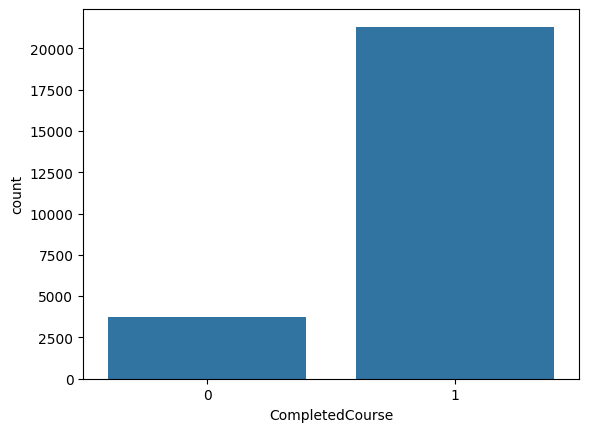

In [ ]:
# Check for imbalance in target variable data

print(y.value_counts(normalize=True).multiply(100).round(2))

sns.countplot(x=y)

The target variable is imbalanced, with 85% of students completing the course (1) and 15% not completing it (0).

**XGBoost**

In [ ]:
# Building the XGBoost model

def xgb_model(X_train, y_train, X_test, y_test, n_estimators, learning_rate, max_depth):
  xgb_model = xgb.XGBClassifier(
    random_state = 42,
    n_estimators = n_estimators,
    learning_rate = learning_rate,
    max_depth = max_depth
  )

  xgb_model.fit(X_train, y_train)

  y_pred = xgb_model.predict(X_test)
  y_prob = xgb_model.predict_proba(X_test)[:, 1] # for AUC

  print(f"XGBoost model with n_estimators: {n_estimators}, learning_rate: {learning_rate}, max_depth: {max_depth}")
  print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
  print(f"Precision: {precision_score(y_test, y_pred)}")
  print(f"Recall: {recall_score(y_test, y_pred)}")
  print(f"AUC: {roc_auc_score(y_test, y_prob)}")
  print(f"Confusion Matrix: {confusion_matrix(y_test, y_pred)}")

  sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = "d")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")

  return xgb_model

XGBoost model with n_estimators: 100, learning_rate: 0.1, max_depth: 3
Accuracy: 0.8894652833200319
Precision: 0.9127143175239367
Recall: 0.9619807556911523
AUC: 0.8739499645469969
Confusion Matrix: [[ 359  392]
 [ 162 4099]]


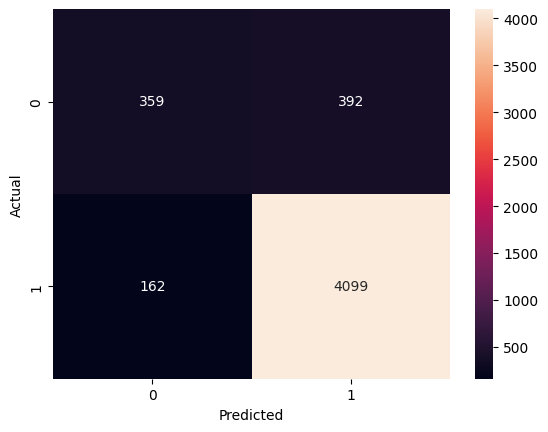

In [ ]:
# Testing the XGBoost baseline performance

xgb_model_v1 = xgb_model(X_train, y_train, X_test, y_test, n_estimators = 100, learning_rate = 0.1, max_depth = 3)

**XGBoost - Hyperparameter tuning**

As our target variable data is imbalanced, using accuracy as the primary metric to compare between models would be misleading.

We would use **AUC** as our primary metric instead, AUC would be the best overall indicator of model performance, not affected by class imbalance.

All hyperparameter tuning will be evaluated on the validation set, with the final selected model, based on highest AUC, evaluated once on the test set.

XGBoost model with n_estimators: 200, learning_rate: 0.05, max_depth: 3
Accuracy: 0.8987531172069826
Precision: 0.9149171270718232
Recall: 0.9712609970674487
AUC: 0.8900400782013685
Confusion Matrix: [[ 146  154]
 [  49 1656]]


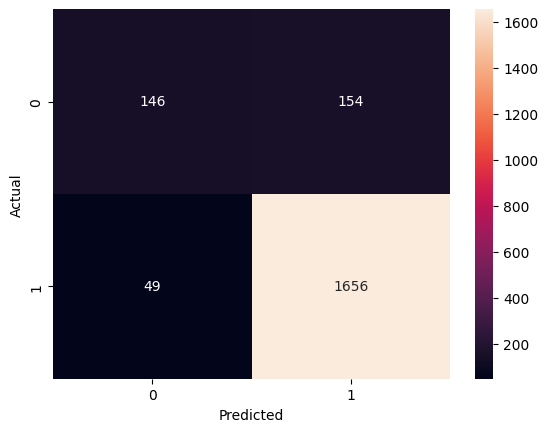

In [ ]:
xgb_model_v2 = xgb_model(X_train, y_train, X_val, y_val, n_estimators = 200, learning_rate = 0.05, max_depth = 3)

XGBoost model with n_estimators: 200, learning_rate: 0.05, max_depth: 5
Accuracy: 0.8992518703241895
Precision: 0.9163434903047092
Recall: 0.9700879765395894
AUC: 0.8996275659824047
Confusion Matrix: [[ 149  151]
 [  51 1654]]


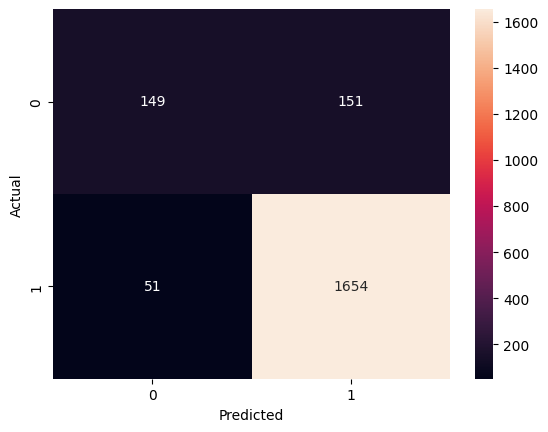

In [ ]:
xgb_model_v3 = xgb_model(X_train, y_train, X_val, y_val, n_estimators = 200, learning_rate = 0.05, max_depth = 5)

XGBoost model with n_estimators: 1500, learning_rate: 0.01, max_depth: 6
Accuracy: 0.8987531172069826
Precision: 0.9181514476614699
Recall: 0.9671554252199414
AUC: 0.9013489736070381
Confusion Matrix: [[ 153  147]
 [  56 1649]]


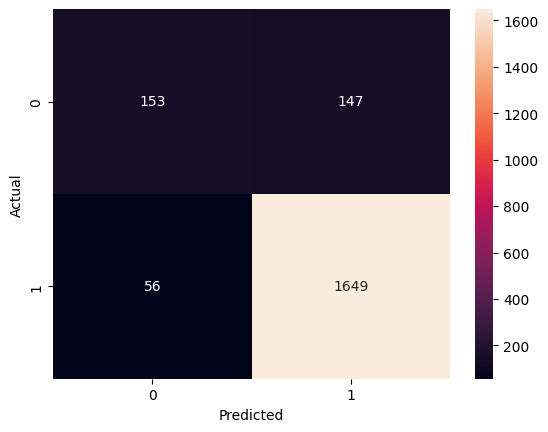

In [ ]:
xgb_model_v4 = xgb_model(X_train, y_train, X_val, y_val, n_estimators = 1500, learning_rate = 0.01, max_depth = 6)

XGBoost model with n_estimators: 3000, learning_rate: 0.01, max_depth: 6
Accuracy: 0.8992518703241895
Precision: 0.9200670765790945
Recall: 0.9653958944281525
AUC: 0.9000254154447703
Confusion Matrix: [[ 157  143]
 [  59 1646]]


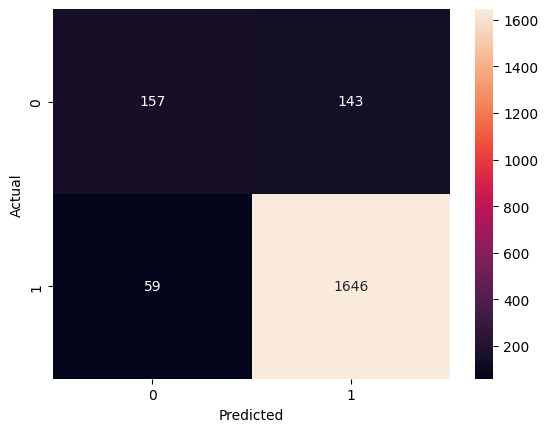

In [ ]:
xgb_model_v5 = xgb_model(X_train, y_train, X_val, y_val, n_estimators = 3000, learning_rate = 0.01, max_depth = 6)

XGBoost model with n_estimators: 5000, learning_rate: 0.005, max_depth: 4
Accuracy: 0.8997506234413966
Precision: 0.9173140954495006
Recall: 0.9695014662756598
AUC: 0.8988553274682307
Confusion Matrix: [[ 151  149]
 [  52 1653]]


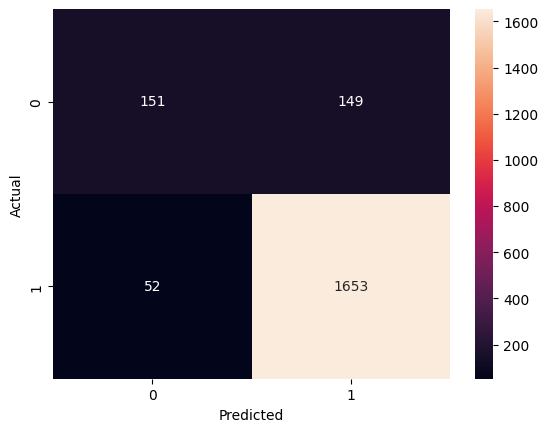

In [ ]:
xgb_model_v6 = xgb_model(X_train, y_train, X_val, y_val, n_estimators = 5000, learning_rate = 0.005, max_depth = 4)

In [ ]:
# Let's compare the tuned models (evaluated on validation set)

models = {
    "v2 on val": xgb_model_v2,
    "v3 on val": xgb_model_v3,
    "v4 on val": xgb_model_v4,
    "v5 on val": xgb_model_v5,
    "v6 on val": xgb_model_v6,
}

results = []

for name, model in models.items():

  y_prob = model.predict_proba(X_val)[:, 1]
  y_pred = model.predict(X_val)
  y_true = y_val

  tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

  results.append({
      "model": name,
      "n_estimators": model.n_estimators,
      "learning_rate": model.learning_rate,
      "max_depth": model.max_depth,
      "auc": roc_auc_score(y_true, y_prob),
      "accuracy": accuracy_score(y_true, y_pred),
      "precision": precision_score(y_true, y_pred),
      "recall": recall_score(y_true, y_pred),
      "tn": tn,
      "fp": fp,
      "fn": fn,
      "tp": tp
  })

pd.DataFrame(results)

,model,n_estimators,learning_rate,max_depth,auc,accuracy,precision,recall,tn,fp,fn,tp
0,v2 on val,200,0.050,3,0.890040,0.898753,0.914917,0.971261,146,154,49,1656
1,v3 on val,200,0.050,5,0.899628,0.899252,0.916343,0.970088,149,151,51,1654
2,v4 on val,1500,0.010,6,0.901349,0.898753,0.918151,0.967155,153,147,56,1649
3,v5 on val,3000,0.010,6,0.900025,0.899252,0.920067,0.965396,157,143,59,1646
4,v6 on val,5000,0.005,4,0.898855,0.899751,0.917314,0.969501,151,149,52,1653


We will use AUC as the primary metric, as the target variable is imbalanced

---

**v4** achieves the highest AUC at 0.9013 and is the selected best model.

Starting from v2, increasing max depth from 3 to 5 in v3 yielded a meaningful early jump. Moving to v4 with a much lower learning rate (0.01) and more estimators (1500) pushed AUC to its peak. Beyond v4 however, further increases in estimators (v5: 3000, v6: 5000) with lower learning rates did not improve performance and actually declined slightly, suggesting the model had already converged and additional complexity was unnecessary.

The overall improvement across all five versions is only around 0.011 AUC, which is marginal. This likely indicates the dataset itself has limited complexity, the features may not contain enough signal to drive substantially higher discrimination, and the model appears to have reached a performance ceiling relatively early. Further tuning beyond v4 is unlikely to produce meaningful gains without introducing new features or addressing the class imbalance.

XGBoost model with n_estimators: 1500, learning_rate: 0.01, max_depth: 6
Accuracy: 0.894852354349561
Precision: 0.9182347670250897
Recall: 0.9619807556911523
AUC: 0.8804891608185095
Confusion Matrix: [[ 386  365]
 [ 162 4099]]


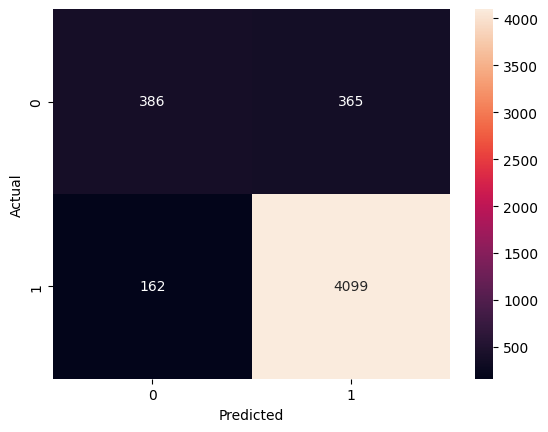

In [ ]:
# Running the v4 model on test set

xgb_model_v4 = xgb_model(X_train, y_train, X_test, y_test, n_estimators = 1500, learning_rate = 0.01, max_depth = 6)

In [ ]:
# Now we'll compare v1 (baseline model) with v4 (evaluated on the test set this time)
# Before vs after hyperparameter tuning

models = {
    "v1 on test (Baseline)": xgb_model_v1,
    "v4 on test": xgb_model_v4,
}

results = []

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    y_true = y_test

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    results.append({
        "model": name,
        "n_estimators": model.n_estimators,
        "learning_rate": model.learning_rate,
        "max_depth": model.max_depth,
        "auc": roc_auc_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

pd.DataFrame(results)

,model,n_estimators,learning_rate,max_depth,auc,accuracy,precision,recall,tn,fp,fn,tp
0,v1 on test (Baseline),100,0.10,3,0.873950,0.889465,0.912714,0.961981,359,392,162,4099
1,v4 on test,1500,0.01,6,0.880489,0.894852,0.918235,0.961981,386,365,162,4099


The baseline model (v1) achieved an AUC of 0.874 on the test set. After hyperparameter tuning, v4 improved to 0.901 on the validation set, however this dropped to 0.880 on the test set, a gap of ~0.021.

The test AUC still represents an improvement of ~0.006 over the baseline, indicating tuning did provide a modest gain in generalisation. The val/test gap suggests slight overfitting to the validation set during tuning, though the model generalises reasonably well overall.

**XGBoost - Feature Importance**

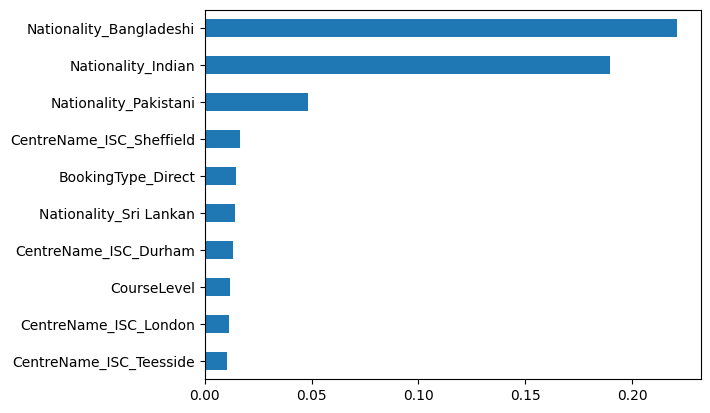

In [ ]:
# Looking into the best model - v4

feature_importance = pd.Series(xgb_model_v4.feature_importances_, index=X_train.columns).sort_values()

# To only show the top 10 most important features
feature_importance.tail(10).plot.barh()
plt.show()

The top 10 features reveal some interesting patterns:

- Nationality dominates the top 10 features, with Nationality_Bangladeshi, Nationality_Indian, and Nationality_Pakistani occupying the top 3 positions. Nationality_Bangladeshi is the most important feature at, followed closely by Nationality_Indian at ~0.20, with Nationality_Pakistani considerably lower at ~0.05. This suggests a student's nationality is the strongest predictor of course completion, which is worth investigating further as it could reflect underlying biases in the data.

- Centre location features prominently, with CentreName_ISC_Sheffield, ISC_Durham, ISC_London, and ISC_Teesside all appearing, suggesting where a student studies has some predictive power, though considerably lower than nationality.

- BookingType_Direct, Nationality_Sri Lankan, and CourseLevel round out the bottom half, indicating a modest but notable influence on predictions.

Overall the model is heavily driven by nationality, with everything else contributing relatively little by comparison, the gap between the top 3 and the rest is quite stark.

----
One limitation of XGBoost's feature importance is that it only indicates how frequently a feature was used across all trees, without revealing the direction of its effect, a highly important feature could be pushing predictions either positively or negatively.

SHAP addresses this by showing the contribution and direction of each feature for every individual prediction.

**XGBoost - SHAP**

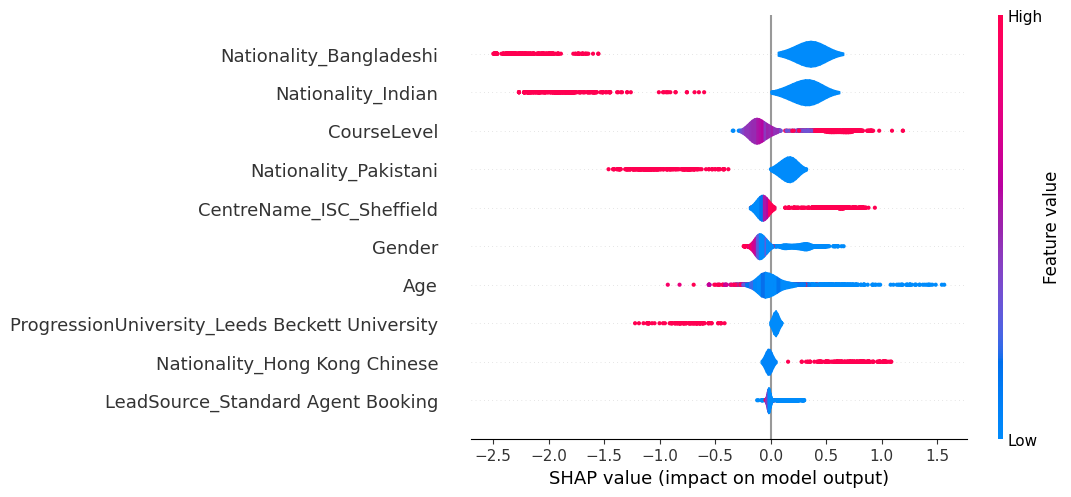

In [ ]:
import shap
shap.initjs()

shap_ex = shap.TreeExplainer(xgb_model_v4)
vals = shap_ex(X_test)

# Plotting the violing chart to see importance and direction of each feature
shap.plots.violin(vals, max_display=10)

**SHAP Violin Summary**

- Nationality_Bangladeshi and Nationality_Indian remain the top two features. The red dots on the left (negative SHAP values) confirm that being Bangladeshi or Indian pushes the prediction downwards, these students are predicted to be less likely to complete the course. The large blue clusters near zero indicate that students who are not of those nationalities have a near-neutral effect.

- CourseLevel shows red dots extending to the right (positive SHAP values), suggesting higher course levels are associated with a higher predicted probability of completing the course.

- Nationality_Pakistani shows a similar pattern to Nationality_Bangladeshi and Nationality_Indian, with red dots on the left, though the spread is less extreme than the top two.

- CentreName_ISC_Sheffield similarly has its cluster to the right, indicating studying at Sheffield positively influences predicted completion.

- Gender shows the blue cluster (low feature value = female) slightly to the right, suggesting being female is associated with a modest positive effect on predicted completion.

- Age has a wide spread with blue dots extending further right, suggesting younger students have a higher predicted probability of completing the course.

- ProgressionUniversity_Leeds Beckett University shows red dots on the left, indicating this is negatively associated with course completion.

- Nationality_Hong Kong Chinese, the blue cluster sits near zero and the red dots extend to the right, meaning being Hong Kong Chinese (high feature value) is positively associated with course completion.

- LeadSource_Standard Agent Booking, the blue cluster is slightly to the right, meaning students who are not from a standard agent booking (low feature value) have a modest positive effect on predicted completion.

---
**Comparison with Feature Importance**

Both plots agree that nationality is the dominant group of features and CourseLevel has managed to overtake Natinonality_Pakistani in terms of importance. However Gender, Age, Nationality_Hong Kong Chinese, and LeadSource_Standard Agent Booking appear in the SHAP top 10 but not in the feature importance top 10, suggesting these features have a meaningful directional impact on individual predictions despite not being heavily used in tree splits. Conversely, BookingType_Direct, Nationality_Sri Lankan, and several ISC centre names appear in feature importance but drop out of the SHAP top 10, implying they are used frequently in splits but contribute less to actual prediction magnitude.

**Neural Network**

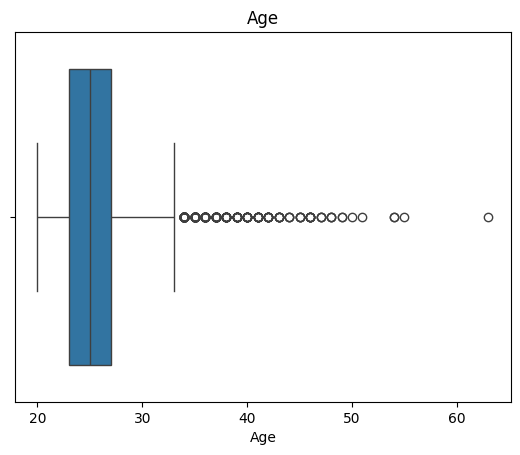

In [ ]:
# Check for outliers on numerical feature/s, before scaling

sns.boxplot(
    data = X_train,
    x = X_train["Age"]
)
plt.title("Age")
plt.show()

In [ ]:
# Scale the numerical feature first
# Using RobustScaler as our numerical feature has a lot of outliers

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train[["Age"]] = scaler.fit_transform(X_train[["Age"]])
X_val[["Age"]] = scaler.transform(X_val[["Age"]])
X_test[["Age"]] = scaler.transform(X_test[["Age"]])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.metrics import log_loss

# Building the Neural Network model

def train_nn_model(X_train, y_train, X_val, y_val, epochs, batch_size, optimizer, hidden_layers, units, eval_name = "Validation"):

  # Create the model first
  model = Sequential()

  # Input layer
  model.add(Input(
      shape = (X_train.shape[1], )
  ))

  # For loop on the hidden layers
  for _ in range(hidden_layers):
    model.add(Dense(
        units = units,
        activation = "relu"
    ))

  # Output layer
  model.add(Dense(
      units = 1,
      activation = "sigmoid"
  ))

  # Configure the model
  model.compile(
      optimizer = optimizer,
      loss = "binary_crossentropy",
      metrics = [tf.keras.metrics.AUC(name = "auc")] # use auc instead of accuracy because of target data imbalance
  )

  # Train the model
  history = model.fit(
      X_train,
      y_train,
      epochs = epochs,
      batch_size = batch_size,
      validation_data = (X_val, y_val),
      verbose = 0
  )

  # Plot loss by epoch
  plt.figure(figsize=(8, 6))
  plt.plot(history.history["loss"], label = "Train loss")
  plt.plot(history.history["val_loss"], label = f"{eval_name} loss", linestyle = "--")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title("Loss by Epoch")
  plt.legend()
  plt.show()

  # Plot auc by epoch
  plt.figure(figsize=(8, 6))
  plt.plot(history.history["auc"], label = "Train auc")
  plt.plot(history.history["val_auc"], label = f"{eval_name} auc", linestyle = "--")
  plt.xlabel("Epoch")
  plt.ylabel("AUC")
  plt.title("AUC by Epoch")
  plt.legend()
  plt.show()

  return model, history


# Another function for evaluation

def evaluate_nn_model(y_true, y_prob, threshold = 0.5):
  y_pred = (y_prob > threshold).astype(int)

  auc = roc_auc_score(y_true, y_prob)
  loss = log_loss(y_true, y_prob)
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)
  cm = confusion_matrix(y_true, y_pred)
  tn, fp, fn, tp = cm.ravel()

  print(f"Accuracy: {accuracy}")
  print(f"Precision: {precision}")
  print(f"Recall: {recall}")
  print(f"AUC: {auc}")
  print(f"Confusion Matrix:\n{cm}")

  sns.heatmap(cm, annot=True, fmt="d")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.show()

  return auc, loss, accuracy, precision, recall, tn, fp, fn, tp

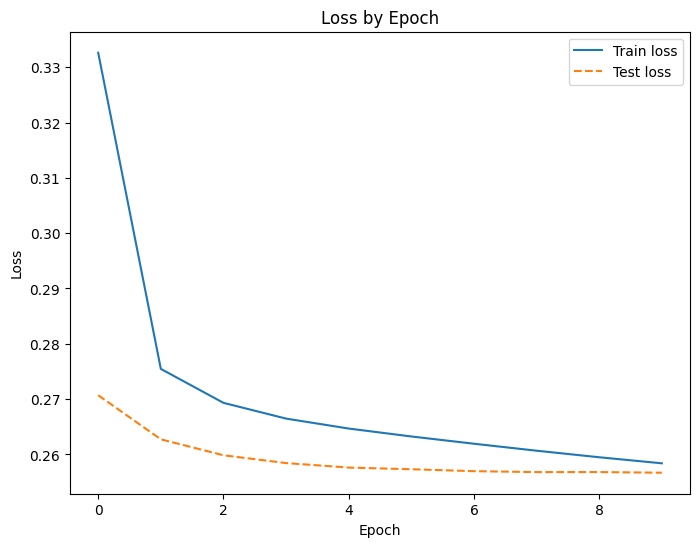

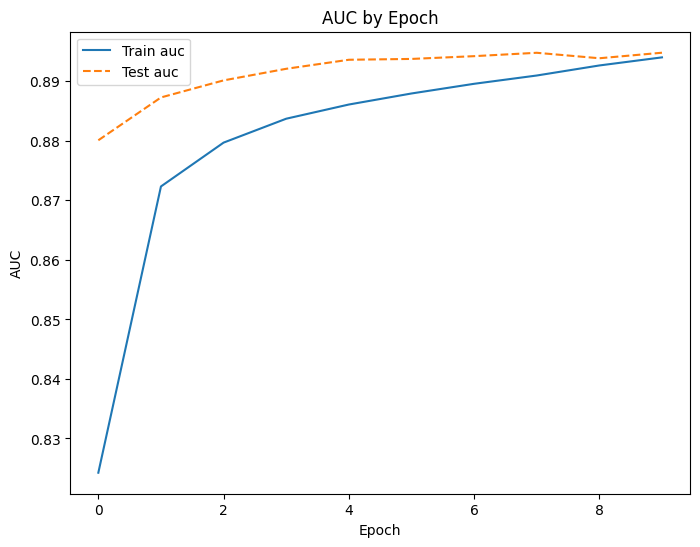

Accuracy: 0.8914604948124502
Precision: 0.9132755170113409
Recall: 0.9638582492372683
AUC: 0.8738565273681871
Confusion Matrix:
[[ 361  390]
 [ 154 4107]]


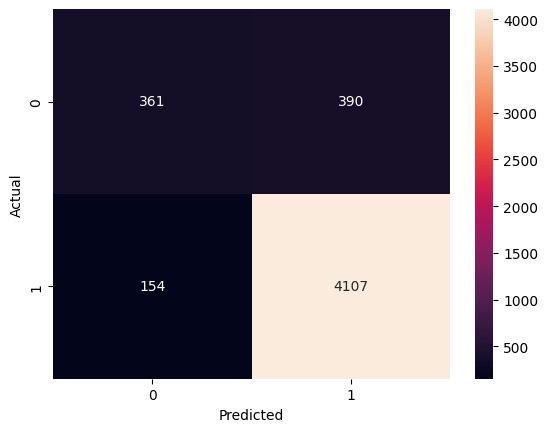

In [ ]:
# Testing the Neural Network baseline performance

nn_model_v1, history_1 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 10,
    batch_size = 32,
    optimizer = "adam",
    hidden_layers = 1,
    units = 10,
    eval_name = "Test"
)

y_test_prob_v1 = nn_model_v1.predict(X_test, verbose = 0).flatten()
auc_v1, loss_v1, accuracy_v1, precision_v1, recall_v1, tn_1, fp_1, fn_1, tp_1 = evaluate_nn_model(y_test, y_test_prob_v1)

**Neural Network - Hyperparameter tuning**

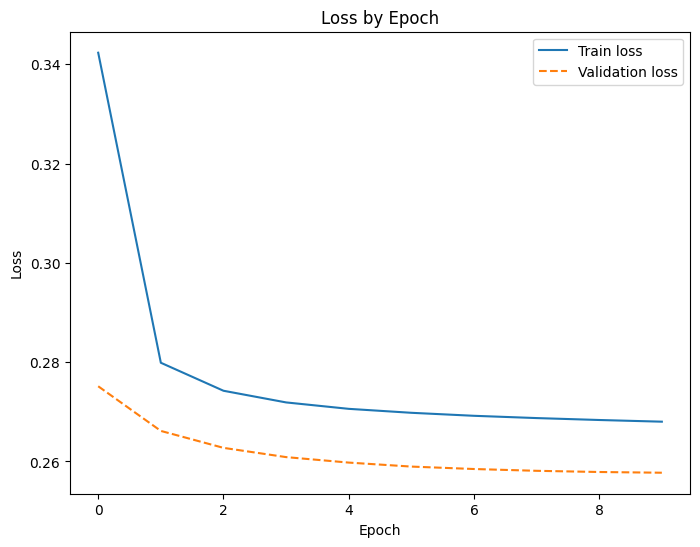

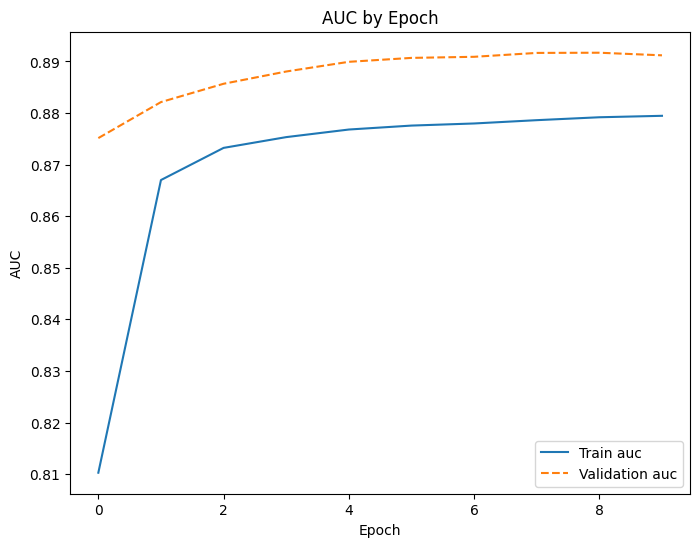

Accuracy: 0.8977556109725686
Precision: 0.9162042175360711
Recall: 0.9683284457478006
AUC: 0.8916803519061584
Confusion Matrix:
[[ 149  151]
 [  54 1651]]


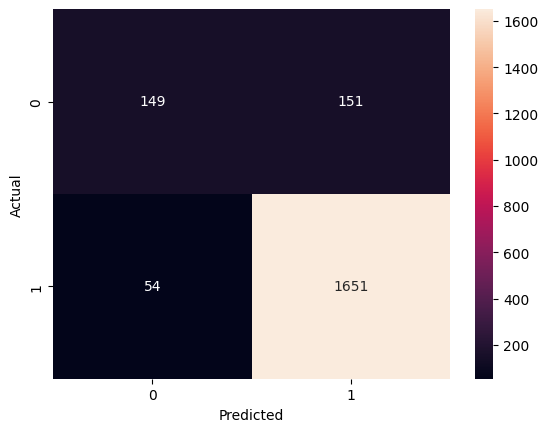

In [ ]:
nn_model_v2, history_2 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 10,
    batch_size = 32,
    optimizer = "rmsprop",
    hidden_layers = 1,
    units = 10
)

y_val_prob_v2 = nn_model_v2.predict(X_val, verbose = 0).flatten()
auc_v2, loss_v2, accuracy_v2, precision_v2, recall_v2, tn_2, fp_2, fn_2, tp_2 = evaluate_nn_model(y_val, y_val_prob_v2)

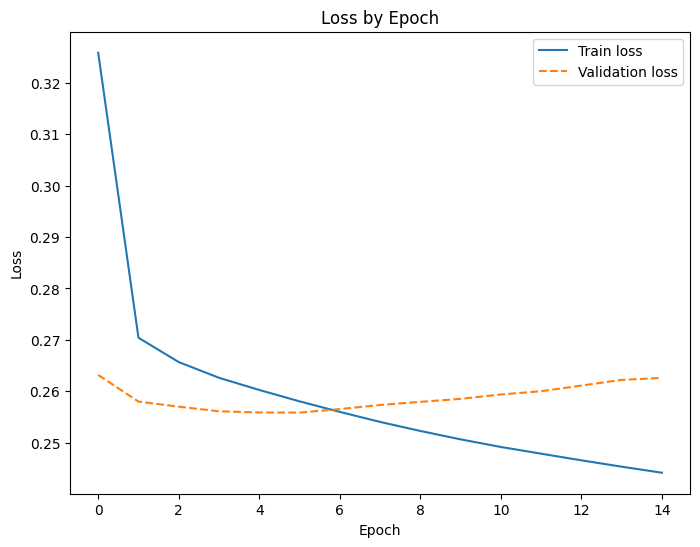

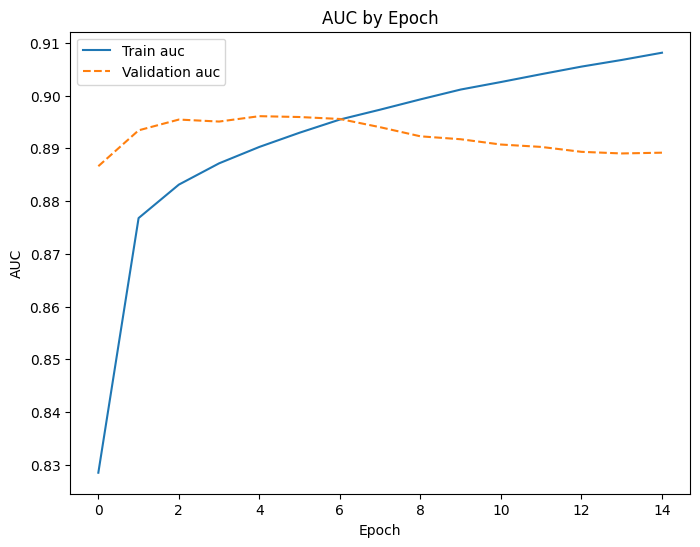

Accuracy: 0.8997506234413966
Precision: 0.916389811738649
Recall: 0.9706744868035191
AUC: 0.8890136852394918
Confusion Matrix:
[[ 149  151]
 [  50 1655]]


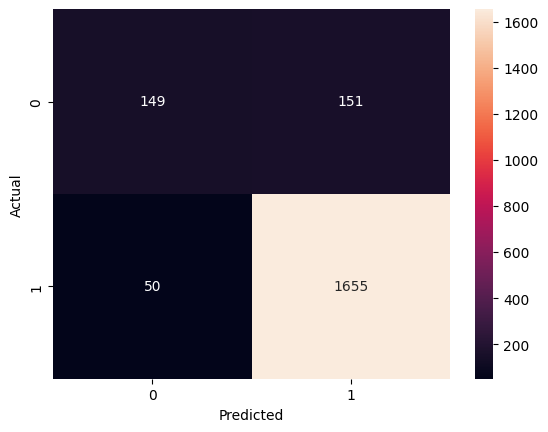

In [ ]:
nn_model_v3, history_3 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 15,
    batch_size = 32,
    optimizer = "adam",
    hidden_layers = 2,
    units = 15
)

y_val_prob_v3 = nn_model_v3.predict(X_val, verbose = 0).flatten()
auc_v3, loss_v3, accuracy_v3, precision_v3, recall_v3, tn_3, fp_3, fn_3, tp_3 = evaluate_nn_model(y_val, y_val_prob_v3)

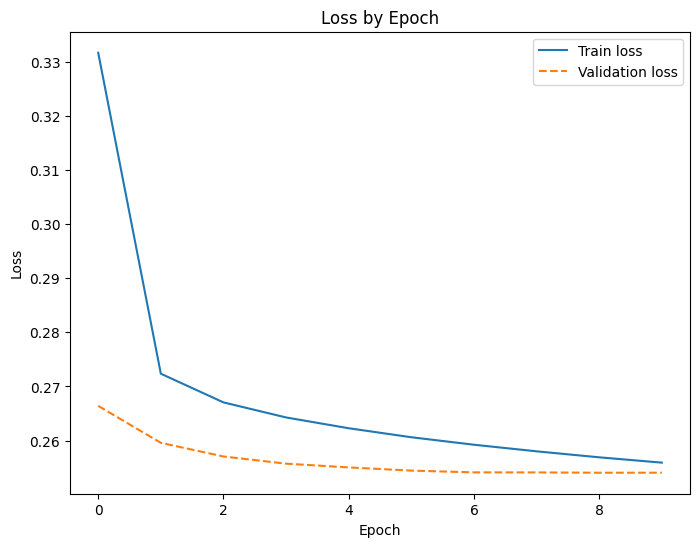

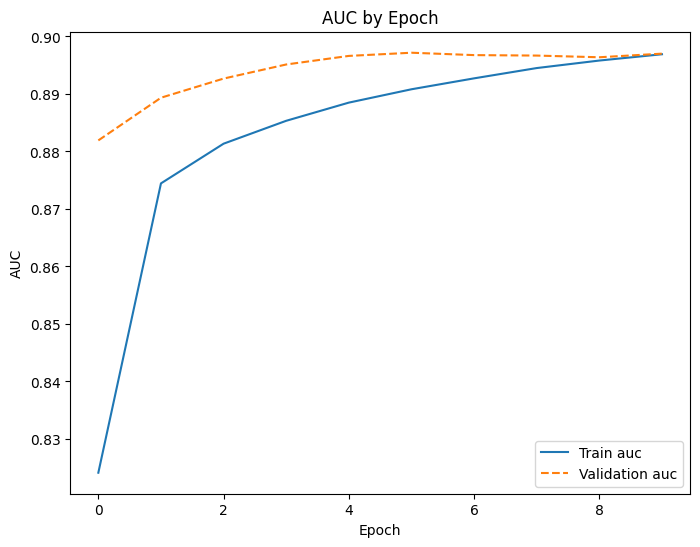

Accuracy: 0.8972568578553616
Precision: 0.9124931205283434
Recall: 0.9724340175953079
AUC: 0.8968103616813293
Confusion Matrix:
[[ 141  159]
 [  47 1658]]


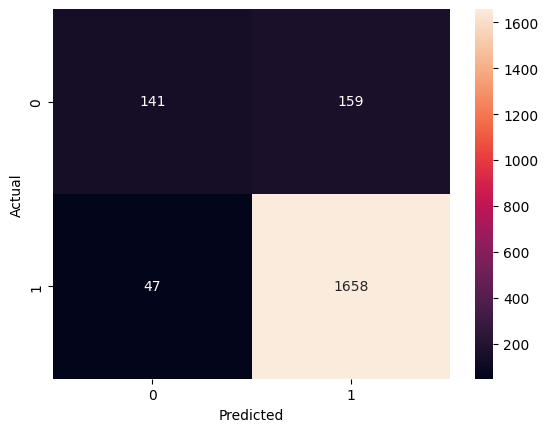

In [ ]:
nn_model_v4, history_4 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 10,
    batch_size = 16,
    optimizer = "adam",
    hidden_layers = 1,
    units = 10
)

y_val_prob_v4 = nn_model_v4.predict(X_val, verbose = 0).flatten()
auc_v4, loss_v4, accuracy_v4, precision_v4, recall_v4, tn_4, fp_4, fn_4, tp_4 = evaluate_nn_model(y_val, y_val_prob_v4)

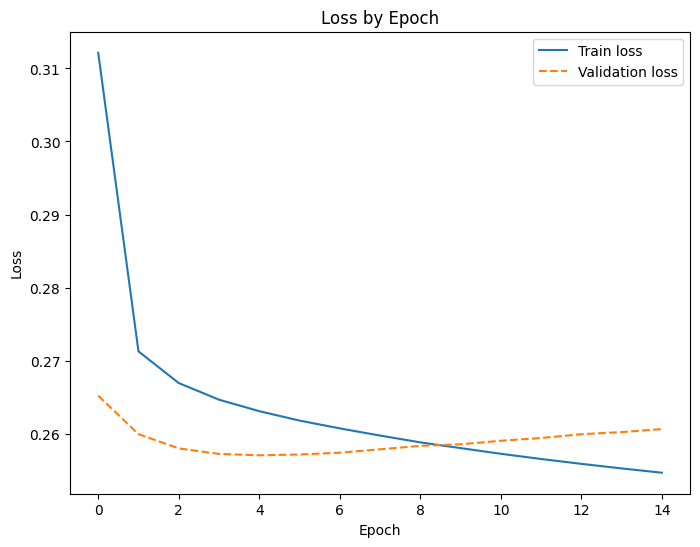

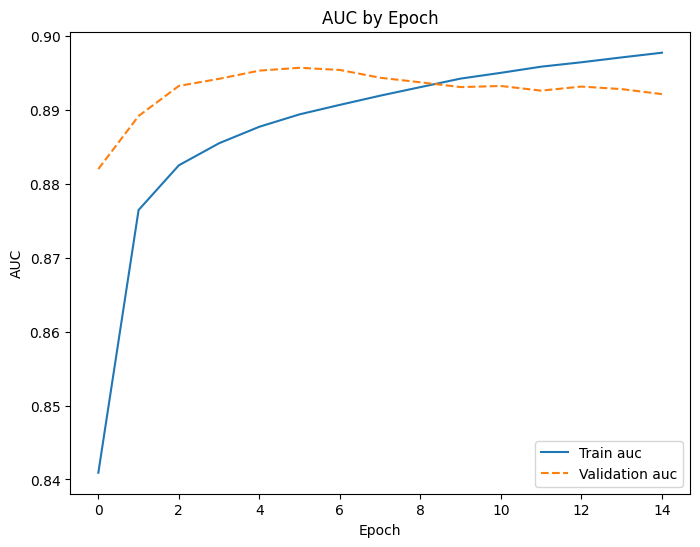

Accuracy: 0.9002493765586035
Precision: 0.915057915057915
Recall: 0.9730205278592375
AUC: 0.8920420332355816
Confusion Matrix:
[[ 146  154]
 [  46 1659]]


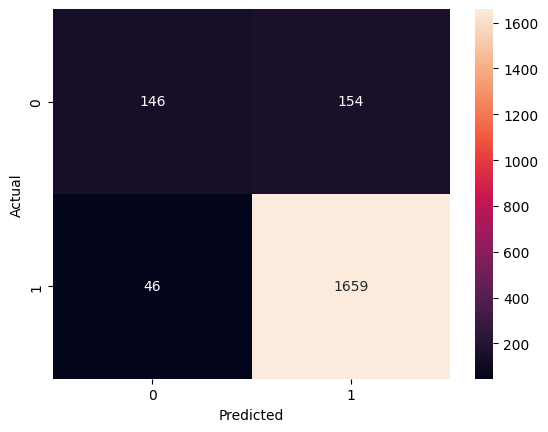

In [ ]:
nn_model_v5, history_5 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 15,
    batch_size = 16,
    optimizer = "adam",
    hidden_layers = 1,
    units = 10
)

y_val_prob_v5 = nn_model_v5.predict(X_val, verbose = 0).flatten()
auc_v5, loss_v5, accuracy_v5, precision_v5, recall_v5, tn_5, fp_5, fn_5, tp_5 = evaluate_nn_model(y_val, y_val_prob_v5)

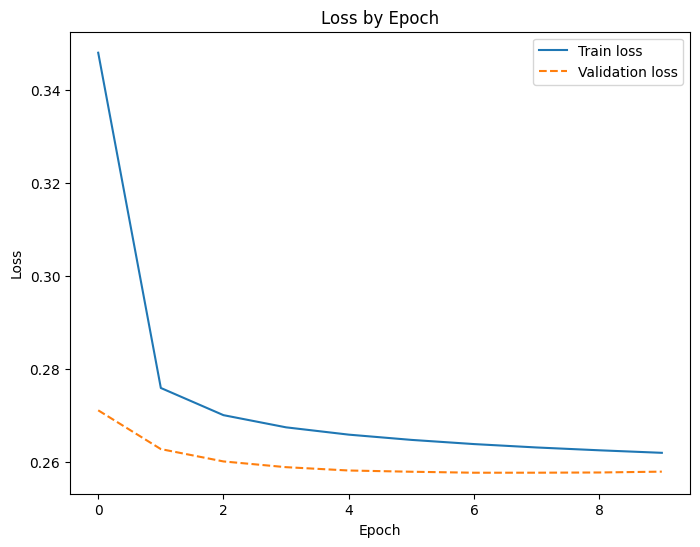

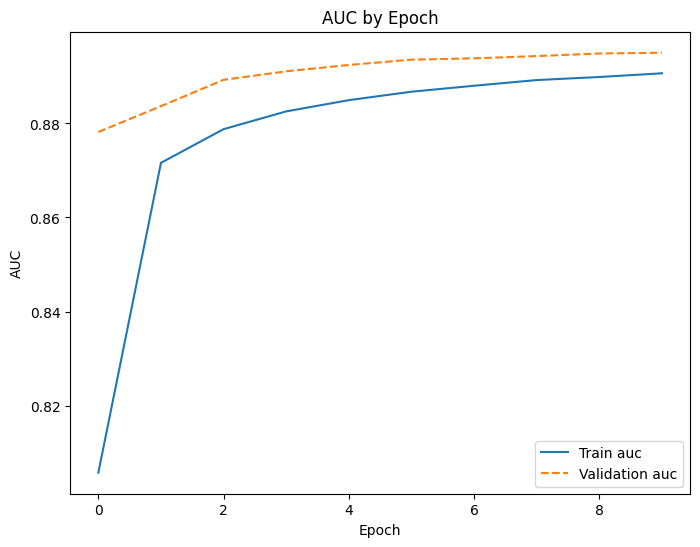

Accuracy: 0.8942643391521197
Precision: 0.9126589275843007
Recall: 0.9683284457478006
AUC: 0.8947575757575758
Confusion Matrix:
[[ 142  158]
 [  54 1651]]


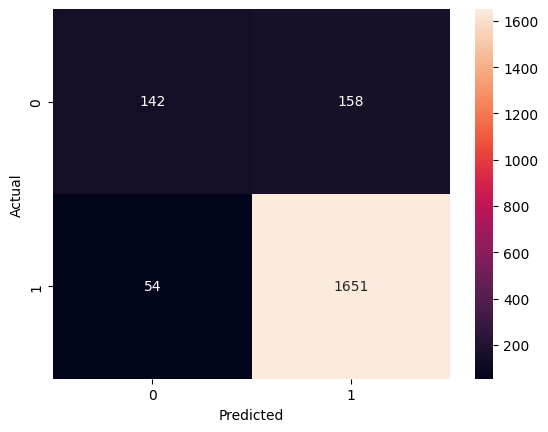

In [ ]:
nn_model_v6, history_6 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 10,
    batch_size = 16,
    optimizer = "adam",
    hidden_layers = 1,
    units = 5
)

y_val_prob_v6 = nn_model_v6.predict(X_val, verbose = 0).flatten()
auc_v6, loss_v6, accuracy_v6, precision_v6, recall_v6, tn_6, fp_6, fn_6, tp_6 = evaluate_nn_model(y_val, y_val_prob_v6)

In [ ]:
# Now, let's compare tuned models (evaluated on the validadtionn set) v2-v6

nn_results_df = pd.DataFrame([
    {"model": "v2", "epoch": 10, "optimizer": "rmsprop", "batch_size": 32, "hidden_layers": 1, "units": 10, "auc": auc_v2, "loss": loss_v2, "accuracy": accuracy_v2, "precision": precision_v2, "recall": recall_v2, "tn": tn_2, "fp": fp_2, "fn": fn_2, "tp": tp_2},
    {"model": "v3", "epoch": 15, "optimizer": "adam", "batch_size": 32, "hidden_layers": 2, "units": 15, "auc": auc_v3, "loss": loss_v3, "accuracy": accuracy_v3, "precision": precision_v3, "recall": recall_v3, "tn": tn_3, "fp": fp_3, "fn": fn_3, "tp": tp_3},
    {"model": "v4", "epoch": 10, "optimizer": "adam", "batch_size": 16, "hidden_layers": 1, "units": 10, "auc": auc_v4, "loss": loss_v4, "accuracy": accuracy_v4, "precision": precision_v4, "recall": recall_v4, "tn": tn_4, "fp": fp_4, "fn": fn_4, "tp": tp_4},
    {"model": "v5", "epoch": 15, "optimizer": "adam", "batch_size": 16, "hidden_layers": 1, "units": 10, "auc": auc_v5, "loss": loss_v5, "accuracy": accuracy_v5, "precision": precision_v5, "recall": recall_v5, "tn": tn_5, "fp": fp_5, "fn": fn_5, "tp": tp_5},
    {"model": "v6", "epoch": 10, "optimizer": "adam", "batch_size": 16, "hidden_layers": 1, "units": 5, "auc": auc_v6, "loss": loss_v6, "accuracy": accuracy_v6, "precision": precision_v6, "recall": recall_v6, "tn": tn_6, "fp": fp_6, "fn": fn_6, "tp": tp_6},
])

nn_results_df

,model,epoch,optimizer,batch_size,hidden_layers,units,auc,loss,accuracy,precision,recall,tn,fp,fn,tp
0,v2,10,rmsprop,32,1,10,0.891680,0.257736,0.897756,0.916204,0.968328,149,151,54,1651
1,v3,15,adam,32,2,15,0.889014,0.262580,0.899751,0.916390,0.970674,149,151,50,1655
2,v4,10,adam,16,1,10,0.896810,0.254052,0.897257,0.912493,0.972434,141,159,47,1658
3,v5,15,adam,16,1,10,0.892042,0.260607,0.900249,0.915058,0.973021,146,154,46,1659
4,v6,10,adam,16,1,5,0.894758,0.257850,0.894264,0.912659,0.968328,142,158,54,1651


Five configurations (v2-v6) were evaluated across epochs, optimisers, batch sizes, hidden layers, and units, with AUC as the primary metric alongside accuracy, precision, and recall.

Starting from v2 (rmsprop, AUC 0.892), switching to adam in v3 slightly decreased AUC to 0.889 despite marginally higher accuracy, suggesting adam alone was insufficient without other adjustments. Reducing batch size to 16 in v4 produced the highest AUC of 0.897 with the lowest loss of 0.254. Increasing epochs to 15 in v5 did not improve AUC, dropping back to 0.892. v6 recovered slightly to 0.895 but fell short of v4.

**v4** is selected as the best model based on AUC (0.897) and lowest loss (0.254), with 10 epochs, adam, batch size 16, 1 hidden layer and 10 units. Recall is consistently high across all versions (~0.968-0.973), reflecting the class imbalance where the model favours predicting the majority class. The overall AUC spread remains narrow at ~0.008, again pointing to a dataset-level performance ceiling.

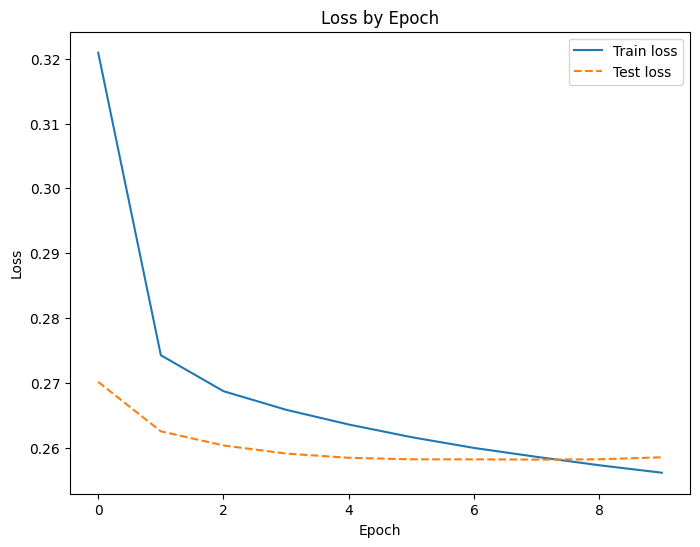

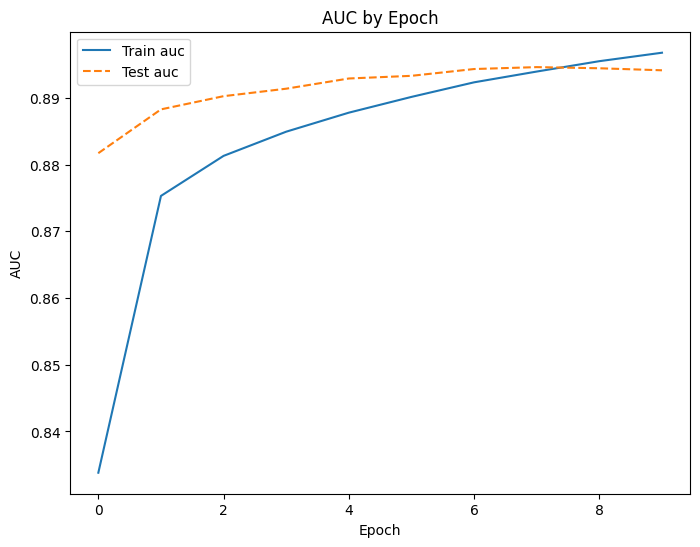

Accuracy: 0.8928571428571429
Precision: 0.9134103019538188
Recall: 0.9655010560901197
AUC: 0.8726859063921968
Confusion Matrix:
[[ 361  390]
 [ 147 4114]]


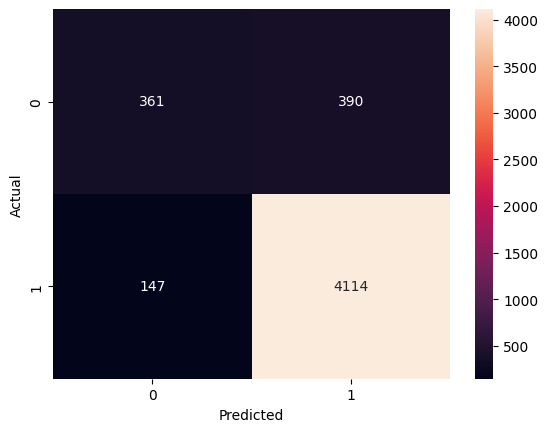

In [ ]:
# Now let's evaluate model v4 performance with the test data

nn_model_v4, history_4 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 10,
    batch_size = 16,
    optimizer = "adam",
    hidden_layers = 1,
    units = 10,
    eval_name = "Test"
)

y_test_prob_v4 = nn_model_v4.predict(X_test, verbose = 0).flatten()
auc_v4, loss_v4, accuracy_v4, precision_v4, recall_v4, tn_4, fp_4, fn_4, tp_4 = evaluate_nn_model(y_test, y_test_prob_v4)

In [ ]:
# Let's compare v1 (baseline model) with v4 (evaluated on the test set this time)
# Before vs after hyperparameter tuning

nn_comparison_df = pd.DataFrame([
    {"model": "v1", "epoch": 10, "optimizer": "adam", "batch_size": 32, "hidden_layers": 1, "units": 10, "auc": auc_v1, "loss": loss_v1, "accuracy": accuracy_v1, "precision": precision_v1, "recall": recall_v1, "tn": tn_1, "fp": fp_1, "fn": fn_1, "tp": tp_1},
    {"model": "v4", "epoch": 10, "optimizer": "adam", "batch_size": 16, "hidden_layers": 1, "units": 10, "auc": auc_v4, "loss": loss_v4, "accuracy": accuracy_v4, "precision": precision_v4, "recall": recall_v4, "tn": tn_4, "fp": fp_4, "fn": fn_4, "tp": tp_4},
])

nn_comparison_df

,model,epoch,optimizer,batch_size,hidden_layers,units,auc,loss,accuracy,precision,recall,tn,fp,fn,tp
0,v1,10,adam,32,1,10,0.873857,0.278002,0.891460,0.913276,0.963858,361,390,154,4107
1,v4,10,adam,16,1,10,0.872686,0.281285,0.892857,0.913410,0.965501,361,390,147,4114


The baseline model (v1) achieved an AUC of 0.874 on the test set. After hyperparameter tuning, v4 improved to 0.897 on the validation set, however this dropped to 0.873 on the test set, falling marginally below the baseline by ~0.001.

This suggests that while tuning improved validation performance, it did not translate to meaningful gains on unseen data, indicating slight overfitting to the validation set during tuning. The near-identical test AUC between v1 and v4 points again to a dataset-level performance ceiling rather than a shortcoming of the tuning process.

# Stage 2 data

In [ ]:
# File URL
file_url_2 = "https://drive.google.com/uc?id=1vy1JFQZva3lhMJQV69C43AB1NTM4W-DZ"

**Stage 2: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.



In [ ]:
# Start coding from here with Stage 2 dataset

# Read the data for Stage 2
df_s2 = pd.read_csv(file_url_2)

print(df_s2.shape)
df_s2.head()

(25059, 18)


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen,93.0,5.0
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen,92.0,6.0
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen,67.0,15.0
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen,NaN,NaN


In [ ]:
# Check the info

df_s2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CentreName                25059 non-null  object 
 1   LearnerCode               25059 non-null  int64  
 2   BookingType               25059 non-null  object 
 3   LeadSource                25059 non-null  object 
 4   DiscountType              7595 non-null   object 
 5   DateofBirth               25059 non-null  object 
 6   Gender                    25059 non-null  object 
 7   Nationality               25059 non-null  object 
 8   HomeState                 8925 non-null   object 
 9   HomeCity                  21611 non-null  object 
 10  CourseLevel               25059 non-null  object 
 11  CourseName                25059 non-null  object 
 12  IsFirstIntake             25059 non-null  bool   
 13  CompletedCourse           25059 non-null  object 
 14  Progre

In [ ]:
# Check for duplicates

df_s2.duplicated().sum()

np.int64(0)

In [ ]:
df_s2.isnull().sum()

,0
CentreName,0
LearnerCode,0
BookingType,0
LeadSource,0
DiscountType,17464
DateofBirth,0
Gender,0
Nationality,0
HomeState,16134
HomeCity,3448


In [ ]:
# Check for cardinality

for column in df_s2.columns:
  print(f"Number of unique values in {column}: {df_s2[column].nunique()}")

Number of unique values in CentreName: 19
Number of unique values in LearnerCode: 24877
Number of unique values in BookingType: 2
Number of unique values in LeadSource: 7
Number of unique values in DiscountType: 11
Number of unique values in DateofBirth: 4705
Number of unique values in Gender: 2
Number of unique values in Nationality: 151
Number of unique values in HomeState: 2448
Number of unique values in HomeCity: 5881
Number of unique values in CourseLevel: 4
Number of unique values in CourseName: 172
Number of unique values in IsFirstIntake: 2
Number of unique values in CompletedCourse: 2
Number of unique values in ProgressionDegree: 2616
Number of unique values in ProgressionUniversity: 40
Number of unique values in AuthorisedAbsenceCount: 190
Number of unique values in UnauthorisedAbsenceCount: 258


**Feature Engineering**

In [ ]:
# Convert DateofBirth into Age

# Set a cut-off date for consistency and reproducibility
today = "2026-03-07"

df_s2["DateofBirth"] = pd.to_datetime(df_s2["DateofBirth"])
df_s2["Age"] = (pd.to_datetime(today) - df_s2["DateofBirth"]).dt.days // 365

df_s2 = df_s2.drop(columns = ["DateofBirth"])

df_s2.head()

/tmp/ipykernel_1244/3580483986.py:6: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_s2["DateofBirth"] = pd.to_datetime(df_s2["DateofBirth"])


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN,28
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen,93.0,5.0,28
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen,92.0,6.0,25
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen,67.0,15.0,26
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen,NaN,NaN,29


**Data Preprocessing**

In [ ]:
# Check for caridnality again before dropping columns

for column in df_s2.columns:
  print(f"Number of unique values in {column}: {df_s2[column].nunique()}")

Number of unique values in CentreName: 19
Number of unique values in LearnerCode: 24877
Number of unique values in BookingType: 2
Number of unique values in LeadSource: 7
Number of unique values in DiscountType: 11
Number of unique values in Gender: 2
Number of unique values in Nationality: 151
Number of unique values in HomeState: 2448
Number of unique values in HomeCity: 5881
Number of unique values in CourseLevel: 4
Number of unique values in CourseName: 172
Number of unique values in IsFirstIntake: 2
Number of unique values in CompletedCourse: 2
Number of unique values in ProgressionDegree: 2616
Number of unique values in ProgressionUniversity: 40
Number of unique values in AuthorisedAbsenceCount: 190
Number of unique values in UnauthorisedAbsenceCount: 258
Number of unique values in Age: 38


In [ ]:
# Drop column that is not useful in analysis

df_s2 = df_s2.drop(columns = ["LearnerCode"])


# Drop categorical columns with high cardinality (>200 unique values)

for column in df_s2.columns:
  if df_s2[column].nunique() > 200:
    df_s2 = df_s2.drop(columns = [column])


# Drop columns with >50% missing

for column in df_s2.columns:
  if df_s2[column].isnull().sum() > 0.5 * len(df_s2):
    df_s2 = df_s2.drop(columns = [column])


print(df_s2.shape)
df_s2.head()

(25059, 12)


,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionUniversity,AuthorisedAbsenceCount,Age
0,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,University of Aberdeen,NaN,28
1,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,University of Aberdeen,93.0,28
2,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,International Year Two,Business Management and Finance International ...,False,Yes,University of Aberdeen,92.0,25
3,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,International Year Two,Business Management and Finance International ...,True,Yes,University of Aberdeen,67.0,26
4,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,University of Aberdeen,NaN,29


In [ ]:
# Check again for nulls

df_s2.isnull().sum()

,0
CentreName,0
BookingType,0
LeadSource,0
Gender,0
Nationality,0
CourseLevel,0
CourseName,0
IsFirstIntake,0
CompletedCourse,0
ProgressionUniversity,0


Quick comment: Compared to Stage 1 data, I can see there's a new feature - "AuthorisedAbsenceCount"

In [ ]:
# Check whether missing values in AuthorisedAbsenceCount is <2% of the overall data

AuthorisedAbsenceCount_null_proportion = df_s2["AuthorisedAbsenceCount"].isnull().sum()/len(df_s2)*100

print(f"Proportion of missing values in AuthorisedAbsenceCount: {AuthorisedAbsenceCount_null_proportion:.2f}%")

Proportion of missing values in AuthorisedAbsenceCount: 0.83%


In [ ]:
# Let's remove the null rows first before doing any encoding

df_s2 = df_s2.dropna(subset=["AuthorisedAbsenceCount"])

print(df_s2.shape)
df_s2.isnull().sum()

(24851, 12)


,0
CentreName,0
BookingType,0
LeadSource,0
Gender,0
Nationality,0
CourseLevel,0
CourseName,0
IsFirstIntake,0
CompletedCourse,0
ProgressionUniversity,0


In [ ]:
# No nulls left, now let's split data into predictors and target

X = df_s2.drop(columns = ["CompletedCourse"])
y = df_s2["CompletedCourse"]

print(X.shape)
print(y.shape)

(24851, 11)
(24851,)


In [ ]:
# Label Encode the target variable

y = y.map({"Yes": 1, "No": 0})

y.head()

,CompletedCourse
1,1
2,1
3,1
5,1
6,0


In [ ]:
# Check for unique values before encoding, to determine ordinal or not

for column in X.columns:
  print(f"Unique values in {column}: {X[column].unique()}\n")

Unique values in CentreName: ['ISC_Aberdeen' 'ISC_Cardiff' 'ISC_Dublin' 'ISC_Durham' 'ISC_Holland'
 'ISC_Huddersfield' 'ISC_Kingston' 'ISC_LJMU' 'ISC_Lancaster' 'ISC_Leeds'
 'ISC_Lincoln' 'ISC_London' 'ISC_Online' 'ISC_RHUL' 'ISC_Sheffield'
 'ISC_Strathclyde' 'ISC_Surrey' 'ISC_Sussex' 'ISC_Teesside']

Unique values in BookingType: ['Agent' 'Direct']

Unique values in LeadSource: ['Standard Agent Booking' 'Sponsor' 'APD' 'Digital (Web)' 'Referrals'
 'Walk-in' 'Re-enrolment']

Unique values in Gender: ['Male' 'Female']

Unique values in Nationality: ['Chinese' 'Iraqi' 'Kenyan' 'British' 'Kazakhstani' 'Taiwanese' 'Lebanese'
 'Kuwaiti' 'Qatari' 'Vietnamese' 'Egyptian' 'Emirati' 'Hong Kong Chinese'
 'Nigerian' 'Myanmarian' 'Singaporean' 'Bahraini' 'Japanese' 'Libyan'
 'Jordanian' 'Saudi' 'Angolan' 'Indian' 'Bangladeshi' 'Namibian'
 'Zimbabwean' 'Ghanaian' 'American' 'Omani' 'Senegalese' 'Brazilian'
 'Turkish' 'Mexican' 'Peruvian' 'Mozambican' 'Syrian' 'Pakistani'
 'Mauritanian' 'German' 'Af

**Train-test split**

In [ ]:
# 80/20 train - test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# 10% of the training data as validaiton data
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size = 0.1,
    random_state = 42,
    stratify = y_train_full
)

Splitting the data into train, validation, and test data here is ***extremely crucial*** to avoid data leakage

**Data Preprocessing - Continued**

In [ ]:
# Ordinal encoding for ordinal data.

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

oe = OrdinalEncoder(
    categories=[[
        "Foundation",
        "International Year One",
        "International Year Two",
        "Pre-Masters"
    ]]
)

oe.fit(X_train[["CourseLevel"]])

# Transform all datasets
X_train["CourseLevel"] = oe.transform(X_train[["CourseLevel"]])
X_val["CourseLevel"] = oe.transform(X_val[["CourseLevel"]])
X_test["CourseLevel"] = oe.transform(X_test[["CourseLevel"]])

X_train.head()

,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,ProgressionUniversity,AuthorisedAbsenceCount,Age
5723,ISC_Huddersfield,Agent,Standard Agent Booking,Female,American,0.0,International Foundation Year Health and Human...,False,University of Huddersfield,21.0,22
15820,ISC_Sheffield,Agent,Standard Agent Booking,Male,Chinese,0.0,Business; Social Sciences and Humanities Found...,False,University of Sheffield International College,0.0,25
5735,ISC_Huddersfield,Agent,Standard Agent Booking,Male,Bangladeshi,1.0,International Year One Engineering and Compute...,False,University of Huddersfield,0.0,30
3470,ISC_Durham,Agent,Standard Agent Booking,Male,Chinese,3.0,Business; Economics; Accounting and Finance Pr...,False,Durham University,9.0,27
20608,ISC_Strathclyde,Agent,Sponsor,Male,Saudi,0.0,Engineering and Sciences Undergraduate Foundat...,False,University of Strathclyde,81.0,37


In [ ]:
# Convert IsFirstIntake and Gender to binary values

first_intake_map = {True: 1, False: 0}
gender_map = {"Male": 1, "Female": 0}

# Apply to datasets
for df in [X_train, X_val, X_test]:
    df["IsFirstIntake"] = df["IsFirstIntake"].map(first_intake_map)
    df["Gender"] = df["Gender"].map(gender_map)

X_train.head()

,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,ProgressionUniversity,AuthorisedAbsenceCount,Age
5723,ISC_Huddersfield,Agent,Standard Agent Booking,0,American,0.0,International Foundation Year Health and Human...,0,University of Huddersfield,21.0,22
15820,ISC_Sheffield,Agent,Standard Agent Booking,1,Chinese,0.0,Business; Social Sciences and Humanities Found...,0,University of Sheffield International College,0.0,25
5735,ISC_Huddersfield,Agent,Standard Agent Booking,1,Bangladeshi,1.0,International Year One Engineering and Compute...,0,University of Huddersfield,0.0,30
3470,ISC_Durham,Agent,Standard Agent Booking,1,Chinese,3.0,Business; Economics; Accounting and Finance Pr...,0,Durham University,9.0,27
20608,ISC_Strathclyde,Agent,Sponsor,1,Saudi,0.0,Engineering and Sciences Undergraduate Foundat...,0,University of Strathclyde,81.0,37


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24851 entries, 1 to 25058
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CentreName              24851 non-null  object 
 1   BookingType             24851 non-null  object 
 2   LeadSource              24851 non-null  object 
 3   Gender                  24851 non-null  object 
 4   Nationality             24851 non-null  object 
 5   CourseLevel             24851 non-null  object 
 6   CourseName              24851 non-null  object 
 7   IsFirstIntake           24851 non-null  bool   
 8   ProgressionUniversity   24851 non-null  object 
 9   AuthorisedAbsenceCount  24851 non-null  float64
 10  Age                     24851 non-null  int64  
dtypes: bool(1), float64(1), int64(1), object(8)
memory usage: 2.1+ MB


**Quick EDA**

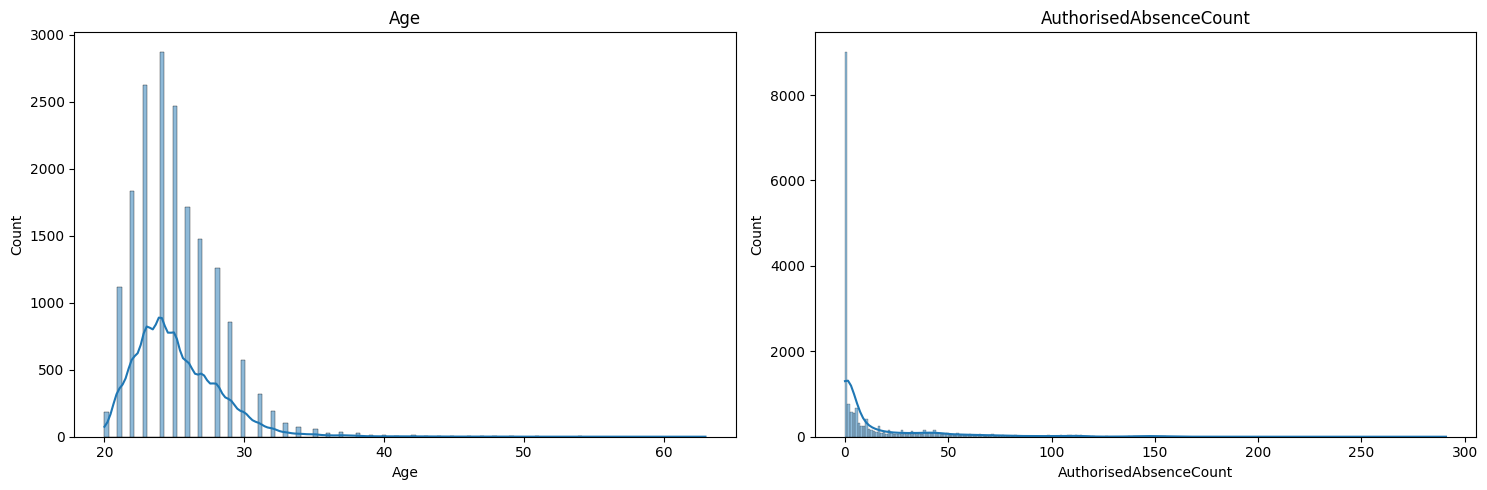

In [ ]:
# Quick EDA - to check distribution of comtinuous numerical features

num_columns = X_train[["Age", "AuthorisedAbsenceCount"]]

plt.figure(figsize=(15, 5))

for i, num_column in enumerate(num_columns):
  plt.subplot(1, 2, i+1)
  sns.histplot(
      data = X_train,
      x = X_train[num_column],
      kde = True
  )

  plt.title(num_column)

plt.tight_layout()
plt.show()

The numerical features are heavily right-skewed

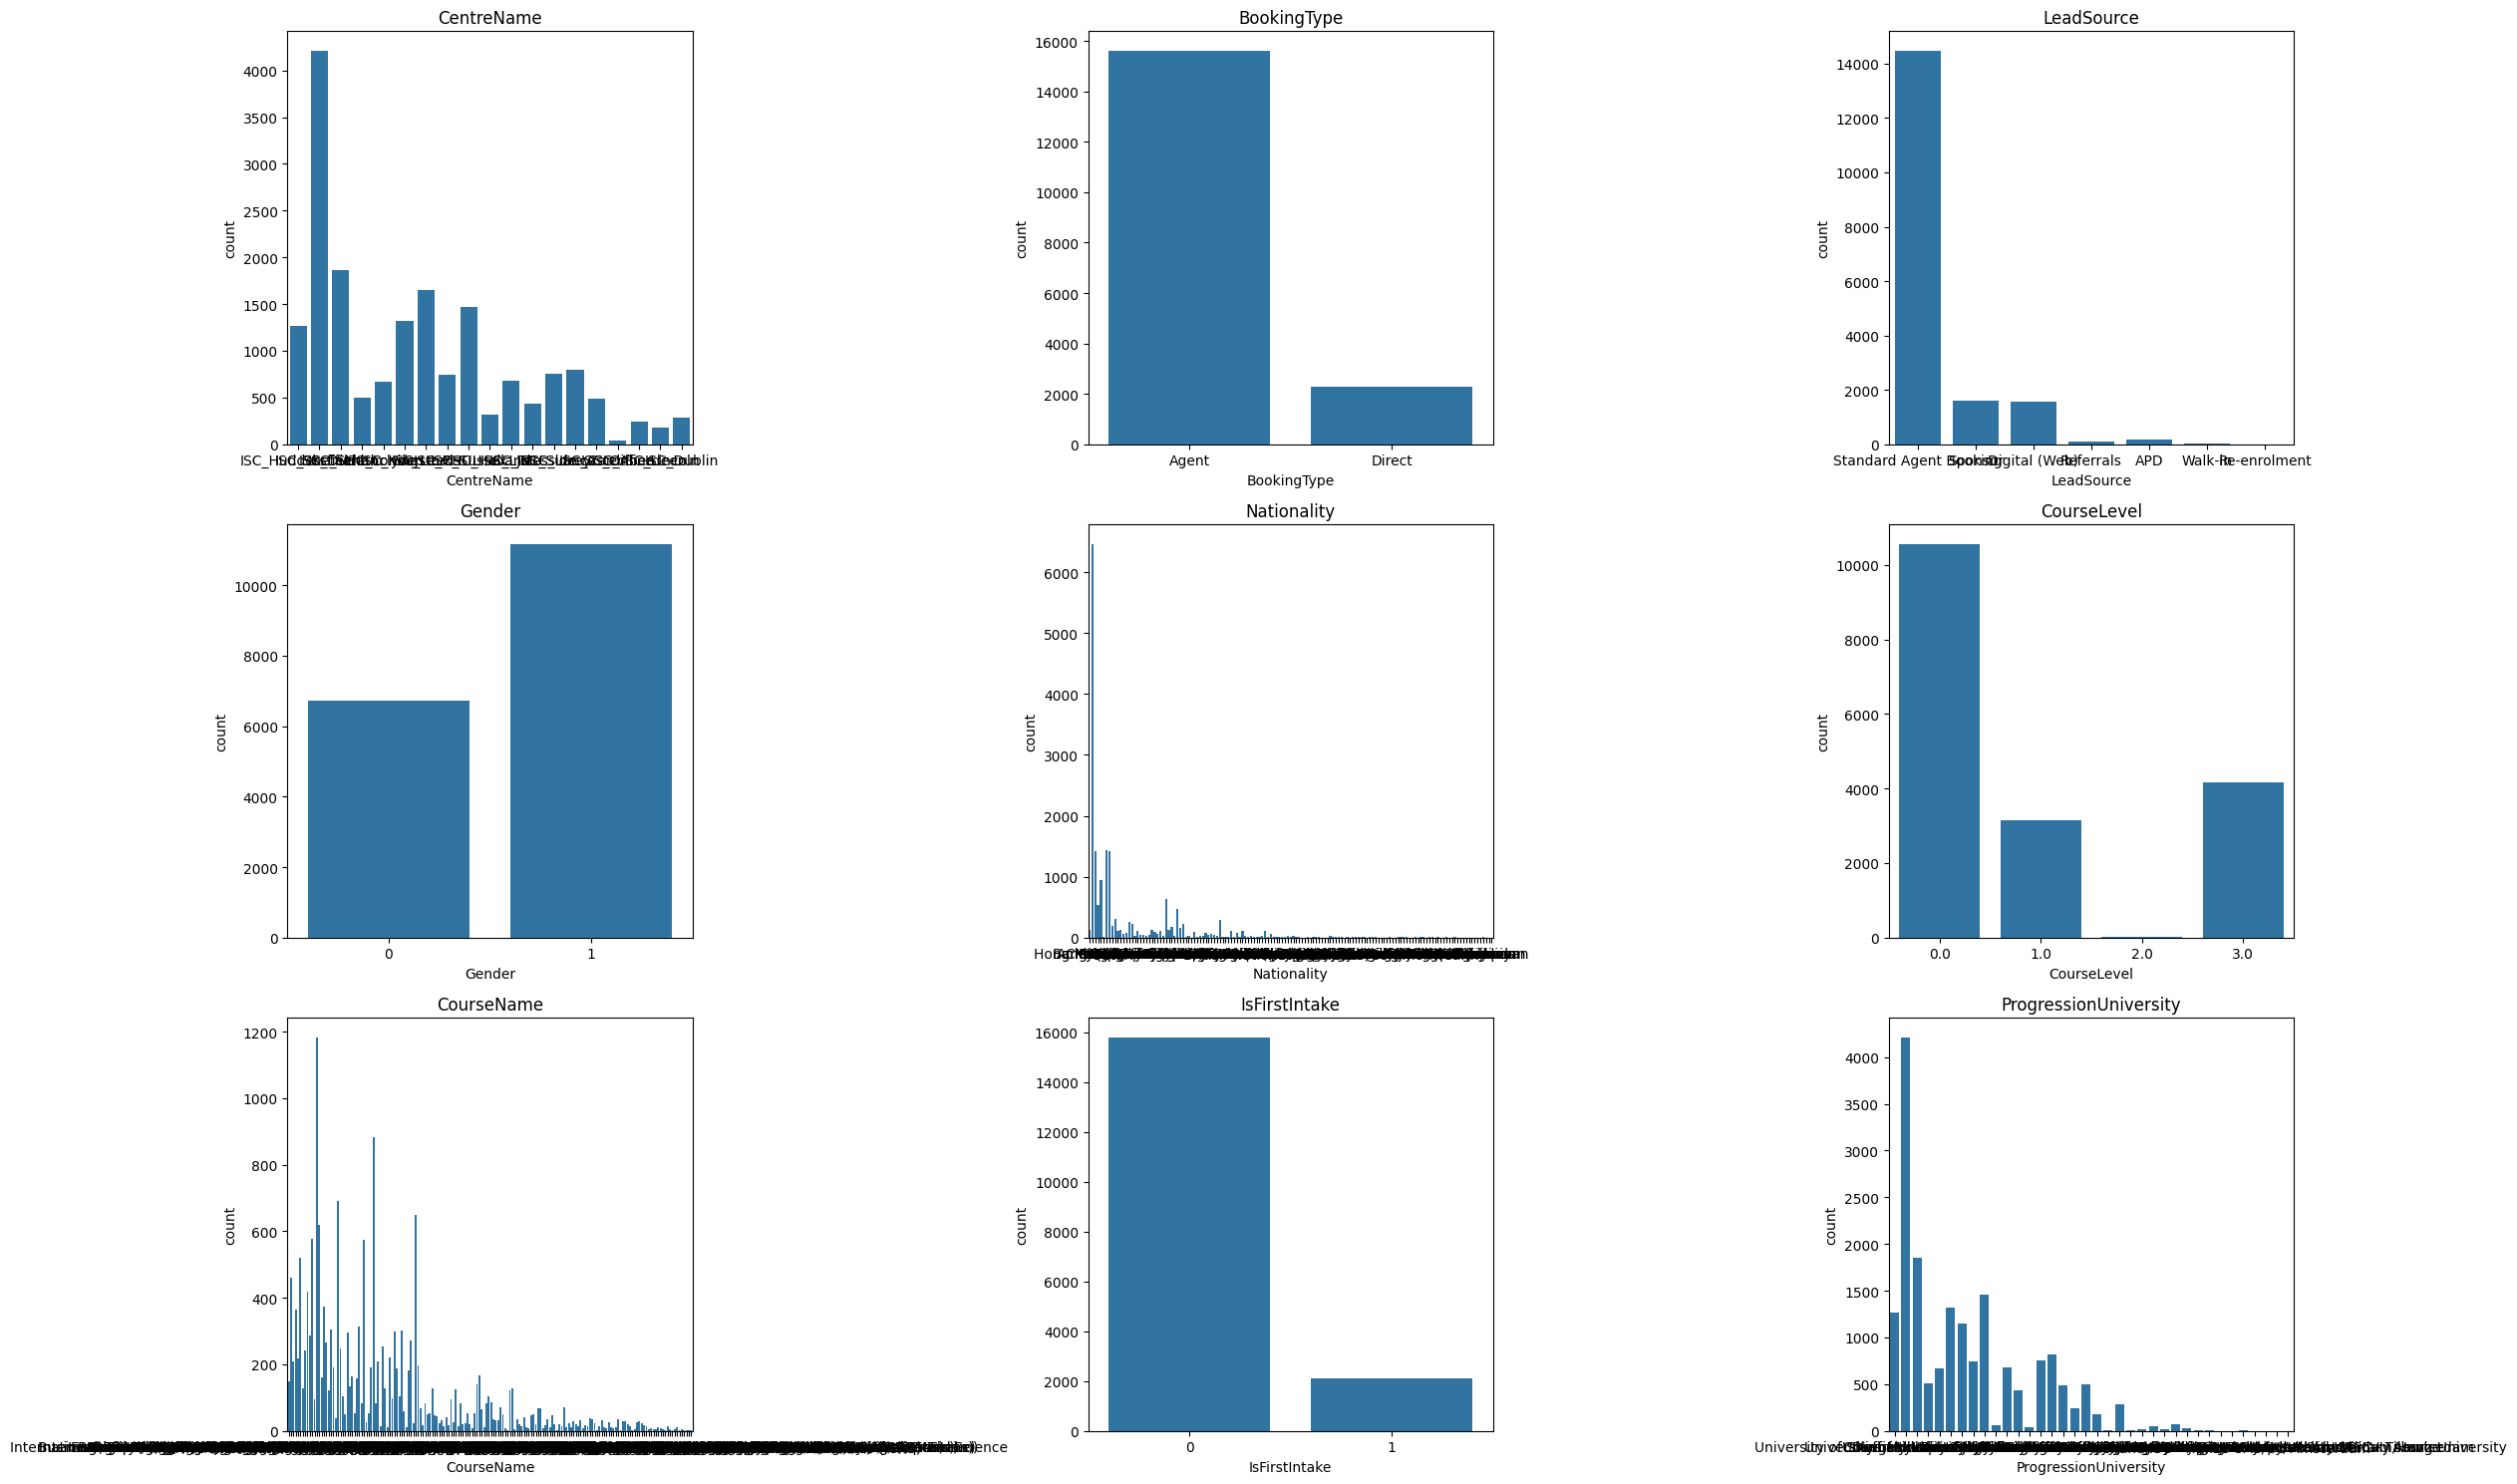

In [ ]:
# Quick EDA - bar charts to see distribution of categorical values

cat_columns = X_train.drop(columns=["Age", "AuthorisedAbsenceCount"]).columns

plt.figure(figsize=(25, 15))

for i, cat_column in enumerate(cat_columns):
  plt.subplot(3, 3, i+1)
  sns.countplot(
      data = X_train,
      x = X_train[cat_column],
  )
  plt.title(cat_column)

plt.tight_layout()
plt.show()

**Data Preprocessing - Continued**

In [ ]:
# One-hot encoding for all other categorical data.

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
ohe_columns = X_train.select_dtypes(include=["object"]).columns

ohe.fit(X_train[ohe_columns])

X_train_ohe = pd.DataFrame(
    ohe.transform(X_train[ohe_columns]),
    columns = ohe.get_feature_names_out(ohe_columns),
    index = X_train.index
)
X_val_ohe = pd.DataFrame(
    ohe.transform(X_val[ohe_columns]),
    columns = ohe.get_feature_names_out(ohe_columns),
    index = X_val.index
)
X_test_ohe = pd.DataFrame(
    ohe.transform(X_test[ohe_columns]),
    columns = ohe.get_feature_names_out(ohe_columns),
    index = X_test.index
)

num_cols_train = X_train.drop(columns=ohe_columns)
num_cols_val = X_val.drop(columns=ohe_columns)
num_cols_test = X_test.drop(columns=ohe_columns)

X_train = pd.concat([num_cols_train, X_train_ohe], axis=1)
X_val = pd.concat([num_cols_val, X_val_ohe], axis=1)
X_test = pd.concat([num_cols_test, X_test_ohe], axis=1)

print(f"X train shape: {X_train.shape}")
print(f"X val shape: {X_val.shape}")
print(f"X test shape: {X_test.shape}")

X_train.head()

X train shape: (17892, 378)
X val shape: (1988, 378)
X test shape: (4971, 378)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Gender,CourseLevel,IsFirstIntake,AuthorisedAbsenceCount,Age,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
5723,0,0.0,0,21.0,22,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15820,1,0.0,0,0.0,25,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5735,1,1.0,0,0.0,30,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3470,1,3.0,0,9.0,27,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20608,1,0.0,0,81.0,37,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


CompletedCourse
1    85.48
0    14.52
Name: proportion, dtype: float64


<Axes: xlabel='CompletedCourse', ylabel='count'>

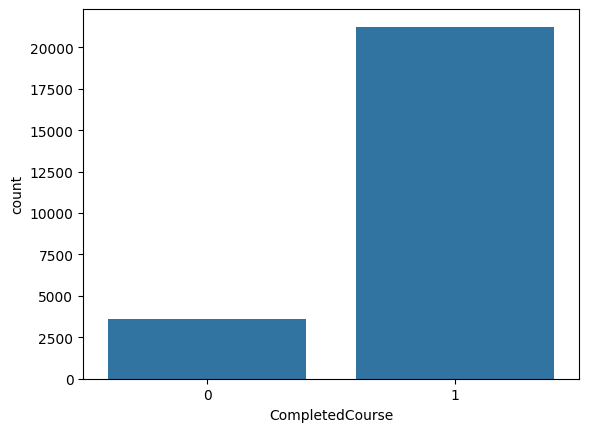

In [ ]:
# Check for imbalance in target variable data

print(y.value_counts(normalize=True).multiply(100).round(2))

sns.countplot(x=y)

The target variable is imbalanced, with 85% of students completing the course (1) and 15% not completing it (0).

**XGBoost**

XGBoost model with n_estimators: 100, learning_rate: 0.1, max_depth: 3
Accuracy: 0.8949909474954737
Precision: 0.9179188158779995
Recall: 0.9632854789362203
AUC: 0.8877184072641502
Confusion Matrix: [[ 356  366]
 [ 156 4093]]


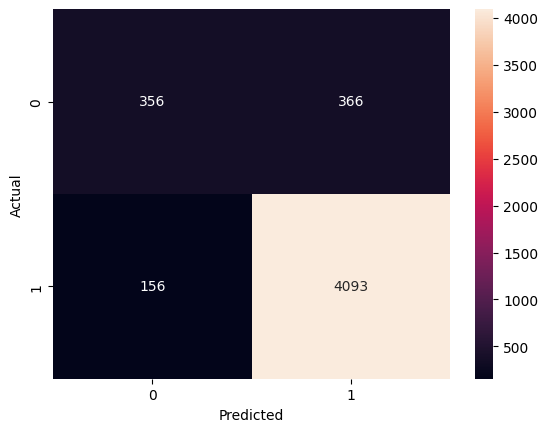

In [ ]:
# Testing the XGBoost Stage 2 baseline performance, with the same hyperparameters from Stage 1

xgb_model_s2_v1 = xgb_model(X_train, y_train, X_test, y_test, n_estimators = 100, learning_rate = 0.1, max_depth = 3)

XGBoost baseline model comparison between Stage 2 vs Stage 1 dataset (both evaluated on test set)

In [ ]:
y_prob = xgb_model_s2_v1.predict_proba(X_test)[:, 1]
y_pred = xgb_model_s2_v1.predict(X_test)

xgb_auc_s2_v1 = roc_auc_score(y_true, y_prob)
xgb_accuracy_s2_v1 = accuracy_score(y_true, y_pred)
xgb_precision_s2_v1 = precision_score(y_true, y_pred)
xgb_recall_s2_v1 = recall_score(y_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

xgb_comparison_s1_s2_df = pd.DataFrame([
    {"Stage": 1, "model": "xgb_model_v1", "n_estimators": 100, "learning_rate": 0.1, "max_depth": 3, "auc": 0.8739499645469969, "accuracy": 0.8894652833200319, "precision": 0.9127143175239367, "recall": 0.9619807556911523, "tn": 359, "fp": 392, "fn": 162, "tp": 4099},
    {"Stage": 2, "model": "xgb_model_s2_v1", "n_estimators": xgb_model_s2_v1.n_estimators, "learning_rate": xgb_model_s2_v1.learning_rate, "max_depth": xgb_model_s2_v1.max_depth, "auc": xgb_auc_s2_v1, "accuracy": xgb_accuracy_s2_v1, "precision": xgb_precision_s2_v1, "recall": xgb_recall_s2_v1, "tn": tn, "fp": fp, "fn": fn, "tp": tp}
])

xgb_comparison_s1_s2_df

,Stage,model,n_estimators,learning_rate,max_depth,auc,accuracy,precision,recall,tn,fp,fn,tp
0,1,xgb_model_v1,100,0.1,3,0.873950,0.889465,0.912714,0.961981,359,392,162,4099
1,2,xgb_model_s2_v1,100,0.1,3,0.887718,0.894991,0.917919,0.963285,356,366,156,4093


Comparing the results from Stage 1 and Stage 2 shows a clear improvement in model performance. In Stage 1, the baseline XGBoost model (xgb_model_v1) achieves an AUC of 0.874 using 100 estimators, a learning rate of 0.1, and a maximum depth of 3. In Stage 2, the model (xgb_model_s2_v1) achieves a higher AUC of 0.888 while using the same hyperparameters.

Since the preprocessing steps remain identical between the two stages, the improvement in performance can be attributed to the introduction of the additional feature AuthorisedAbsenceCount. This suggests that the new variable provides useful predictive information for the model, allowing it to better distinguish between classes and improve overall predictive performance.

**XGBoost - Hyperparameter tuning**

XGBoost model with n_estimators: 500, learning_rate: 0.05, max_depth: 3
Accuracy: 0.9079476861167002
Precision: 0.9282485875706215
Recall: 0.9670394349617422
AUC: 0.9198205335522015
Confusion Matrix: [[ 162  127]
 [  56 1643]]


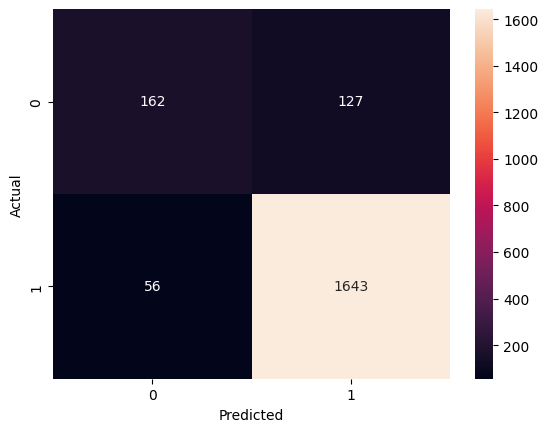

In [ ]:
xgb_model_s2_v2 = xgb_model(X_train, y_train, X_val, y_val, n_estimators = 500, learning_rate = 0.05, max_depth = 3)

XGBoost model with n_estimators: 500, learning_rate: 0.05, max_depth: 5
Accuracy: 0.9104627766599598
Precision: 0.9308781869688385
Recall: 0.9670394349617422
AUC: 0.9210313007244235
Confusion Matrix: [[ 167  122]
 [  56 1643]]


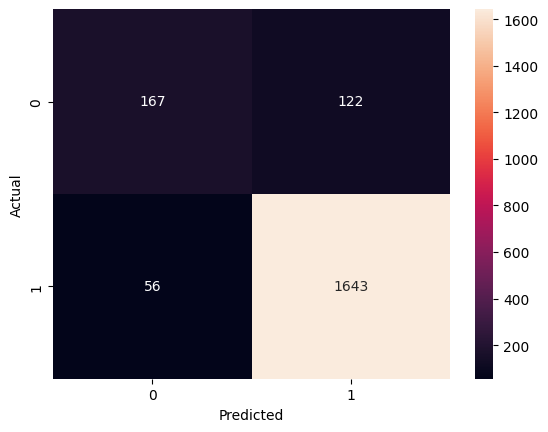

In [ ]:
xgb_model_s2_v3 = xgb_model(X_train, y_train, X_val, y_val, n_estimators = 500, learning_rate = 0.05, max_depth = 5)

XGBoost model with n_estimators: 1000, learning_rate: 0.01, max_depth: 5
Accuracy: 0.9119718309859155
Precision: 0.9295377677564826
Recall: 0.9705709240729841
AUC: 0.9219477771373757
Confusion Matrix: [[ 164  125]
 [  50 1649]]


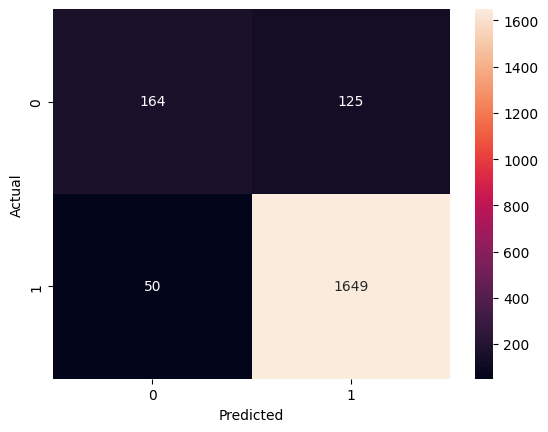

In [ ]:
xgb_model_s2_v4 = xgb_model(X_train, y_train, X_val, y_val, n_estimators = 1000, learning_rate = 0.01, max_depth = 5)

XGBoost model with n_estimators: 10000, learning_rate: 0.01, max_depth: 5
Accuracy: 0.9079476861167002
Precision: 0.9311717861205916
Recall: 0.9635079458505003
AUC: 0.917804285443707
Confusion Matrix: [[ 168  121]
 [  62 1637]]


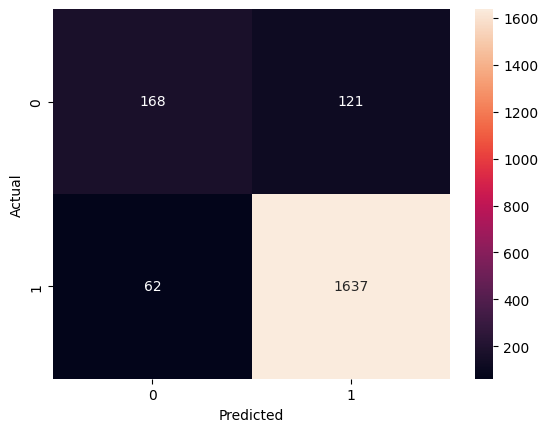

In [ ]:
xgb_model_s2_v5 = xgb_model(X_train, y_train, X_val, y_val, n_estimators = 10000, learning_rate = 0.01, max_depth = 5)

XGBoost model with n_estimators: 5000, learning_rate: 0.01, max_depth: 6
Accuracy: 0.9084507042253521
Precision: 0.9307211811470755
Recall: 0.964685108887581
AUC: 0.9196066890558461
Confusion Matrix: [[ 167  122]
 [  60 1639]]


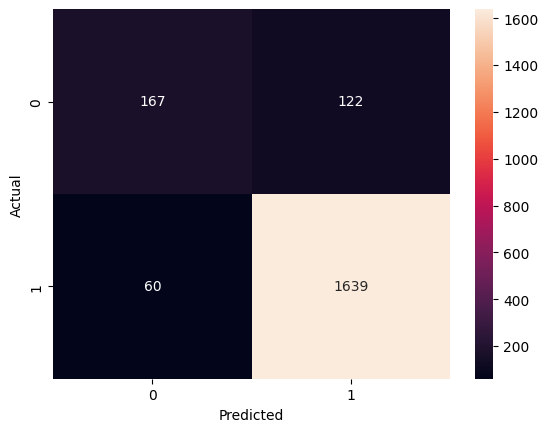

In [ ]:
xgb_model_s2_v6 = xgb_model(X_train, y_train, X_val, y_val, n_estimators = 5000, learning_rate = 0.01, max_depth = 6)

In [ ]:
# Let's compare all the tuned models, that were evaluated on the validation dataset

models = {
    "v2 on val": xgb_model_s2_v2,
    "v3 on val": xgb_model_s2_v3,
    "v4 on val": xgb_model_s2_v4,
    "v5 on val": xgb_model_s2_v5,
    "v6 on val": xgb_model_s2_v6,
}

results = []

for name, model in models.items():

    y_prob = model.predict_proba(X_val)[:, 1]
    y_pred = model.predict(X_val)
    y_true = y_val

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    results.append({
        "model": name,
        "n_estimators": model.n_estimators,
        "learning_rate": model.learning_rate,
        "max_depth": model.max_depth,
        "auc": roc_auc_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

pd.DataFrame(results)

,model,n_estimators,learning_rate,max_depth,auc,accuracy,precision,recall,tn,fp,fn,tp
0,v2 on val,500,0.05,3,0.919821,0.907948,0.928249,0.967039,162,127,56,1643
1,v3 on val,500,0.05,5,0.921031,0.910463,0.930878,0.967039,167,122,56,1643
2,v4 on val,1000,0.01,5,0.921948,0.911972,0.929538,0.970571,164,125,50,1649
3,v5 on val,10000,0.01,5,0.917804,0.907948,0.931172,0.963508,168,121,62,1637
4,v6 on val,5000,0.01,6,0.919607,0.908451,0.930721,0.964685,167,122,60,1639


The results show modest improvements in performance as model complexity increases, although the gains remain relatively small. Model v2 achieves an AUC of 0.920 using 500 estimators, a learning rate of 0.05, and a maximum depth of 3. Increasing the maximum depth to 5 in v3 slightly improves performance, raising the AUC to 0.921, which suggests that allowing deeper trees helps the model capture more complex feature interactions.

The best performing model is **v4**, which achieves the highest AUC of 0.922 using 1000 estimators, a learning rate of 0.01, and a maximum depth of 5. This configuration benefits from a larger number of trees combined with a smaller learning rate, allowing the boosting process to learn patterns more gradually and refine predictions over more iterations. Models v5 and v6 perform slightly worse despite using many more estimators or deeper trees, indicating that increasing model complexity beyond this point does not improve performance and may lead to diminishing returns. Overall, v4 provides the best performance based on the AUC metric.

XGBoost model with n_estimators: 1000, learning_rate: 0.01, max_depth: 5
Accuracy: 0.8970026151679743
Precision: 0.9216881065222298
Recall: 0.961167333490233
AUC: 0.8939048066711478
Confusion Matrix: [[ 375  347]
 [ 165 4084]]


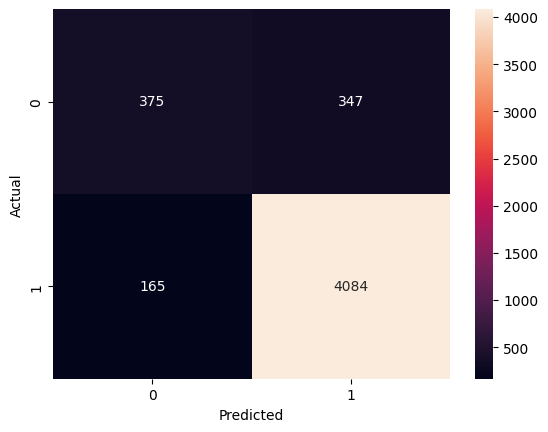

In [ ]:
# Evaluting the best model (v4) on test data

xgb_model_s2_v4 = xgb_model(X_train, y_train, X_test, y_test, n_estimators = 1000, learning_rate = 0.01, max_depth = 5)

In [ ]:
# Now we'll compare v1 (baseline model) with v4 (evaluated on the test set this time)
# Before vs after hyperparameter tuning

models = {
    "v1 on test (Baseline)": xgb_model_s2_v1,
    "v4 on test": xgb_model_s2_v4,
}

results = []

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    y_true = y_test

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    results.append({
        "model": name,
        "n_estimators": model.n_estimators,
        "learning_rate": model.learning_rate,
        "max_depth": model.max_depth,
        "auc": roc_auc_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

pd.DataFrame(results)

,model,n_estimators,learning_rate,max_depth,auc,accuracy,precision,recall,tn,fp,fn,tp
0,v1 on test (Baseline),100,0.10,3,0.887718,0.894991,0.917919,0.963285,356,366,156,4093
1,v4 on test,1000,0.01,5,0.893905,0.897003,0.921688,0.961167,375,347,165,4084


The baseline XGBoost model (v1) achieves a test AUC of 0.888, while the tuned model (v4) achieves a higher validation AUC of 0.922 during hyperparameter tuning. However, when v4 is evaluated on the unseen test data, it achieves a test AUC of 0.894, representing only a small improvement over the baseline model.

This marginal improvement suggests that while hyperparameter tuning improved performance on the validation set, the gain does not fully generalise to new data. The higher validation score may partly reflect mild overfitting during model selection or natural variation between the validation and test samples. However, despite the relatively small increase, the improvement in test AUC still indicates that the hyperparameter tuning process provided some benefit, leading to a model that performs slightly better than the baseline configuration.

**XGBoost - Feature Importance**

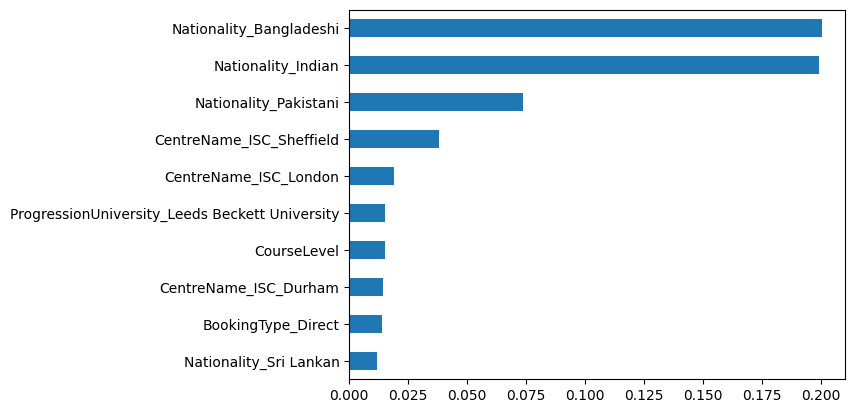

In [ ]:
# Looking into the best Stage 2 model - v4

feature_importance_s2 = pd.Series(xgb_model_s2_v4.feature_importances_, index=X_train.columns).sort_values()

# To only show the top 10 most important features
feature_importance_s2.tail(10).plot.barh()
plt.show()

Nationality features dominate the top of the rankings, Nationality_Bangladeshi and Nationality_Indian are jointly the most important features at ~0.200, followed by Nationality_Pakistani at ~0.070. This suggests student nationality is the strongest predictor of course completion in Stage 2.

CentreName_ISC_Sheffield ranks fourth at ~0.040, with CentreName_ISC_London fifth at ~0.020, indicating the study centre also carries meaningful predictive signal. The remaining features, ProgressionUniversity_Leeds Beckett University, CourseLevel, CentreName_ISC_Durham, BookingType_Direct, and Nationality_Sri Lankan, all sit below 0.020 with similar and modest importance scores, contributing limited individual signal.

Comparing Stage 2 Feature Importance vs Stage 1 Feature Importance

---

Nationality dominates in both stages, Bangladeshi and Indian are the top two features by a wide margin in both, with Pakistani third in both but with a noticeably larger bar in Stage 2. CentreName_ISC_Sheffield also comes at fourth in both with a noticeable larger bar in Stage 2

Key differences in Stage 2:
- ProgressionUniversity_Leeds Beckett University enters the top 10 in Stage 2 but isn't present in Stage 1, the model is picking up destination university as a meaningful signal
- CentreName_ISC_London ranks higher in Stage 2
- CentreName_ISC_Teesside appears in Stage 1 but drops out of the top 10 in Stage 2
- BookingType_Direct is present in both but sits lower in Stage 2

Overall the two stages are broadly consistent, nationality is the dominant driver in both, with centre location also featuring heavily.

Similar to Stage 1, we will use a SHAP violin plot in Stage 2 to better understand the impact and direction of the most important features. Unlike standard feature importance from XGBoost, SHAP shows how each feature influences the model's predictions, helping identify the features that genuinely drive the results.

**XGBoost - SHAP**

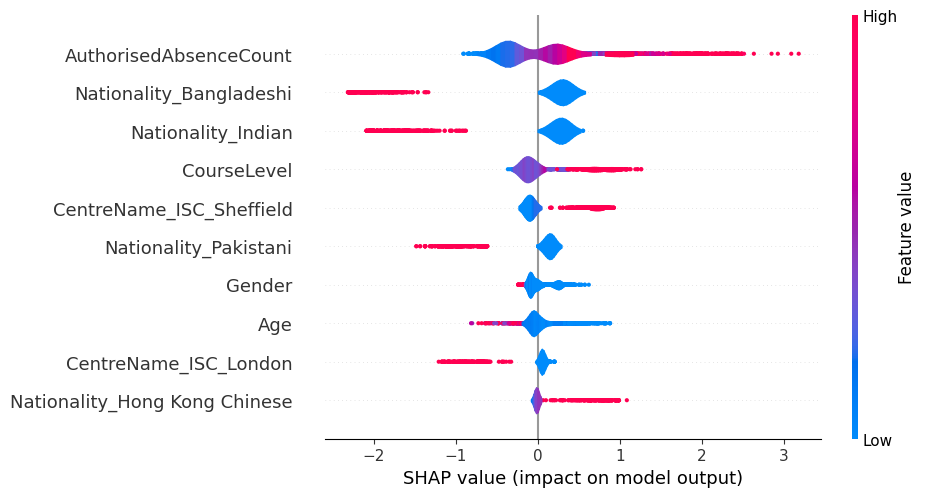

In [ ]:
import shap
shap.initjs()

shap_ex_s2 = shap.TreeExplainer(xgb_model_s2_v4)
vals_s2 = shap_ex_s2(X_test)

# Plotting the violing chart to see importance and direction of each feature
shap.plots.violin(vals_s2, max_display=10)

Comparing Stage 2 SHAP vs Stage 2 Feature Importance

---

The two tell quite different stories. Feature importance ranks Bangladeshi and Indian nationality at the top, but SHAP reveals they mostly push predictions negatively, so while they're important to the model, they signal lower completion likelihood.

AuthorisedAbsenceCount doesn't appear in the feature importance top 10 at all, yet SHAP identifies it as the single most impactful feature, this is a key discrepancy and highlights why SHAP gives a more complete picture than feature importance alone.

CourseLevel appears in both but ranks more prominently in SHAP, while ProgressionUniversity_Leeds Beckett University and BookingType_Direct show up in feature importance but don't make the SHAP top 10, suggesting they contribute less directional impact than their importance score implies.

Comparing Stage 2 SHAP vs Stage 1 SHAP

---

The most significant difference is the introduction of AuthorisedAbsenceCount in Stage 2, this feature wasn't yet introduced from the Stage 1 dataset entirely, yet immediately became the Stage 2 top ranked feature by SHAP value, with high values pushing predictions strongly positive. This single addition fundamentally shifts the model's behaviour between stages.

Nationality features (Bangladeshi, Indian, Pakistani) remain consistently important across both stages, though they drop down the rankings in Stage 2 due to AuthorisedAbsenceCount taking the top spot. Their directional pattern is consistent, low values push predictions negative in both stages.

CourseLevel and CentreName_ISC_Sheffield are present in both stages with similar directionality.

Features like ProgressionUniversity_Leeds Beckett University and LeadSource_Standard Agent Booking are visible in Stage 1 but drop out of the top 10 in Stage 2, likely displaced by the stronger signal from AuthorisedAbsenceCount. Conversely, CentreName_ISC_London appears in Stage 2 but not Stage 1.

**Neural Network**

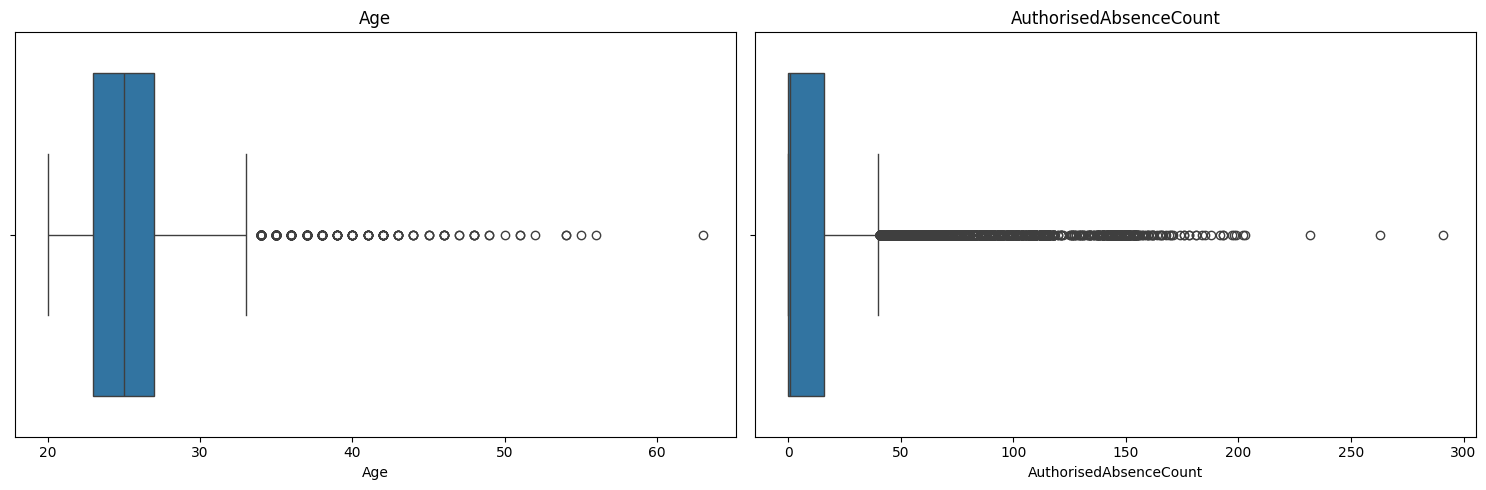

In [ ]:
# Check for outliers on continuous features before scaling

num_columns = X_train[["Age", "AuthorisedAbsenceCount"]]

plt.figure(figsize=(15, 5))

for i, num_column in enumerate(num_columns):
  plt.subplot(1, 2, i+1)
  sns.boxplot(
      data = X_train,
      x = X_train[num_column]
  )
  plt.title(num_column)

plt.tight_layout()
plt.show()


In [ ]:
# Scale our continuous features
# Since the are many outliers with our continuous features, we will use RobustScaler instead

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train[["Age", "AuthorisedAbsenceCount"]] = scaler.fit_transform(X_train[["Age", "AuthorisedAbsenceCount"]])
X_val[["Age", "AuthorisedAbsenceCount"]] = scaler.transform(X_val[["Age", "AuthorisedAbsenceCount"]])
X_test[["Age", "AuthorisedAbsenceCount"]] = scaler.transform(X_test[["Age", "AuthorisedAbsenceCount"]])

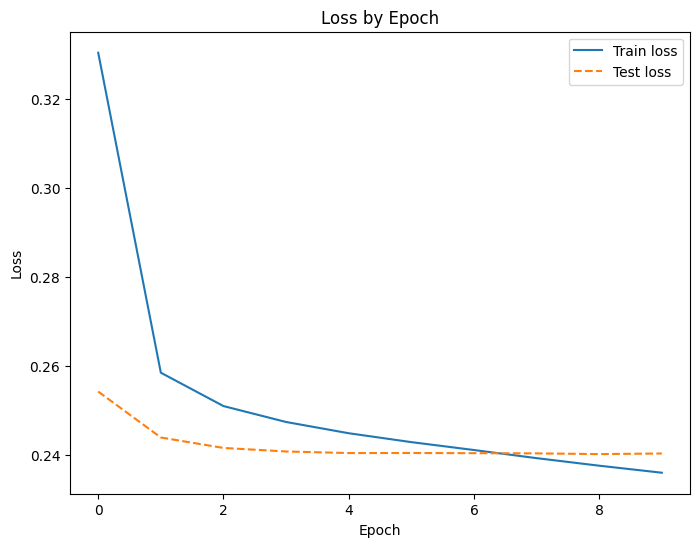

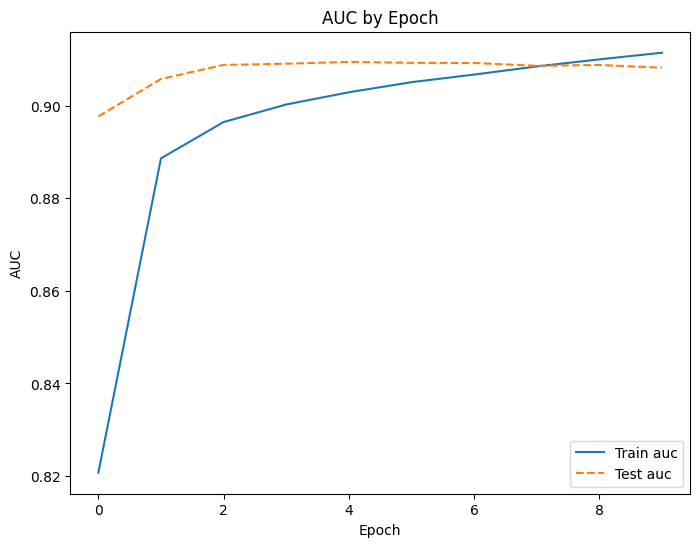

Accuracy: 0.8970026151679743
Precision: 0.9224508252317432
Recall: 0.9602259355142386
AUC: 0.8788528700577422
Confusion Matrix:
[[ 379  343]
 [ 169 4080]]


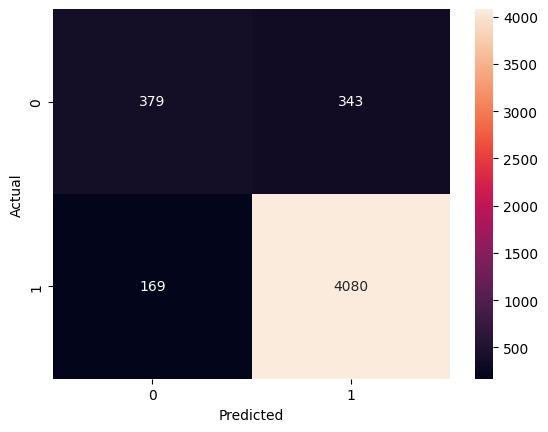

In [ ]:
# Testing the Neural Network Stage 2 baseline performance, with the same hyperparameters from Stage 1

nn_model_s2_v1, history_s2_v1 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 10,
    batch_size = 32,
    optimizer = "adam",
    hidden_layers = 1,
    units = 10,
    eval_name = "Test"
)

y_test_prob_s2_v1 = nn_model_s2_v1.predict(X_test, verbose = 0).flatten()
auc_s2_v1, loss_s2_v1, accuracy_s2_v1, precision_s2_v1, recall_s2_v1, tn_s2_v1, fp_s2_v1, fn_s2_v1, tp_s2_v1 = evaluate_nn_model(y_test, y_test_prob_s2_v1)

Neural Network baseline model comparison between Stage 2 vs Stage 1 dataset (both evaluated on test set)

In [ ]:
nn_comparison_s2_s1_df = pd.DataFrame([
    {"Stage": 1, "model": "nn_model_v1", "epochs": 10, "batch_size": 32, "optimizer": "adam", "hidden_layers": 1, "units": 10, "auc": 0.873857, "loss": 0.278002, "accuracy": 0.891460, "precision": 0.913276, "recall": 0.963858, "tn": 361, "fp": 390, "fn": 154, "tp": 4107},
    {"Stage": 2, "model": "nn_model_s2_v1", "epochs": 10, "batch_size": 32, "optimizer": "adam", "hidden_layers": 1, "units": 10, "auc": auc_s2_v1, "loss": loss_s2_v1, "accuracy": accuracy_s2_v1, "precision": precision_s2_v1, "recall": recall_s2_v1, "tn": tn_s2_v1, "fp": fp_s2_v1, "fn": fn_s2_v1, "tp": tp_s2_v1},
])

nn_comparison_s2_s1_df

,Stage,model,epochs,batch_size,optimizer,hidden_layers,units,auc,loss,accuracy,precision,recall,tn,fp,fn,tp
0,1,nn_model_v1,10,32,adam,1,10,0.873857,0.278002,0.891460,0.913276,0.963858,361,390,154,4107
1,2,nn_model_s2_v1,10,32,adam,1,10,0.878853,0.268323,0.897003,0.922451,0.960226,379,343,169,4080


Stage 2 introduced the additional feature AuthorisedAbsenceCount to the model while keeping the neural network architecture and training parameters the same (10 epochs, batch size of 32, adam optimiser, one hidden layer with 10 units). Compared to the baseline model in Stage 1, this change resulted in an improvement in performance. The AUC increased from 0.874 to 0.879. This suggests that AuthorisedAbsenceCount provides useful predictive information and helps the model better distinguish between classes, leading to improved model performance without increasing model complexity.

**Neural Network - Hyperparameter tuning**

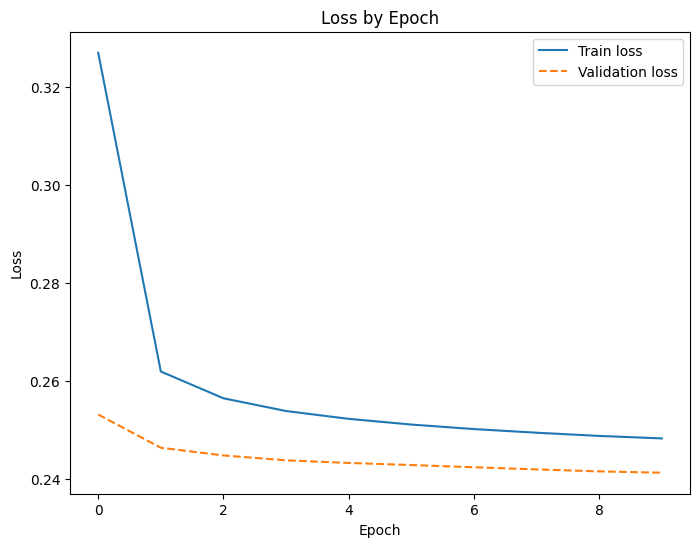

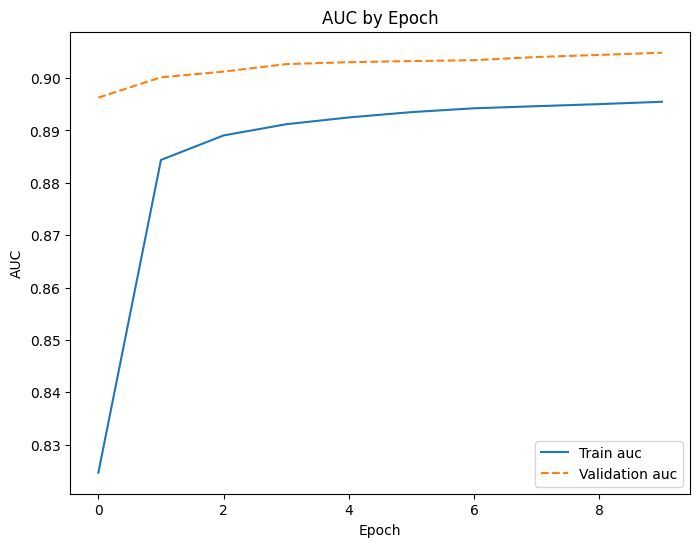

Accuracy: 0.9049295774647887
Precision: 0.927519818799547
Recall: 0.9640965273690406
AUC: 0.9047129290382497
Confusion Matrix:
[[ 161  128]
 [  61 1638]]


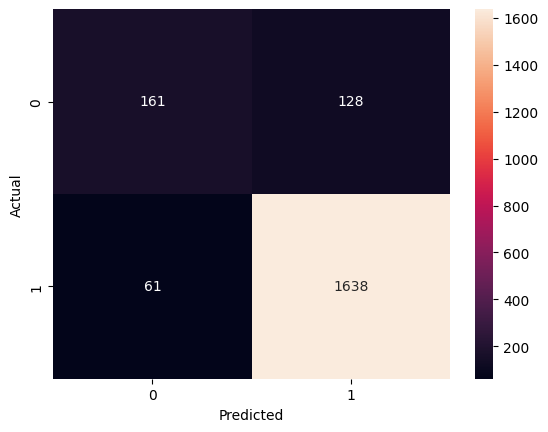

In [ ]:
nn_model_s2_v2, history_s2_v2 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 10,
    batch_size = 32,
    optimizer = "rmsprop",
    hidden_layers = 1,
    units = 10
)

y_val_prob_s2_v2 = nn_model_s2_v2.predict(X_val, verbose = 0).flatten()
auc_s2_v2, loss_s2_v2, accuracy_s2_v2, precision_s2_v2, recall_s2_v2, tn_s2_v2, fp_s2_v2, fn_s2_v2, tp_s2_v2 = evaluate_nn_model(y_val, y_val_prob_s2_v2)

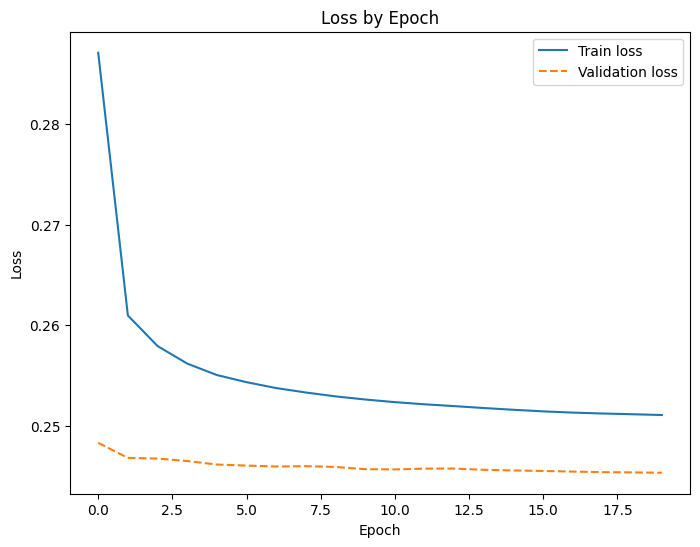

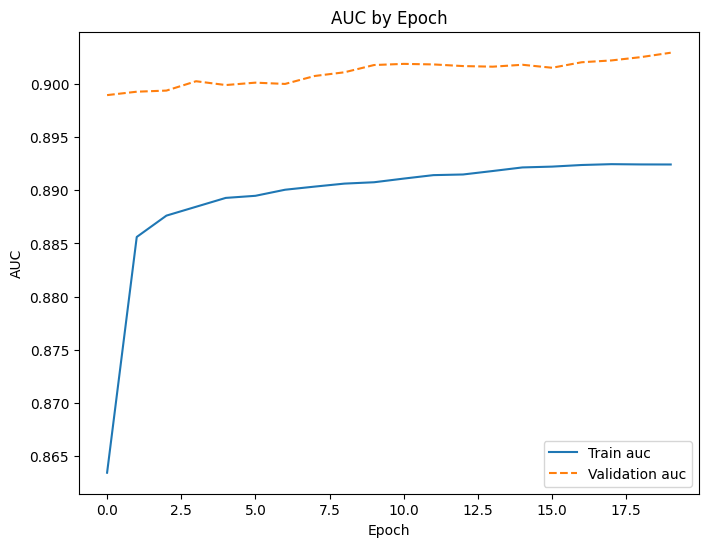

Accuracy: 0.9054325955734407
Precision: 0.9241998877035373
Recall: 0.9688051795173631
AUC: 0.9024665435193916
Confusion Matrix:
[[ 154  135]
 [  53 1646]]


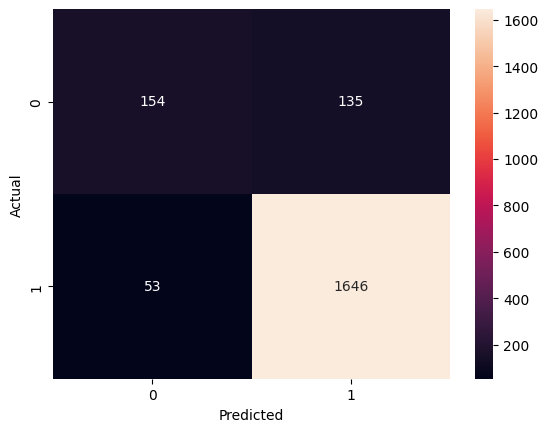

In [ ]:
nn_model_s2_v3, history_s2_v3 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 20,
    batch_size = 16,
    optimizer = "rmsprop",
    hidden_layers = 1,
    units = 10
)

y_val_prob_s2_v3 = nn_model_s2_v3.predict(X_val, verbose = 0).flatten()
auc_s2_v3, loss_s2_v3, accuracy_s2_v3, precision_s2_v3, recall_s2_v3, tn_s2_v3, fp_s2_v3, fn_s2_v3, tp_s2_v3 = evaluate_nn_model(y_val, y_val_prob_s2_v3)

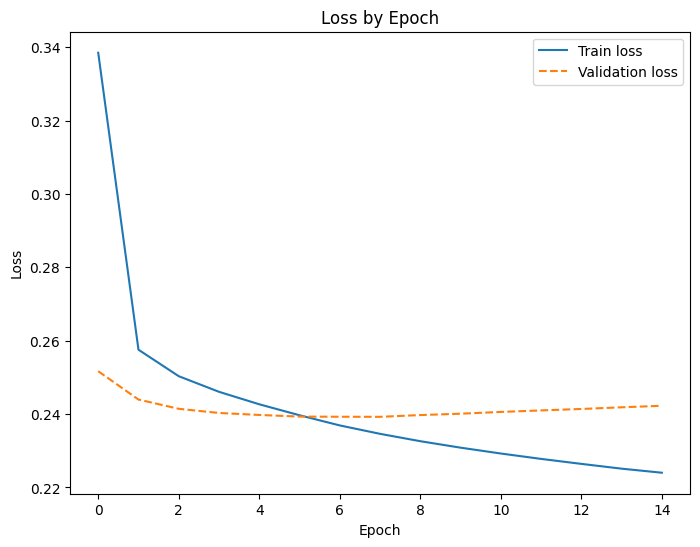

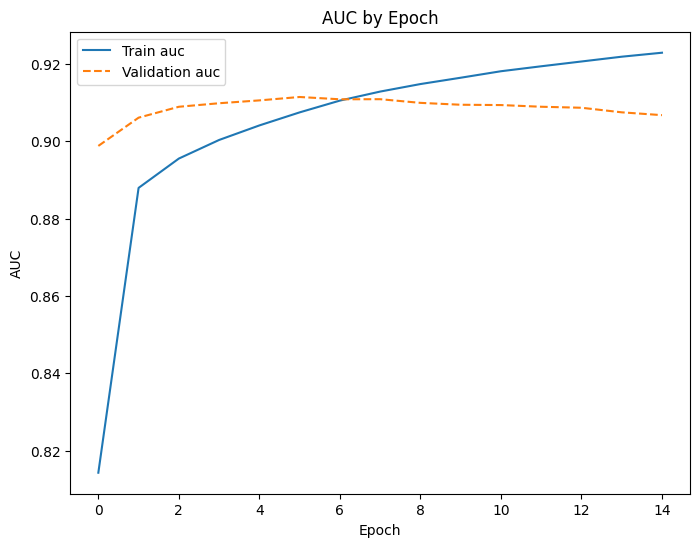

Accuracy: 0.9019114688128773
Precision: 0.9306987399770905
Recall: 0.9564449676280165
AUC: 0.9074949441051219
Confusion Matrix:
[[ 168  121]
 [  74 1625]]


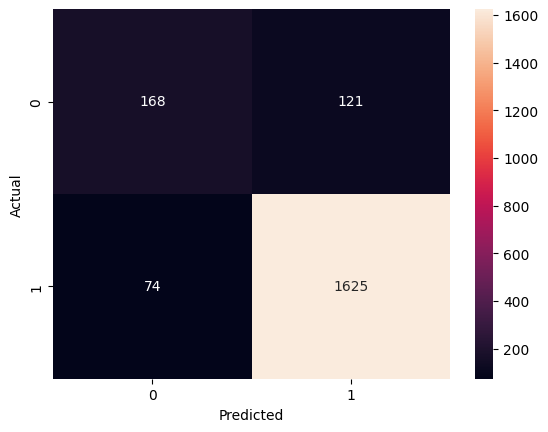

In [ ]:
nn_model_s2_v4, history_s2_v4 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 15,
    batch_size = 16,
    optimizer = "adam",
    hidden_layers = 1,
    units = 10
)

y_val_prob_s2_v4 = nn_model_s2_v4.predict(X_val, verbose = 0).flatten()
auc_s2_v4, loss_s2_v4, accuracy_s2_v4, precision_s2_v4, recall_s2_v4, tn_s2_v4, fp_s2_v4, fn_s2_v4, tp_s2_v4 = evaluate_nn_model(y_val, y_val_prob_s2_v4)

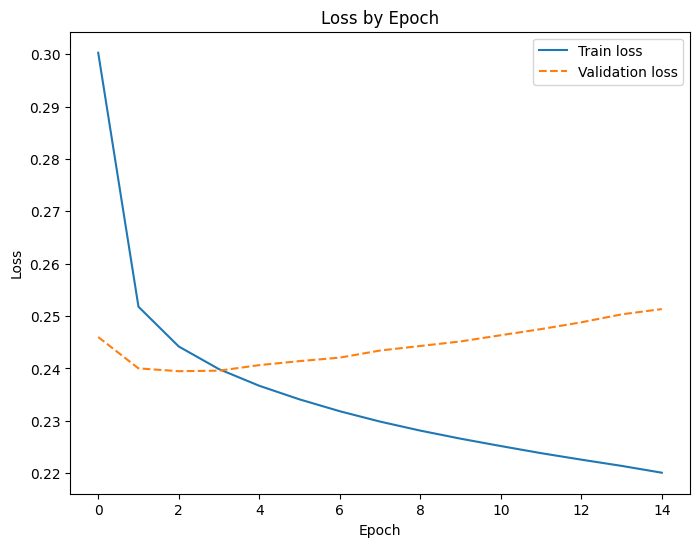

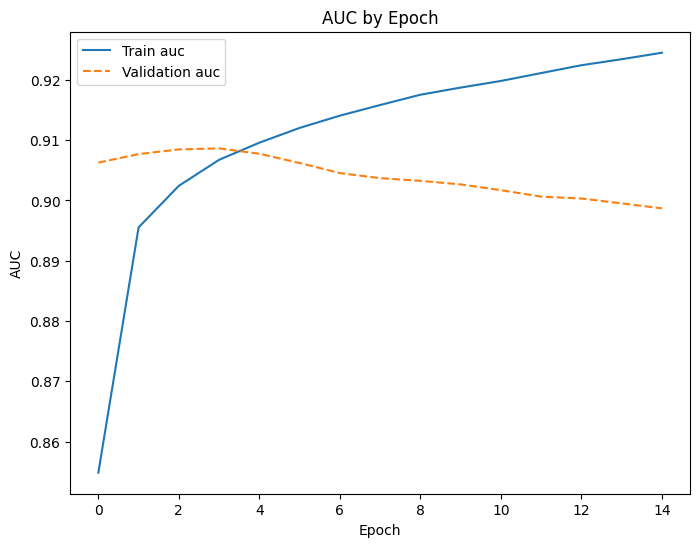

Accuracy: 0.8983903420523138
Precision: 0.9284487693188322
Recall: 0.9546792230723955
AUC: 0.8989330177938987
Confusion Matrix:
[[ 164  125]
 [  77 1622]]


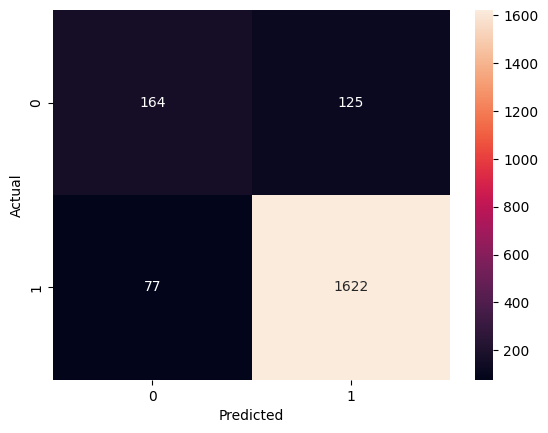

In [ ]:
nn_model_s2_v5, history_s2_v5 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 15,
    batch_size = 16,
    optimizer = "adam",
    hidden_layers = 2,
    units = 10
)

y_val_prob_s2_v5 = nn_model_s2_v5.predict(X_val, verbose = 0).flatten()
auc_s2_v5, loss_s2_v5, accuracy_s2_v5, precision_s2_v5, recall_s2_v5, tn_s2_v5, fp_s2_v5, fn_s2_v5, tp_s2_v5 = evaluate_nn_model(y_val, y_val_prob_s2_v5)

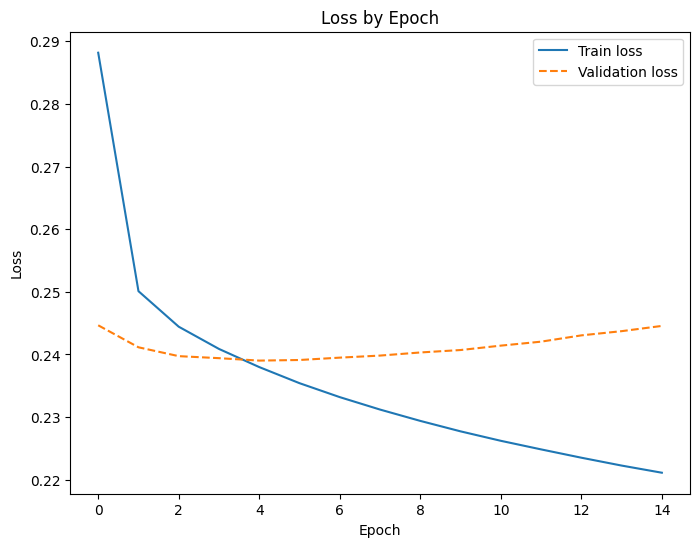

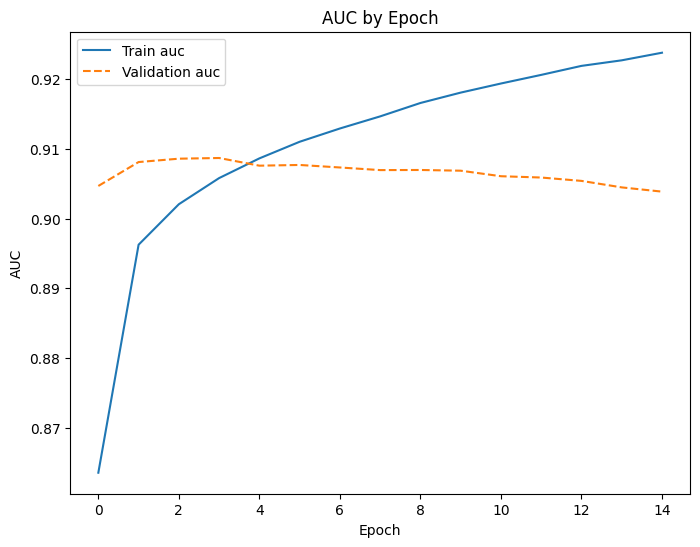

Accuracy: 0.903420523138833
Precision: 0.9278818852924475
Recall: 0.9617422012948793
AUC: 0.9041935924042434
Confusion Matrix:
[[ 162  127]
 [  65 1634]]


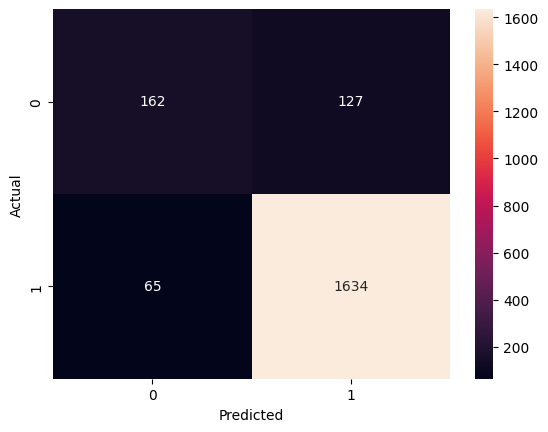

In [ ]:
nn_model_s2_v6, history_s2_v6 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 15,
    batch_size = 16,
    optimizer = "adam",
    hidden_layers = 1,
    units = 15
)

y_val_prob_s2_v6 = nn_model_s2_v6.predict(X_val, verbose = 0).flatten()
auc_s2_v6, loss_s2_v6, accuracy_s2_v6, precision_s2_v6, recall_s2_v6, tn_s2_v6, fp_s2_v6, fn_s2_v6, tp_s2_v6 = evaluate_nn_model(y_val, y_val_prob_s2_v6)

In [ ]:
# Now let's compare all the tuned models (v2-v6), which were evaluated on the validation dataset

nn_comparison_s2_df = pd.DataFrame([
    {"model": "nn_model_s2_v2", "epochs": 10, "batch_size": 32, "optimizer": "rmsprop", "hidden_layers": 1, "units": 10, "auc": auc_s2_v2, "loss": loss_s2_v2, "accuracy": accuracy_s2_v2, "precision": precision_s2_v2, "recall": recall_s2_v2, "tn": tn_s2_v2, "fp": fp_s2_v2, "fn": fn_s2_v2, "tp": tp_s2_v2},
    {"model": "nn_model_s2_v3", "epochs": 20, "batch_size": 16, "optimizer": "rmsprop", "hidden_layers": 1, "units": 10, "auc": auc_s2_v3, "loss": loss_s2_v3, "accuracy": accuracy_s2_v3, "precision": precision_s2_v3, "recall": recall_s2_v3, "tn": tn_s2_v3, "fp": fp_s2_v3, "fn": fn_s2_v3, "tp": tp_s2_v3},
    {"model": "nn_model_s2_v4", "epochs": 15, "batch_size": 16, "optimizer": "adam", "hidden_layers": 1, "units": 10, "auc": auc_s2_v4, "loss": loss_s2_v4, "accuracy": accuracy_s2_v4, "precision": precision_s2_v4, "recall": recall_s2_v4, "tn": tn_s2_v4, "fp": fp_s2_v4, "fn": fn_s2_v4, "tp": tp_s2_v4},
    {"model": "nn_model_s2_v5", "epochs": 15, "batch_size": 16, "optimizer": "adam", "hidden_layers": 2, "units": 10, "auc": auc_s2_v5, "loss": loss_s2_v5, "accuracy": accuracy_s2_v5, "precision": precision_s2_v5, "recall": recall_s2_v5, "tn": tn_s2_v5, "fp": fp_s2_v5, "fn": fn_s2_v5, "tp": tp_s2_v5},
    {"model": "nn_model_s2_v6", "epochs": 15, "batch_size": 16, "optimizer": "adam", "hidden_layers": 1, "units": 15, "auc": auc_s2_v6, "loss": loss_s2_v6, "accuracy": accuracy_s2_v6, "precision": precision_s2_v6, "recall": recall_s2_v6, "tn": tn_s2_v6, "fp": fp_s2_v6, "fn": fn_s2_v6, "tp": tp_s2_v6},
])

nn_comparison_s2_df

,model,epochs,batch_size,optimizer,hidden_layers,units,auc,loss,accuracy,precision,recall,tn,fp,fn,tp
0,nn_model_s2_v2,10,32,rmsprop,1,10,0.904713,0.241309,0.904930,0.927520,0.964097,161,128,61,1638
1,nn_model_s2_v3,20,16,rmsprop,1,10,0.902467,0.245331,0.905433,0.924200,0.968805,154,135,53,1646
2,nn_model_s2_v4,15,16,adam,1,10,0.907495,0.242261,0.901911,0.930699,0.956445,168,121,74,1625
3,nn_model_s2_v5,15,16,adam,2,10,0.898933,0.251340,0.898390,0.928449,0.954679,164,125,77,1622
4,nn_model_s2_v6,15,16,adam,1,15,0.904194,0.244556,0.903421,0.927882,0.961742,162,127,65,1634


Five configurations (v2–v6) were evaluated with AUC as the primary metric alongside accuracy, precision, and recall.

v2 (rmsprop, 10 epochs, batch size 32) provided a strong starting point at 0.905. Increasing epochs to 20 and reducing batch size in v3 slightly decreased AUC to 0.902. Switching to adam in v4 with 15 epochs and batch size 16 achieved the highest AUC of 0.907 with the lowest loss of 0.242, though recall dropped slightly. Adding a second hidden layer in v5 reduced performance across all metrics, suggesting additional depth is unnecessary. Increasing units from 10 to 15 in v6 recovered partially to 0.904 but fell short of v4.

**v4** is selected as the best model based on AUC (0.907), with 15 epochs, adam, batch size 16, 1 hidden layer and 10 units.

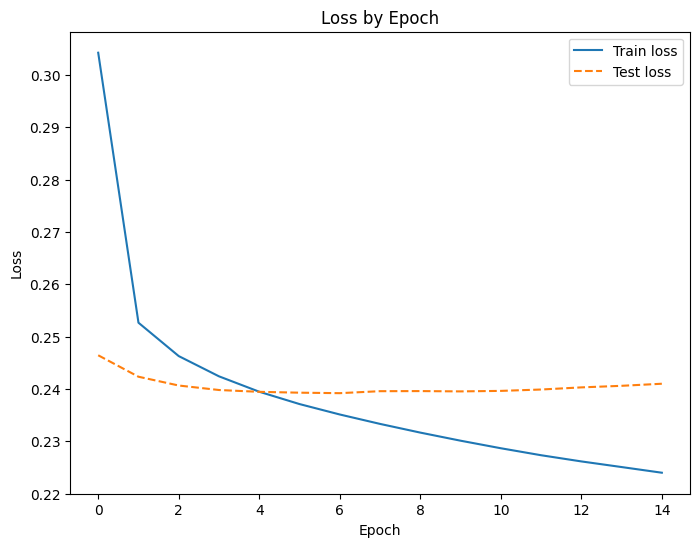

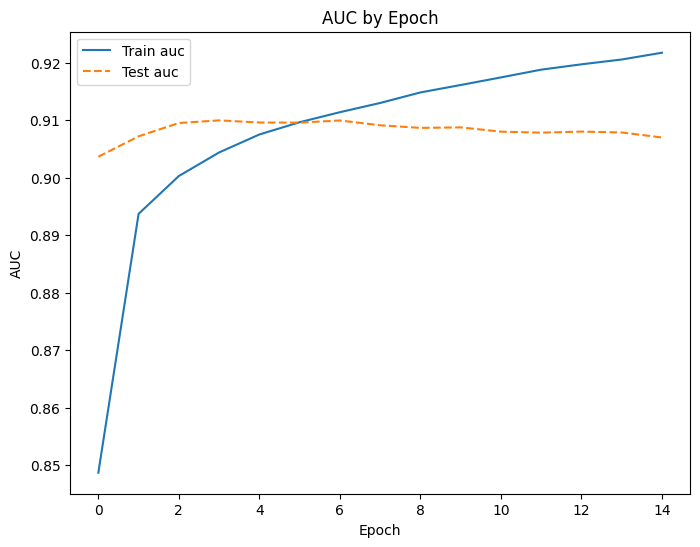

Accuracy: 0.8966002816334742
Precision: 0.9254955570745045
Recall: 0.9559896446222641
AUC: 0.8746561843784002
Confusion Matrix:
[[ 395  327]
 [ 187 4062]]


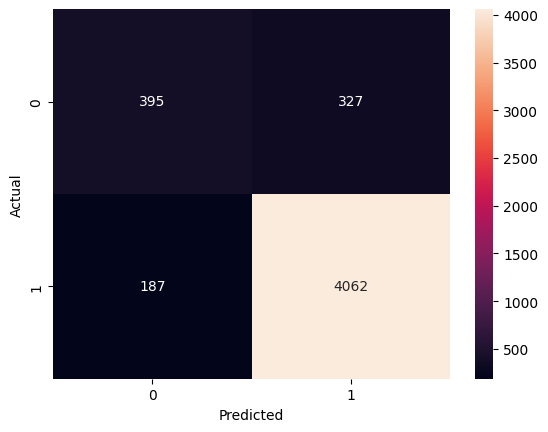

In [ ]:
# Now let's evaluate the best tuned model (v4) on test data this time

nn_model_s2_v4, history_s2_v4 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 15,
    batch_size = 16,
    optimizer = "adam",
    hidden_layers = 1,
    units = 10,
    eval_name = "Test"
)

y_test_prob_s2_v4 = nn_model_s2_v4.predict(X_test, verbose = 0).flatten()
auc_s2_v4, loss_s2_v4, accuracy_s2_v4, precision_s2_v4, recall_s2_v4, tn_s2_v4, fp_s2_v4, fn_s2_v4, tp_s2_v4 = evaluate_nn_model(y_test, y_test_prob_s2_v4)

In [ ]:
# Compare the v1 (baseline model) vs v4 (evaluated on test dataset this time)

nn_final_comparison_df = pd.DataFrame([
    {"model": "nn_model_s2_v1", "epochs": 10, "batch_size": 32, "optimizer": "adam", "hidden_layers": 1, "units": 10, "auc": auc_s2_v1, "loss": loss_s2_v1, "accuracy": accuracy_s2_v1, "precision": precision_s2_v1, "recall": recall_s2_v1, "tn": tn_s2_v1, "fp": fp_s2_v1, "fn": fn_s2_v1, "tp": tp_s2_v1},
    {"model": "nn_model_s2_v4", "epochs": 15, "batch_size": 16, "optimizer": "adam", "hidden_layers": 1, "units": 10, "auc": auc_s2_v4, "loss": loss_s2_v4, "accuracy": accuracy_s2_v4, "precision": precision_s2_v4, "recall": recall_s2_v4, "tn": tn_s2_v4, "fp": fp_s2_v4, "fn": fn_s2_v4, "tp": tp_s2_v4}
])

nn_final_comparison_df

,model,epochs,batch_size,optimizer,hidden_layers,units,auc,loss,accuracy,precision,recall,tn,fp,fn,tp
0,nn_model_s2_v1,10,32,adam,1,10,0.878853,0.268323,0.897003,0.922451,0.960226,379,343,169,4080
1,nn_model_s2_v4,15,16,adam,1,10,0.874656,0.277120,0.896600,0.925496,0.955990,395,327,187,4062


The baseline model (v1) achieved an AUC of 0.879 on the test set. After hyperparameter tuning, v4 improved to 0.907 on the validation set, however this dropped to 0.875 on the test set, falling slightly below the baseline by ~0.004.

Similar to the Stage 1 neural network findings, tuning improved validation performance but did not translate to gains on unseen data, suggesting mild overfitting to the validation set during tuning. The near-identical test AUC between v1 and v4 again points to a dataset-level performance ceiling as the primary constraint.

# Stage 3 data

In [ ]:
# File URL
file_url_3 = "https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-"

**Stage 3: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with rows that have missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.






In [ ]:
# Start coding from here with Stage 3 dataset

# Read the data for Stage 3
df_s3 = pd.read_csv(file_url_3)

print(df_s3.shape)
df_s3.head()

(25059, 21)


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,...,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,...,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,...,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,BSc Biological Sciences,University of Aberdeen,93.0,5.0
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,...,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,MA Finance,University of Aberdeen,92.0,6.0
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,...,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,MA Business Management,University of Aberdeen,67.0,15.0
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,...,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,MSc International Business Management,University of Aberdeen,NaN,NaN


In [ ]:
# Check the info

df_s3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CentreName                25059 non-null  object 
 1   LearnerCode               25059 non-null  int64  
 2   BookingType               25059 non-null  object 
 3   LeadSource                25059 non-null  object 
 4   DiscountType              7595 non-null   object 
 5   DateofBirth               25059 non-null  object 
 6   Gender                    25059 non-null  object 
 7   Nationality               25059 non-null  object 
 8   HomeState                 8925 non-null   object 
 9   HomeCity                  21611 non-null  object 
 10  CourseLevel               25059 non-null  object 
 11  CourseName                25059 non-null  object 
 12  IsFirstIntake             25059 non-null  bool   
 13  CompletedCourse           25059 non-null  object 
 14  Assess

In [ ]:
# Check for duplicates

df_s3.duplicated().sum()

np.int64(0)

In [ ]:
# Check for cardinality

for column in df_s3.columns:
  print(f"Number of unique values in {column}: {df_s3[column].nunique()}")

Number of unique values in CentreName: 19
Number of unique values in LearnerCode: 24877
Number of unique values in BookingType: 2
Number of unique values in LeadSource: 7
Number of unique values in DiscountType: 11
Number of unique values in DateofBirth: 4705
Number of unique values in Gender: 2
Number of unique values in Nationality: 151
Number of unique values in HomeState: 2448
Number of unique values in HomeCity: 5881
Number of unique values in CourseLevel: 4
Number of unique values in CourseName: 172
Number of unique values in IsFirstIntake: 2
Number of unique values in CompletedCourse: 2
Number of unique values in AssessedModules: 12
Number of unique values in PassedModules: 12
Number of unique values in FailedModules: 11
Number of unique values in ProgressionDegree: 2616
Number of unique values in ProgressionUniversity: 40
Number of unique values in AuthorisedAbsenceCount: 190
Number of unique values in UnauthorisedAbsenceCount: 258


**Feature engineering**

In [ ]:
# Convert DateofBirth into Age

# Set a cut-off date for consistency and reproducibility
today = "2026-03-07"

df_s3["DateofBirth"] = pd.to_datetime(df_s3["DateofBirth"])
df_s3["Age"] = (pd.to_datetime(today) - df_s3["DateofBirth"]).dt.days // 365

df_s3 = df_s3.drop(columns = ["DateofBirth"])

df_s3.head()

/tmp/ipykernel_1244/2069792959.py:6: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_s3["DateofBirth"] = pd.to_datetime(df_s3["DateofBirth"])


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,Gender,Nationality,HomeState,HomeCity,CourseLevel,...,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,...,True,Yes,4.0,4.0,0.0,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN,28
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,Male,Chinese,NaN,Xi'an,Foundation,...,False,Yes,7.0,7.0,0.0,BSc Biological Sciences,University of Aberdeen,93.0,5.0,28
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,Male,Chinese,NaN,Chengdu,International Year Two,...,False,Yes,8.0,8.0,0.0,MA Finance,University of Aberdeen,92.0,6.0,25
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,...,True,Yes,8.0,8.0,0.0,MA Business Management,University of Aberdeen,67.0,15.0,26
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,Male,Chinese,NaN,Xiamen,Pre-Masters,...,True,Yes,4.0,4.0,0.0,MSc International Business Management,University of Aberdeen,NaN,NaN,29


**Data Preprocessing**

In [ ]:
# Check for caridnality again before dropping columns

for column in df_s3.columns:
  print(f"Number of unique values in {column}: {df_s3[column].nunique()}")

Number of unique values in CentreName: 19
Number of unique values in LearnerCode: 24877
Number of unique values in BookingType: 2
Number of unique values in LeadSource: 7
Number of unique values in DiscountType: 11
Number of unique values in Gender: 2
Number of unique values in Nationality: 151
Number of unique values in HomeState: 2448
Number of unique values in HomeCity: 5881
Number of unique values in CourseLevel: 4
Number of unique values in CourseName: 172
Number of unique values in IsFirstIntake: 2
Number of unique values in CompletedCourse: 2
Number of unique values in AssessedModules: 12
Number of unique values in PassedModules: 12
Number of unique values in FailedModules: 11
Number of unique values in ProgressionDegree: 2616
Number of unique values in ProgressionUniversity: 40
Number of unique values in AuthorisedAbsenceCount: 190
Number of unique values in UnauthorisedAbsenceCount: 258
Number of unique values in Age: 38


In [ ]:
# Drop categorical columns with high cardinality (>200 unique values)

for column in df_s3.columns:
  if df_s3[column].nunique() > 200:
    df_s3 = df_s3.drop(columns = [column])


# Drop columns with >50% missing

for column in df_s3.columns:
  if df_s3[column].isnull().sum() > 0.5 * len(df_s3):
    df_s3 = df_s3.drop(columns = [column])


print(df_s3.shape)
df_s3.head()

(25059, 15)


,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,AuthorisedAbsenceCount,Age
0,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,NaN,28
1,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,University of Aberdeen,93.0,28
2,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,International Year Two,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,University of Aberdeen,92.0,25
3,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,International Year Two,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,University of Aberdeen,67.0,26
4,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,University of Aberdeen,NaN,29


Quick comment: Compared to Stage 2, I noticed there are 3 additional features: Assessed Modules, Passed Modules, and Failed Modules

In [ ]:
# Check for unique values before encoding, to determine ordinal or not

for column in df_s3.columns:
  print(f"Unique values in {column}: {df_s3[column].unique()}\n")

Unique values in CentreName: ['ISC_Aberdeen' 'ISC_Cardiff' 'ISC_Dublin' 'ISC_Durham' 'ISC_Holland'
 'ISC_Huddersfield' 'ISC_Kingston' 'ISC_LJMU' 'ISC_Lancaster' 'ISC_Leeds'
 'ISC_Lincoln' 'ISC_London' 'ISC_Online' 'ISC_RHUL' 'ISC_Sheffield'
 'ISC_Strathclyde' 'ISC_Surrey' 'ISC_Sussex' 'ISC_Teesside']

Unique values in BookingType: ['Agent' 'Direct']

Unique values in LeadSource: ['Standard Agent Booking' 'Sponsor' 'APD' 'Digital (Web)' 'Referrals'
 'Walk-in' 'Re-enrolment']

Unique values in Gender: ['Male' 'Female']

Unique values in Nationality: ['Chinese' 'Iraqi' 'Kenyan' 'British' 'Kazakhstani' 'Taiwanese' 'Lebanese'
 'Kuwaiti' 'Qatari' 'Vietnamese' 'Egyptian' 'Emirati' 'Hong Kong Chinese'
 'Nigerian' 'Indian' 'Myanmarian' 'Singaporean' 'Bahraini' 'Japanese'
 'Bangladeshi' 'Libyan' 'Jordanian' 'Saudi' 'Angolan' 'Namibian'
 'Zimbabwean' 'Ghanaian' 'American' 'Omani' 'Senegalese' 'Brazilian'
 'Ugandan' 'Turkish' 'Mexican' 'Peruvian' 'Mozambican' 'Syrian'
 'Pakistani' 'Mauritanian' 'G

In [ ]:
# Before one-hot encoding let's deal with missing values first

# Check for missing values again

df_s3.isnull().sum()

,0
CentreName,0
BookingType,0
LeadSource,0
Gender,0
Nationality,0
CourseLevel,0
CourseName,0
IsFirstIntake,0
CompletedCourse,0
AssessedModules,2231


In [ ]:
# Check whether missing values in each feature with missing data represent less than 2% of the total dataset

null_columns = df_s3.columns[df_s3.isnull().any()]

for null_column in null_columns:
  null_proportion = df_s3[null_column].isnull().sum()/len(df_s3)*100

  print(f"Proportion of missing values in {null_column}: {null_proportion:.2f}%")

Proportion of missing values in AssessedModules: 8.90%
Proportion of missing values in PassedModules: 8.90%
Proportion of missing values in FailedModules: 8.90%
Proportion of missing values in AuthorisedAbsenceCount: 0.83%


In [ ]:
# For features with missing values <2% of the overall data, we'll remove the rows of the missing values

df_s3 = df_s3.dropna(subset=["AuthorisedAbsenceCount"])

print(df_s3.shape)
df_s3.isnull().sum()

(24851, 15)


,0
CentreName,0
BookingType,0
LeadSource,0
Gender,0
Nationality,0
CourseLevel,0
CourseName,0
IsFirstIntake,0
CompletedCourse,0
AssessedModules,2102


**Train-test split**

In [ ]:
# For features with missing values >=2% of the overall data, we'll impute the rows with appropriate values
# But before that, we'll need to split data into train, validaiton, and test set to avoid data leakage

X = df_s3.drop(columns = ["CompletedCourse"])
y = df_s3["CompletedCourse"]

print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

# Let's convert them into binary values in the process
y = y.map({"Yes": 1, "No": 0})


# 80/20 train - test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# 10% of the training data as validaiton data
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size = 0.1,
    random_state = 42,
    stratify = y_train_full
)

X Shape: (24851, 14)
y Shape: (24851,)


Similar to stage 2, splitting the data into train, validation, and test data here before null imputation and one-hot encoding is ***extremely crucial*** to avoid data leakage

In [ ]:
# Ordinal encoding for ordinal data.

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

oe = OrdinalEncoder(
    categories=[[
        "Foundation",
        "International Year One",
        "International Year Two",
        "Pre-Masters"
    ]]
)

oe.fit(X_train[["CourseLevel"]])

# Transform all datasets
X_train["CourseLevel"] = oe.transform(X_train[["CourseLevel"]])
X_val["CourseLevel"] = oe.transform(X_val[["CourseLevel"]])
X_test["CourseLevel"] = oe.transform(X_test[["CourseLevel"]])

X_train.head()

,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,AuthorisedAbsenceCount,Age
5723,ISC_Huddersfield,Agent,Standard Agent Booking,Female,American,0.0,International Foundation Year Health and Human...,False,6.0,6.0,0.0,University of Huddersfield,21.0,22
15820,ISC_Sheffield,Agent,Standard Agent Booking,Male,Chinese,0.0,Business; Social Sciences and Humanities Found...,False,7.0,7.0,0.0,University of Sheffield International College,0.0,25
5735,ISC_Huddersfield,Agent,Standard Agent Booking,Male,Bangladeshi,1.0,International Year One Engineering and Compute...,False,7.0,7.0,0.0,University of Huddersfield,0.0,30
3470,ISC_Durham,Agent,Standard Agent Booking,Male,Chinese,3.0,Business; Economics; Accounting and Finance Pr...,False,7.0,7.0,0.0,Durham University,9.0,27
20608,ISC_Strathclyde,Agent,Sponsor,Male,Saudi,0.0,Engineering and Sciences Undergraduate Foundat...,False,8.0,8.0,0.0,University of Strathclyde,81.0,37


In [ ]:
# Convert IsFirstIntake and Gender to binary values

first_intake_map = {True: 1, False: 0}
gender_map = {"Male": 1, "Female": 0}

# Apply to datasets
for df in [X_train, X_val, X_test]:
    df["IsFirstIntake"] = df["IsFirstIntake"].map(first_intake_map)
    df["Gender"] = df["Gender"].map(gender_map)

X_train.head()

,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,AssessedModules,PassedModules,FailedModules,ProgressionUniversity,AuthorisedAbsenceCount,Age
5723,ISC_Huddersfield,Agent,Standard Agent Booking,0,American,0.0,International Foundation Year Health and Human...,0,6.0,6.0,0.0,University of Huddersfield,21.0,22
15820,ISC_Sheffield,Agent,Standard Agent Booking,1,Chinese,0.0,Business; Social Sciences and Humanities Found...,0,7.0,7.0,0.0,University of Sheffield International College,0.0,25
5735,ISC_Huddersfield,Agent,Standard Agent Booking,1,Bangladeshi,1.0,International Year One Engineering and Compute...,0,7.0,7.0,0.0,University of Huddersfield,0.0,30
3470,ISC_Durham,Agent,Standard Agent Booking,1,Chinese,3.0,Business; Economics; Accounting and Finance Pr...,0,7.0,7.0,0.0,Durham University,9.0,27
20608,ISC_Strathclyde,Agent,Sponsor,1,Saudi,0.0,Engineering and Sciences Undergraduate Foundat...,0,8.0,8.0,0.0,University of Strathclyde,81.0,37


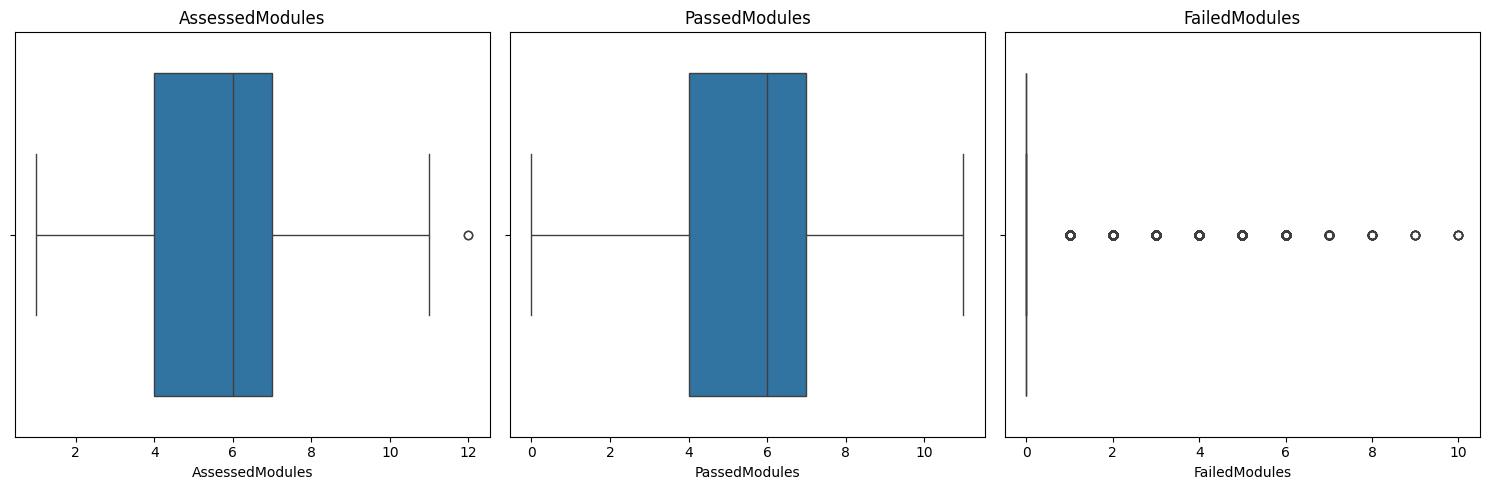

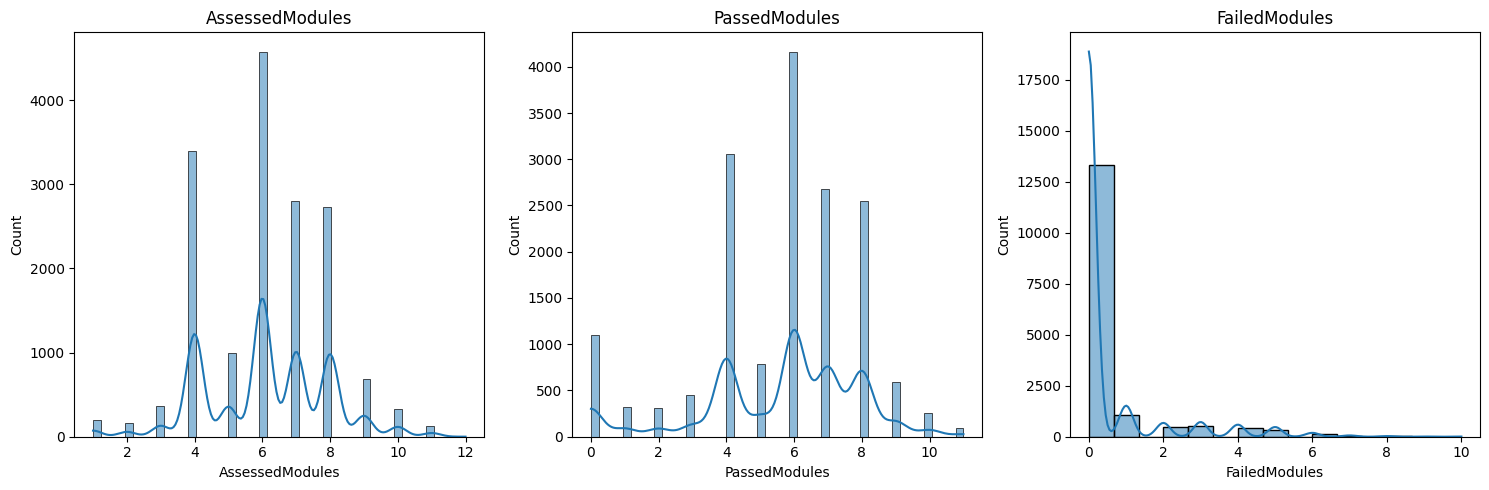

In [ ]:
# To decide on an appropriate imputation method, we first need examine the distribution of features with missing values to determine whether the mean, median, or mode is the most suitable replacement

over_two_columns = df_s3[["AssessedModules", "PassedModules", "FailedModules"]].columns

# Boxplot
plt.figure(figsize=(15, 5))

for i, over_two_column in enumerate(over_two_columns):
  plt.subplot(1, 3, i+1)
  sns.boxplot(
      data = X_train,
      x = over_two_column
  )
  plt.title(over_two_column)

plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(15, 5))

for i, over_two_column in enumerate(over_two_columns):
  plt.subplot(1, 3, i+1)
  sns.histplot(
      data = X_train,
      x = over_two_column,
      kde = True
  )
  plt.title(over_two_column)

plt.tight_layout()
plt.show()

Analysing the distribution:
- AssessedModules has one outlier, median is more robust, so we'll use median
- PassedModules shows no significant outliers, mean is appropriate
- FailedModules contains many outliers, median is the safer choice

In [ ]:
# Lets imput the null rows

from sklearn.impute import SimpleImputer

median_cols = ["AssessedModules", "FailedModules"]
mean_cols = ["PassedModules"]

# Median imputer
median_imputer = SimpleImputer(strategy = "median")
median_imputer.fit(X_train[median_cols])

X_train[median_cols] = median_imputer.transform(X_train[median_cols])
X_val[median_cols] = median_imputer.transform(X_val[median_cols])
X_test[median_cols] = median_imputer.transform(X_test[median_cols])

# Mean imputer
mean_imputer = SimpleImputer(strategy = "mean")
mean_imputer.fit(X_train[mean_cols])

X_train[mean_cols] = mean_imputer.transform(X_train[mean_cols])
X_val[mean_cols] = mean_imputer.transform(X_val[mean_cols])
X_test[mean_cols] = mean_imputer.transform(X_test[mean_cols])

print(f"X train null summary:\n{X_train.isnull().sum()}\n")
print(f"X val null summary:\n{X_val.isnull().sum()}\n")
print(f"X test null summary:\n{X_test.isnull().sum()}\n")

X train null summary:
CentreName                0
BookingType               0
LeadSource                0
Gender                    0
Nationality               0
CourseLevel               0
CourseName                0
IsFirstIntake             0
AssessedModules           0
PassedModules             0
FailedModules             0
ProgressionUniversity     0
AuthorisedAbsenceCount    0
Age                       0
dtype: int64

X val null summary:
CentreName                0
BookingType               0
LeadSource                0
Gender                    0
Nationality               0
CourseLevel               0
CourseName                0
IsFirstIntake             0
AssessedModules           0
PassedModules             0
FailedModules             0
ProgressionUniversity     0
AuthorisedAbsenceCount    0
Age                       0
dtype: int64

X test null summary:
CentreName                0
BookingType               0
LeadSource                0
Gender                    0
Nationality  

In [ ]:
# Before one-hot encoding, check data types once again

X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17892 entries, 5723 to 14544
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CentreName              17892 non-null  object 
 1   BookingType             17892 non-null  object 
 2   LeadSource              17892 non-null  object 
 3   Gender                  17892 non-null  int64  
 4   Nationality             17892 non-null  object 
 5   CourseLevel             17892 non-null  float64
 6   CourseName              17892 non-null  object 
 7   IsFirstIntake           17892 non-null  int64  
 8   AssessedModules         17892 non-null  float64
 9   PassedModules           17892 non-null  float64
 10  FailedModules           17892 non-null  float64
 11  ProgressionUniversity   17892 non-null  object 
 12  AuthorisedAbsenceCount  17892 non-null  float64
 13  Age                     17892 non-null  int64  
dtypes: float64(5), int64(3), object(6)
memor

In [ ]:
# One-hot encoding for all other categorical data (excluding the ones with bool, float, or int)

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
ohe_columns = X_train.select_dtypes(include=["object"]).columns

ohe.fit(X_train[ohe_columns])

X_train_ohe = pd.DataFrame(
    ohe.transform(X_train[ohe_columns]),
    columns = ohe.get_feature_names_out(ohe_columns),
    index = X_train.index
)
X_val_ohe = pd.DataFrame(
    ohe.transform(X_val[ohe_columns]),
    columns = ohe.get_feature_names_out(ohe_columns),
    index = X_val.index
)
X_test_ohe = pd.DataFrame(
    ohe.transform(X_test[ohe_columns]),
    columns = ohe.get_feature_names_out(ohe_columns),
    index = X_test.index
)

num_cols_train = X_train.drop(columns=ohe_columns)
num_cols_val = X_val.drop(columns=ohe_columns)
num_cols_test = X_test.drop(columns=ohe_columns)

X_train = pd.concat([num_cols_train, X_train_ohe], axis=1)
X_val = pd.concat([num_cols_val, X_val_ohe], axis=1)
X_test = pd.concat([num_cols_test, X_test_ohe], axis=1)

print(f"X train shape: {X_train.shape}")
print(f"X val shape: {X_val.shape}")
print(f"X test shape: {X_test.shape}")

X_train.head()

X train shape: (17892, 381)
X val shape: (1988, 381)
X test shape: (4971, 381)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Gender,CourseLevel,IsFirstIntake,AssessedModules,PassedModules,FailedModules,AuthorisedAbsenceCount,Age,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
5723,0,0.0,0,6.0,6.0,0.0,21.0,22,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15820,1,0.0,0,7.0,7.0,0.0,0.0,25,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5735,1,1.0,0,7.0,7.0,0.0,0.0,30,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3470,1,3.0,0,7.0,7.0,0.0,9.0,27,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20608,1,0.0,0,8.0,8.0,0.0,81.0,37,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


CompletedCourse
1    85.48
0    14.52
Name: proportion, dtype: float64


<Axes: xlabel='CompletedCourse', ylabel='count'>

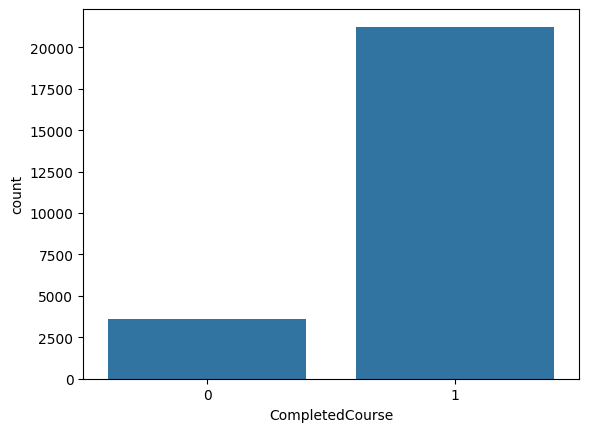

In [ ]:
# Check if target variable imbalance

print(y.value_counts(normalize=True).multiply(100).round(2))

sns.countplot(
    x = y
)

The tagret data is imbalanced, 85% (positive) and 15% (negative)

**XGBoost**

XGBoost model with n_estimators: 100, learning_rate: 0.1, max_depth: 3
Accuracy: 0.9871253268959967
Precision: 0.9881035689293212
Recall: 0.9969404565780183
AUC: 0.9985870881139377
Confusion Matrix: [[ 671   51]
 [  13 4236]]


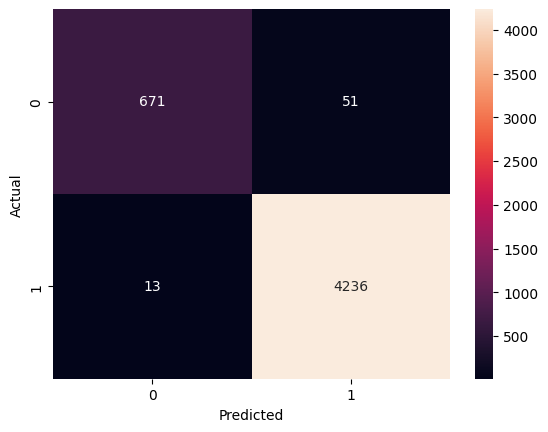

In [ ]:
# Testing the XGBoost Stage 3 baseline performance, with the same hyperparameters from Stage 2

xgb_model_s3_v1 = xgb_model(X_train, y_train, X_test, y_test, n_estimators = 100, learning_rate = 0.1, max_depth = 3)

XGBoost baseline model comparison between Stage 3 vs Stage 2 dataset (both evaluated on test set)

In [ ]:
y_prob = xgb_model_s3_v1.predict_proba(X_test)[:, 1]
y_pred = xgb_model_s3_v1.predict(X_test)
y_true = y_test

xgb_auc_s3_v1 = roc_auc_score(y_true, y_prob)
xgb_accuracy_s3_v1 = accuracy_score(y_true, y_pred)
xgb_precision_s3_v1 = precision_score(y_true, y_pred)
xgb_recall_s3_v1 = recall_score(y_true, y_pred)
tn_s3_v1, fp_s3_v1, fn_s3_v1, tp_s3_v1 = confusion_matrix(y_true, y_pred).ravel()

xgb_comparison_s2_s3_df = pd.DataFrame([
    {"Stage": 2, "model": "xgb_model_s2_v1", "n_estimators": 100, "learning_rate": 0.1, "max_depth": 3, "auc": 0.887718, "accuracy": 0.894991, "precision": 0.917919, "recall": 0.963285, "tn": 356, "fp": 366, "fn": 156, "tp": 4093},
    {"Stage": 3, "model": "xgb_model_s3_v1", "n_estimators": xgb_model_s3_v1.n_estimators, "learning_rate": xgb_model_s3_v1.learning_rate, "max_depth": xgb_model_s3_v1.max_depth, "auc": xgb_auc_s3_v1, "accuracy": xgb_accuracy_s3_v1, "precision": xgb_precision_s3_v1, "recall": xgb_recall_s3_v1, "tn": tn_s3_v1, "fp": fp_s3_v1, "fn": fn_s3_v1, "tp": tp_s3_v1}
])

xgb_comparison_s2_s3_df

,Stage,model,n_estimators,learning_rate,max_depth,auc,accuracy,precision,recall,tn,fp,fn,tp
0,2,xgb_model_s2_v1,100,0.1,3,0.887718,0.894991,0.917919,0.963285,356,366,156,4093
1,3,xgb_model_s3_v1,100,0.1,3,0.998587,0.987125,0.988104,0.996940,671,51,13,4236


Comparing the results from Stage 2 and Tsage 3, both models share identical hyperparameters (100 estimators, learning rate 0.1, max depth 3), making this a clean comparison of the impact of the Stage 3 dataset.

Stage 3 v1 model is the better model by a significant margin, achieving an AUC of 0.999 near perfect discrimination. This is a dramatic improvement over Stage 2's 0.888, alongside substantially higher accuracy (0.987), precision (0.988), and recall (0.997). The scale of improvement strongly suggests that the additional features introduced in Stage 3 (AssessedModules, FailedModules, and PassedModules) provide an exceptionally strong predictive signal, making course completion almost perfectly predictable.

**XGBoost - Hyperparamter tuning**

Since the baseline model (v1) already achieved a high AUC, it is possible that the model has reached or is close to its performance ceiling. As a result, any improvements from hyperparameter tuning are likely to be marginal, and some tuned models may even perform slightly worse than the baseline.

XGBoost model with n_estimators: 200, learning_rate: 0.05, max_depth: 3
Accuracy: 0.9874245472837022
Precision: 0.9894736842105263
Recall: 0.9958799293702177
AUC: 0.997954220984866
Confusion Matrix: [[ 271   18]
 [   7 1692]]


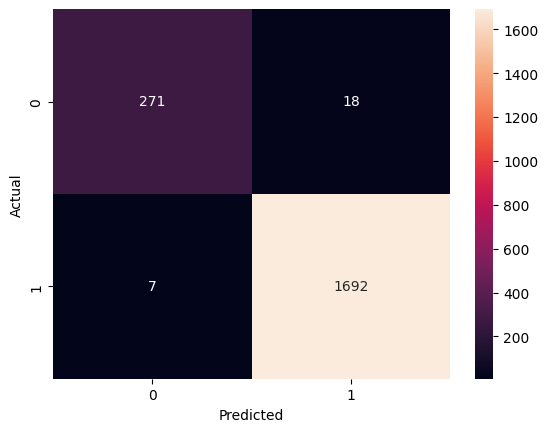

In [ ]:
xgb_model_s3_v2 = xgb_model(X_train, y_train, X_val, y_val, n_estimators = 200, learning_rate = 0.05, max_depth = 3)

XGBoost model with n_estimators: 200, learning_rate: 0.05, max_depth: 5
Accuracy: 0.9874245472837022
Precision: 0.9900468384074942
Recall: 0.9952913478516775
AUC: 0.9985560404960379
Confusion Matrix: [[ 272   17]
 [   8 1691]]


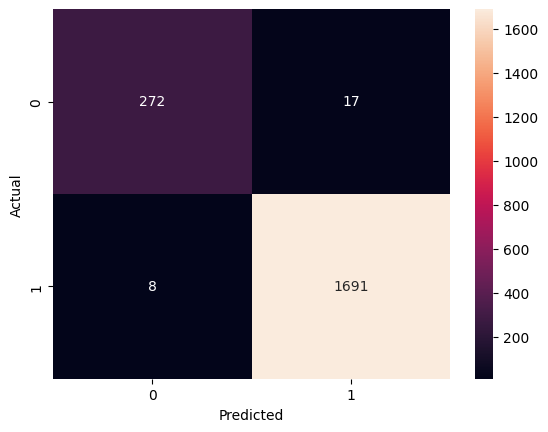

In [ ]:
xgb_model_s3_v3 = xgb_model(X_train, y_train, X_val, y_val, n_estimators = 200, learning_rate = 0.05, max_depth = 5)

XGBoost model with n_estimators: 400, learning_rate: 0.05, max_depth: 5
Accuracy: 0.9889336016096579
Precision: 0.9917888563049854
Recall: 0.9952913478516775
AUC: 0.9989755830317447
Confusion Matrix: [[ 275   14]
 [   8 1691]]


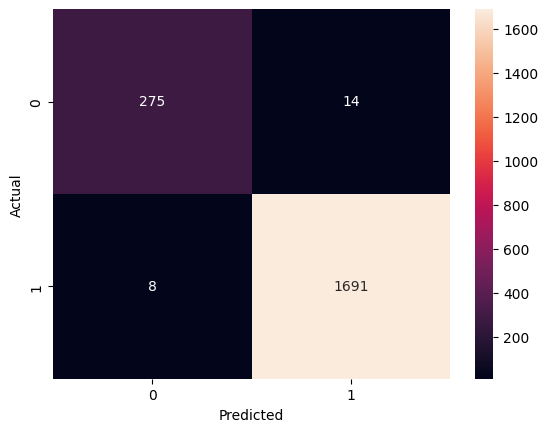

In [ ]:
xgb_model_s3_v4 = xgb_model(X_train, y_train, X_val, y_val, n_estimators = 400, learning_rate = 0.05, max_depth = 5)

Compared to Stage 1 & 2, not as many attempts were made on Stage 3, as the baseline model AUC is already at 0.9986

In [ ]:
# Let's compare all the tuned models, that were evaluated on the validation dataset

models = {
    "v2 on val": xgb_model_s3_v2,
    "v3 on val": xgb_model_s3_v3,
    "v4 on val": xgb_model_s3_v4
}

results = []

for name, model in models.items():

  y_prob = model.predict_proba(X_val)[:, 1]
  y_pred = model.predict(X_val)
  y_true = y_val

  tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

  results.append({
      "model": name,
      "n_estimators": model.n_estimators,
      "learning_rate": model.learning_rate,
      "max_depth": model.max_depth,
      "auc": roc_auc_score(y_true, y_prob),
      "accuracy": accuracy_score(y_true, y_pred),
      "precision": precision_score(y_true, y_pred),
      "recall": recall_score(y_true, y_pred),
      "tn": tn,
      "fp": fp,
      "fn": fn,
      "tp": tp
  })

pd.DataFrame(results)

,model,n_estimators,learning_rate,max_depth,auc,accuracy,precision,recall,tn,fp,fn,tp
0,v2 on val,200,0.05,3,0.997954,0.987425,0.989474,0.995880,271,18,7,1692
1,v3 on val,200,0.05,5,0.998556,0.987425,0.990047,0.995291,272,17,8,1691
2,v4 on val,400,0.05,5,0.998976,0.988934,0.991789,0.995291,275,14,8,1691


**v4** achieves the highest AUC at 0.999, with 400 estimators, learning rate 0.05, and max depth 5.

That said, all three models are already performing at near-perfect levels, the AUC spread across v2 to v4 is only ~0.001, making the differences practically negligible. The marginal gains from tuning are unsurprising given the baseline was already at 0.999. The more meaningful story here is the exceptional performance of Stage 3 as a whole rather than any individual configuration difference.

XGBoost model with n_estimators: 400, learning_rate: 0.05, max_depth: 5
Accuracy: 0.9911486622409977
Precision: 0.9929660023446659
Recall: 0.9967051070840197
AUC: 0.999212296326527
Confusion Matrix: [[ 692   30]
 [  14 4235]]


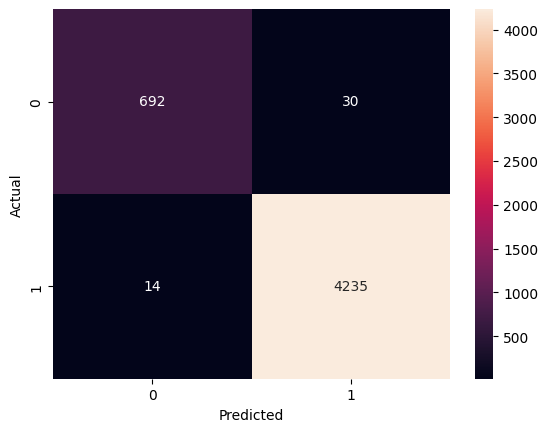

In [ ]:
# Evaluting the best model (v4) on test data

xgb_model_s3_v4 = xgb_model(X_train, y_train, X_test, y_test, n_estimators = 400, learning_rate = 0.05, max_depth = 5)

In [ ]:
# Now we'll compare v1 (baseline model) with v4 (evaluated on the test set this time)
# Before vs after hyperparameter tuning

models = {
    "v1 in test (Baseline)": xgb_model_s3_v1,
    "v4 in test": xgb_model_s3_v4
}

results = []

for name, model in models.items():

  y_prob = model.predict_proba(X_test)[:, 1]
  y_pred = model.predict(X_test)
  y_true = y_test

  tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

  results.append({
      "model": name,
      "n_estimators": model.n_estimators,
      "learning_rate": model.learning_rate,
      "max_depth": model.max_depth,
      "auc": roc_auc_score(y_true, y_prob),
      "accuracy": accuracy_score(y_true, y_pred),
      "precision": precision_score(y_true, y_pred),
      "recall": recall_score(y_true, y_pred),
      "tn": tn,
      "fp": fp,
      "fn": fn,
      "tp": tp
  })

pd.DataFrame(results)

,model,n_estimators,learning_rate,max_depth,auc,accuracy,precision,recall,tn,fp,fn,tp
0,v1 in test (Baseline),100,0.10,3,0.998587,0.987125,0.988104,0.996940,671,51,13,4236
1,v4 in test,400,0.05,5,0.999212,0.991149,0.992966,0.996705,692,30,14,4235


The baseline model (v1) achieved an AUC of 0.9986 on the test set. After tuning, v4 improved marginally to 0.9990 on the validation set, and notably increased slightly further to 0.9992 on the test set, a rare case where test performance exceeds validation performance.

Unlike the Stage 1 and Stage 2 findings where test AUC dropped below validation, Stage 3 shows consistent and stable performance across all sets, with essentially no generalisation gap. This further reinforces that the Stage 3 dataset contains exceptionally strong predictive signal, and the model generalises near-perfectly to unseen data.

XGBoost - Feature Importance

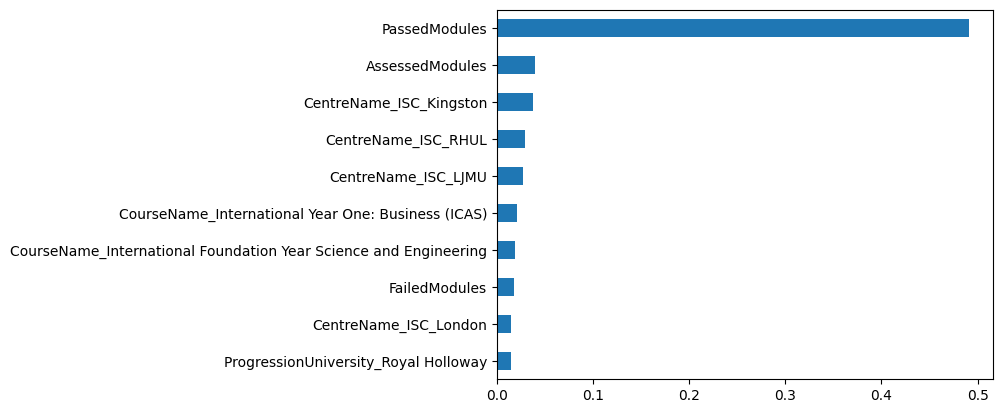

In [ ]:
# Looking into the best Stage 2 model - v4

feature_importance_s3 = pd.Series(xgb_model_s3_v4.feature_importances_, index=X_train.columns).sort_values()

# To only show the top 10 most important features
feature_importance_s3.tail(10).plot.barh()
plt.show()

PassedModules dominates overwhelmingly, with an importance score of almost 0.5 more than ten times that of any other feature. This alone likely explains the near-perfect AUC seen in Stage 3, as the number of modules a student has passed is an exceptionally strong predictor of course completion.

AssessedModules is a distant second, followed by centre-based features (Kingston, RHUL, LJMU) and course name features, all with very similar and modest importance scores. FailedModules also appears, though with limited impact relative to PassedModules.

This feature importance profile makes intuitive sense, a student who has passed most of their modules is almost certain to complete the course, making PassedModules a near-direct proxy for the target variable.

Stage 3 Feature Importance vs Stage 2 Feature Importance

---

The most striking difference is the introduction of PassedModules, AssessedModules, and FailedModules in Stage 3. PassedModules immediately dominates at ~0.47, dwarfing every other feature and fundamentally shifting the model's predictive structure. AssessedModules ranks second at ~0.025, while FailedModules appears further down with modest importance. These three new features collectively displace nationality as the primary signal, which dominated Stage 2.

In Stage 2, Nationality_Bangladeshi and Nationality_Indian jointly led at ~0.200, with centre features supporting. In Stage 3, nationality features drop out of the top 10 entirely, replaced by module-based and centre features such as Kingston, RHUL, and LJMU, centres that were not prominent in Stage 2.

This shift suggests that once module performance data is available, demographic features become far less relevant to the model.

Similar to Stage 1 & 2, we will use a SHAP violin plot in Stage 3 to better understand the impact and direction of the most important features.

**XGBoost - SHAP**

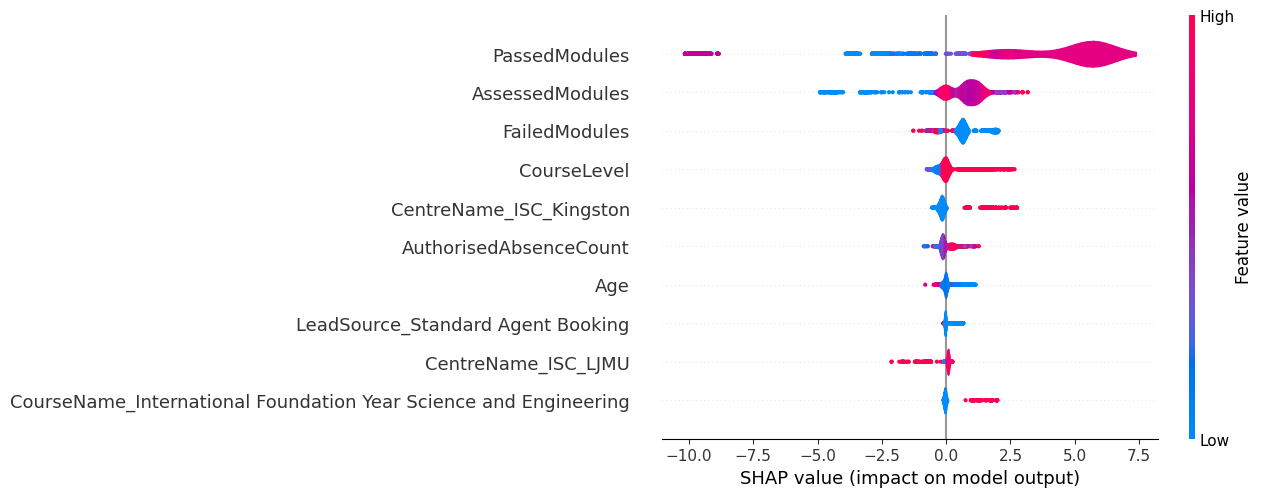

In [ ]:
import shap
shap.initjs()

shap_ex_s3 = shap.TreeExplainer(xgb_model_s3_v4)
vals_s3 = shap_ex_s3(X_test)

# Plotting the violing chart to see importance and direction of each feature
shap.plots.violin(vals_s3, max_display=10)

Comparing Stage 3 SHAP vs Stage 3 Feature Importance

---

Both methods identify PassedModules as the dominant feature by a large margin. The SHAP plot further reveals the directionality: mid-to-high values (pink-red) push predictions strongly positive (up to ~7.5), confirming that students with more passed modules are overwhelmingly likely to complete. Conversely, low values (blue) strongly push predictions negative, indicating that having few passed modules is a near-certain signal of non-completion. This wide spread helps explain the near-perfect AUC observed in Stage 3.

However, there is a small cluster of pink–red points at extreme negative SHAP values, suggesting that a small proportion of students still fail despite having passed modules. This indicates that while PassedModules is highly predictive, it does not guarantee course completion, which is consistent with real-world expectations.

AssessedModules ranks second in both, with high values clustering positively in SHAP, more assessed modules correlates with higher completion likelihood.

The key difference between the two is FailedModules, it doesn't appear in the feature importance top 10 but ranks third in SHAP, suggesting it carries meaningful directional impact that feature importance underestimates. High failed modules unsurprisingly push predictions negative.

AuthorisedAbsenceCount appears in SHAP but not in feature importance, consistent with the Stage 2 finding where SHAP surfaced it as more impactful than feature importance suggested.

CourseLevel, CentreName_ISC_Kingston, Age, and LeadSource_Standard Agent Booking appear in SHAP with modest spreads, indicating limited but present directional influence.

Overall, SHAP provides a richer picture, particularly in surfacing FailedModules and AuthorisedAbsenceCount as meaningful signals that feature importance alone understates.

Comparing Stage 3 SHAP vs Stage 2 SHAP

---

Comparing the SHAP plots from Stage 2 and Stage 3 reveals a substantial shift in feature importance after introducing the three additional academic performance variables: PassedModules, AssessedModules, and FailedModules.

In Stage 2, the model relies primarily on behavioural and demographic features. AuthorisedAbsenceCount emerges as the most influential predictor, with higher absence counts pushing predictions toward non-completion. Other features such as nationality indicators, course level, centre location, gender, and age contribute to the predictions, but their overall impact remains relatively moderate.

In Stage 3, the introduction of PassedModules, AssessedModules, and FailedModules dramatically changes the feature importance landscape. PassedModules becomes the overwhelmingly dominant predictor, with very high SHAP values pushing predictions strongly toward completion. This indicates that students who have passed more modules are significantly more likely to complete their course. AssessedModules also shows a positive contribution, suggesting that students who attempt more assessments are more likely to progress. In contrast, FailedModules tends to push predictions toward non-completion.

The magnitude of SHAP values in Stage 3 is substantially larger than in Stage 2, highlighting how strongly academic performance variables influence the model's predictions. This explains the significant improvement in model performance observed in Stage 3, including the near-perfect AUC.

Overall, the results suggest that once direct indicators of academic progress are included, they dominate the predictive signal, while demographic and administrative features become comparatively less influential.

**Neural Network**

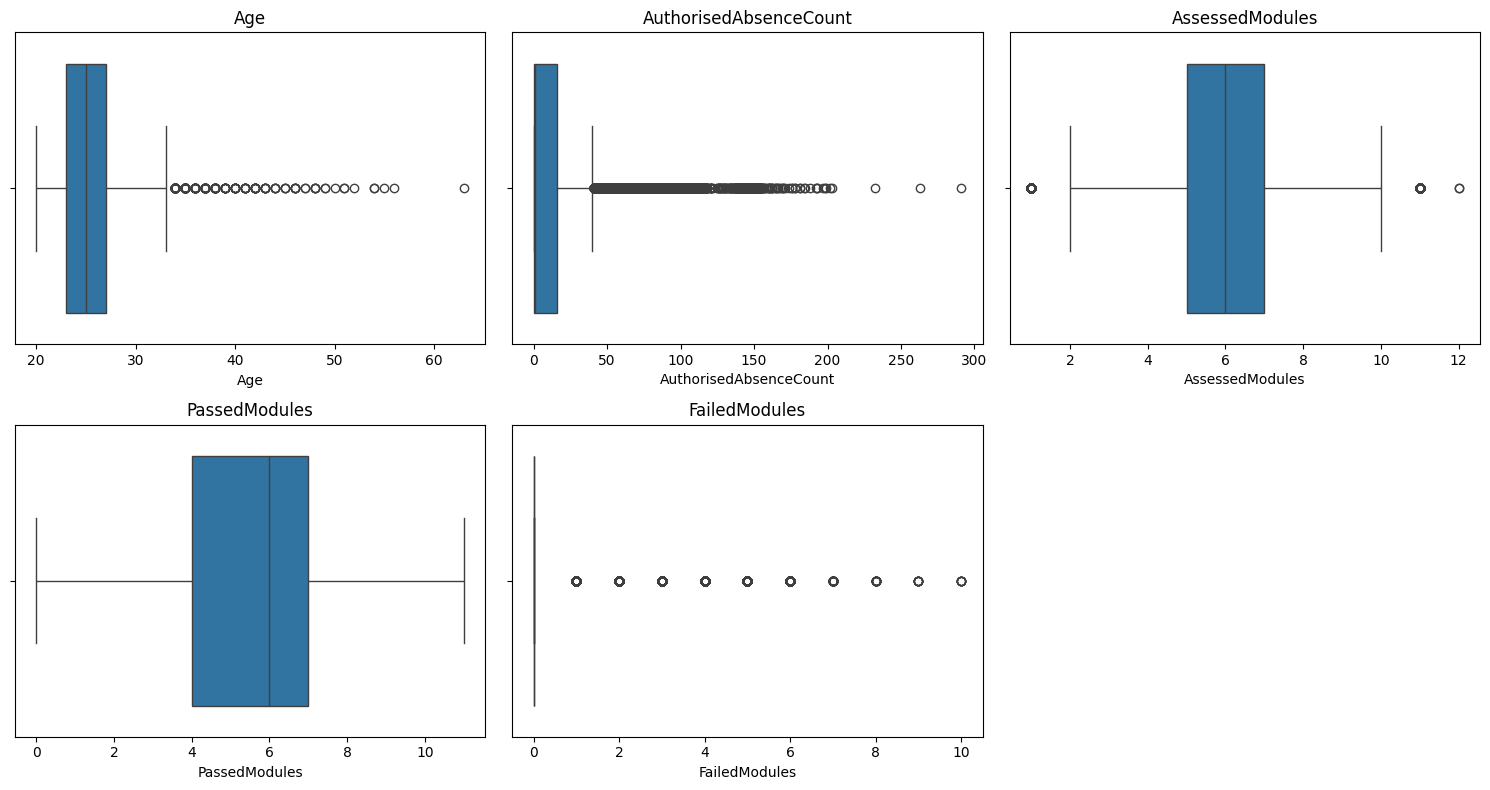

In [ ]:
# Check for outliers on continuous features before scaling

num_columns = X_train[["Age", "AuthorisedAbsenceCount", "AssessedModules", "PassedModules", "FailedModules"]]

plt.figure(figsize=(15, 8))

for i, num_column in enumerate(num_columns):
  plt.subplot(2, 3, i+1)
  sns.boxplot(
      data = X_train,
      x = X_train[num_column]
  )
  plt.title(num_column)

plt.tight_layout()
plt.show()

In [ ]:
# Since there are too many ouliers in Age, AuthorisedAbsenceCount, and FailedModules, we'll use RobustScaler
# For PassedModules and AssessedModules, we'll use StandardScaler instead, since there are little to no outliers

from sklearn.preprocessing import RobustScaler

rscaler = RobustScaler()
sscaler = StandardScaler()

#RobustScaler
X_train[["Age", "AuthorisedAbsenceCount", "FailedModules"]] = rscaler.fit_transform(X_train[["Age", "AuthorisedAbsenceCount", "FailedModules"]])
X_val[["Age", "AuthorisedAbsenceCount", "FailedModules"]] = rscaler.transform(X_val[["Age", "AuthorisedAbsenceCount", "FailedModules"]])
X_test[["Age", "AuthorisedAbsenceCount", "FailedModules"]] = rscaler.transform(X_test[["Age", "AuthorisedAbsenceCount", "FailedModules"]])

#StandardScaler
X_train[["PassedModules", "AssessedModules"]] = sscaler.fit_transform(X_train[["PassedModules", "AssessedModules"]])
X_val[["PassedModules", "AssessedModules"]] = sscaler.transform(X_val[["PassedModules", "AssessedModules"]])
X_test[["PassedModules", "AssessedModules"]] = sscaler.transform(X_test[["PassedModules", "AssessedModules"]])

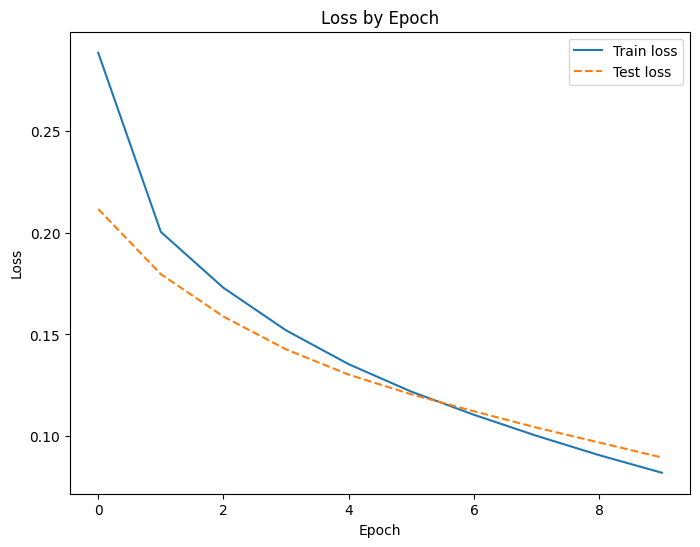

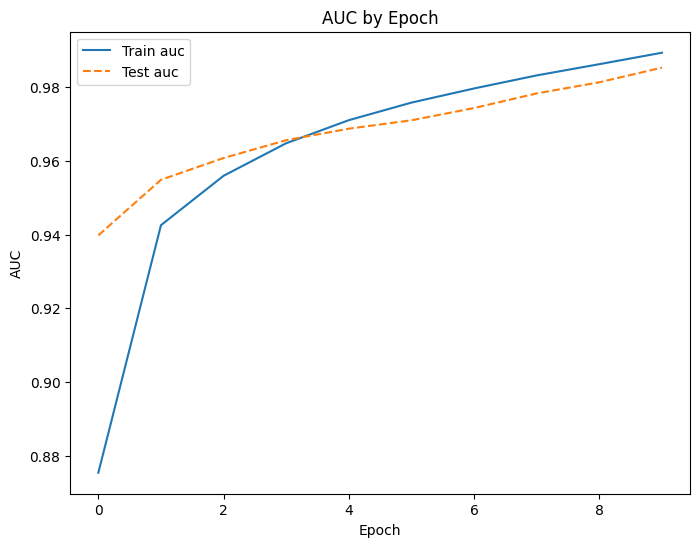

Accuracy: 0.9674109837054918
Precision: 0.968370387348155
Recall: 0.9943516121440339
AUC: 0.9828972305036414
Confusion Matrix:
[[ 584  138]
 [  24 4225]]


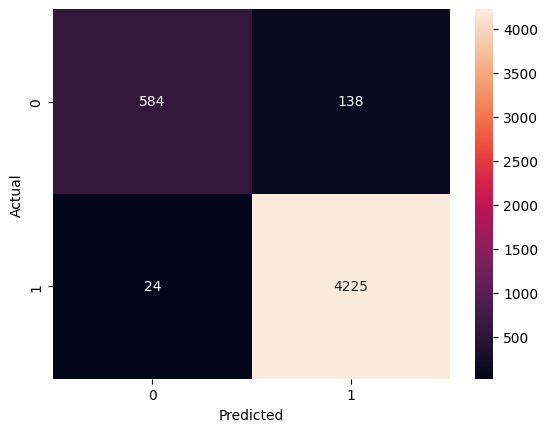

In [ ]:
# Testing the Neural Network Stage 3 baseline performance, with the same hyperparameters from Stage 2

nn_model_s3_v1, history_s3_v1 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 10,
    batch_size = 32,
    optimizer = "adam",
    hidden_layers = 1,
    units = 10,
    eval_name = "Test"
)

y_test_prob_s3_v1 = nn_model_s3_v1.predict(X_test, verbose = 0).flatten()
auc_s3_v1, loss_s3_v1, accuracy_s3_v1, precision_s3_v1, recall_s3_v1, tn_s3_v1, fp_s3_v1, fn_s3_v1, tp_s3_v1 = evaluate_nn_model(y_test, y_test_prob_s3_v1)

Neural Network baseline model comparison between Stage 2 vs Stage 1 dataset (both evaluated on test set)

In [ ]:
nn_comparison_s3_s2_df = pd.DataFrame([
    {"Stage": 2, "model": "nn_model_s2_v1", "epochs": 10, "batch_size": 32, "optimizer": "adam", "hidden_layers": 1, "units": 10, "auc": 0.878853, "loss": 0.268323, "accuracy": 0.897003, "precision": 0.922451, "recall": 0.960226, "tn": 379, "fp": 343, "fn": 169, "tp": 4080},
    {"Stage": 3, "model": "nn_model_s3_v1", "epochs": 10, "batch_size": 32, "optimizer": "adam", "hidden_layers": 1, "units": 10, "auc": auc_s3_v1, "loss": loss_s3_v1, "accuracy": accuracy_s3_v1, "precision": precision_s3_v1, "recall": recall_s3_v1, "tn": tn_s3_v1, "fp": fp_s3_v1, "fn": fn_s3_v1, "tp": tp_s3_v1}
])

nn_comparison_s3_s2_df

,Stage,model,epochs,batch_size,optimizer,hidden_layers,units,auc,loss,accuracy,precision,recall,tn,fp,fn,tp
0,2,nn_model_s2_v1,10,32,adam,1,10,0.878853,0.268323,0.897003,0.922451,0.960226,379,343,169,4080
1,3,nn_model_s3_v1,10,32,adam,1,10,0.982897,0.101938,0.967411,0.968370,0.994352,584,138,24,4225


The baseline model in Stage 3 demonstrates a significant improvement over the Stage 2 baseline in terms of AUC. The Stage 2 model achieves an AUC of 0.879, indicating strong predictive performance. However, the Stage 3 model reaches an AUC of 0.983, representing a substantial increase in the model's ability to distinguish between students who complete the course and those who do not.

This improvement is largely driven by the inclusion of the additional academic performance features in Stage 3, namely PassedModules, AssessedModules, and FailedModules. These variables provide direct indicators of student academic progress, which appear to contain highly predictive information. As a result, the model is able to separate the two classes much more effectively, leading to the near-perfect AUC observed in Stage 3.

**Neural Network Hyperparameter tuning**

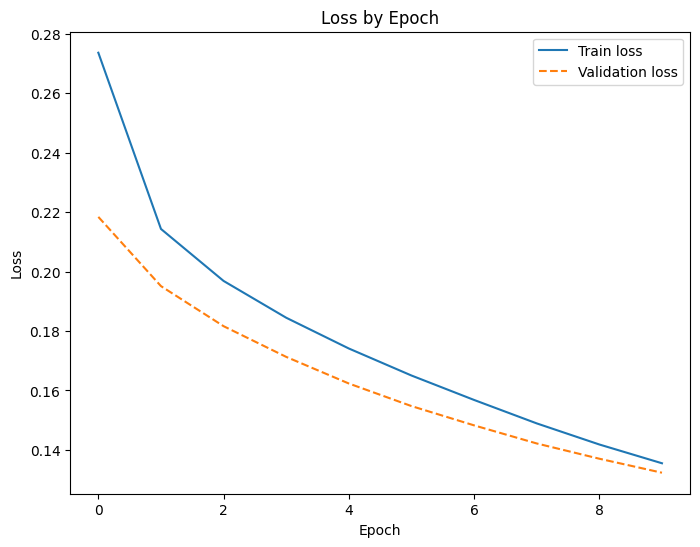

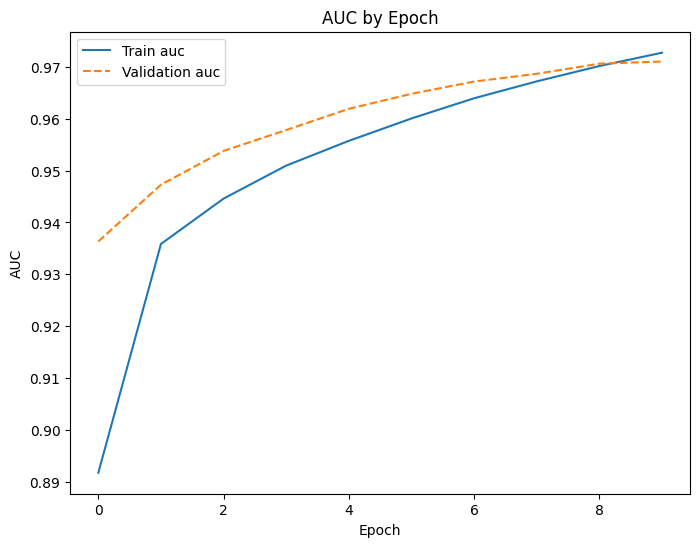

Accuracy: 0.960261569416499
Precision: 0.9692931633835458
Recall: 0.9846968805179518
AUC: 0.9726747465942719
Confusion Matrix:
[[ 236   53]
 [  26 1673]]


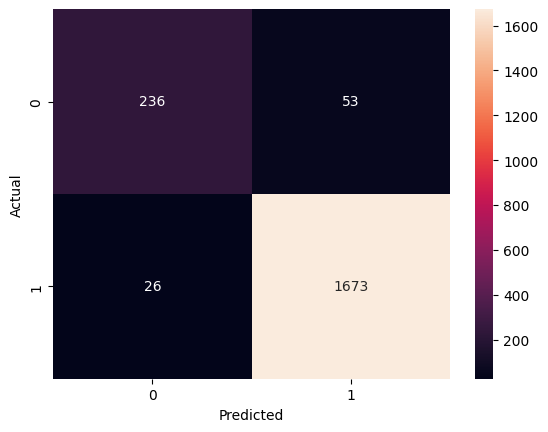

In [ ]:
nn_model_s3_v2, history_s3_v2 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 10,
    batch_size = 32,
    optimizer = "rmsprop",
    hidden_layers = 1,
    units = 10
)

y_val_prob_s3_v2 = nn_model_s3_v2.predict(X_val, verbose = 0).flatten()
auc_s3_v2, loss_s3_v2, accuracy_s3_v2, precision_s3_v2, recall_s3_v2, tn_s3_v2, fp_s3_v2, fn_s3_v2, tp_s3_v2 = evaluate_nn_model(y_val, y_val_prob_s3_v2)

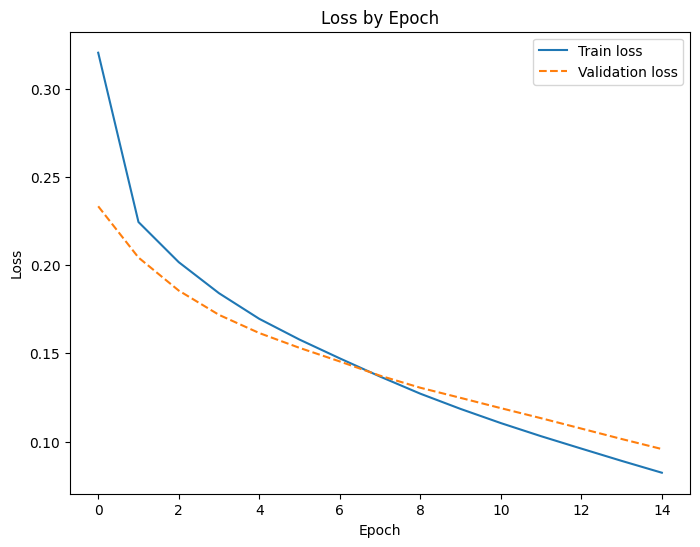

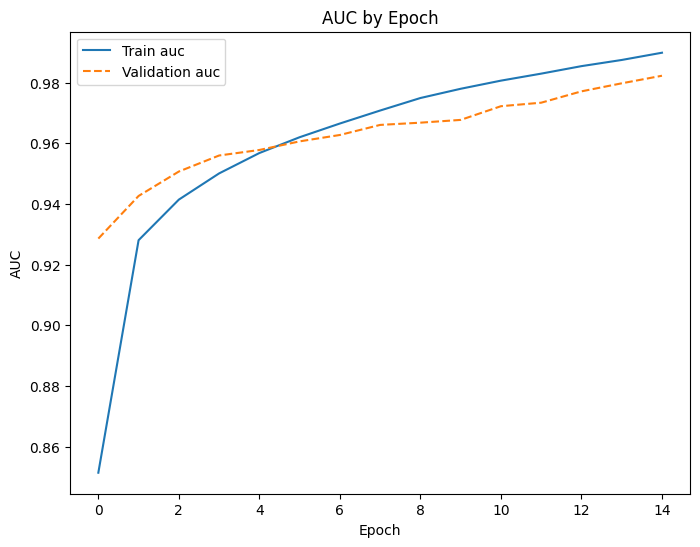

Accuracy: 0.971830985915493
Precision: 0.9740334679746105
Recall: 0.9935256032960565
AUC: 0.9828863304488088
Confusion Matrix:
[[ 244   45]
 [  11 1688]]


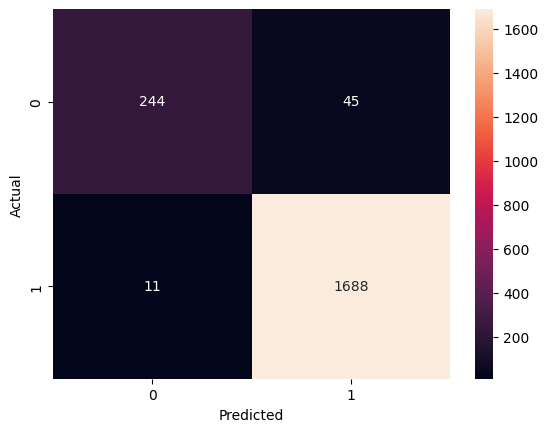

In [ ]:
nn_model_s3_v3, history_s3_v3 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 15,
    batch_size = 64,
    optimizer = "adam",
    hidden_layers = 1,
    units = 10
)

y_val_prob_s3_v3 = nn_model_s3_v3.predict(X_val, verbose = 0).flatten()
auc_s3_v3, loss_s3_v3, accuracy_s3_v3, precision_s3_v3, recall_s3_v3, tn_s3_v3, fp_s3_v3, fn_s3_v3, tp_s3_v3 = evaluate_nn_model(y_val, y_val_prob_s3_v3)

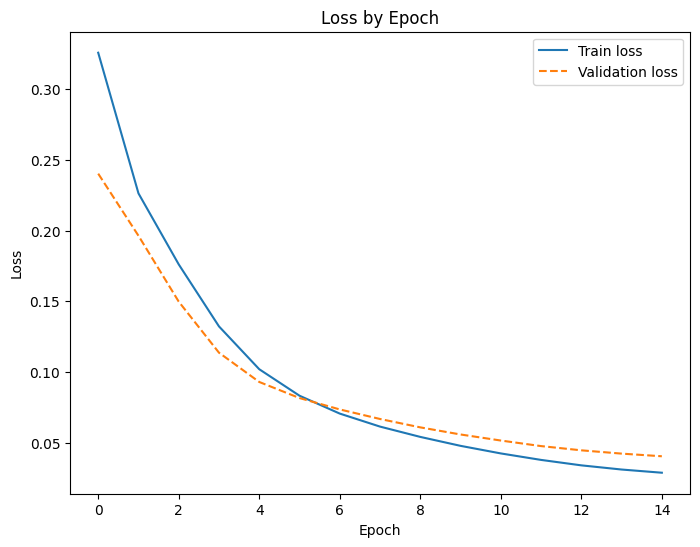

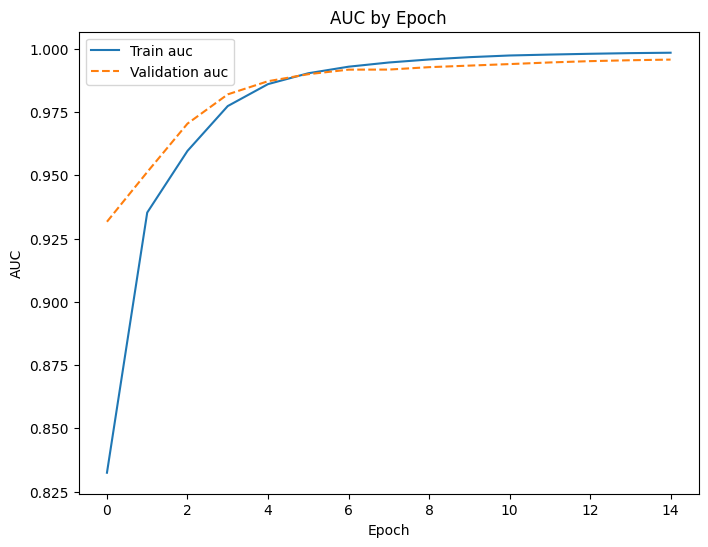

Accuracy: 0.9879275653923542
Precision: 0.9889083479276124
Recall: 0.9970570924072985
AUC: 0.9970876416210634
Confusion Matrix:
[[ 270   19]
 [   5 1694]]


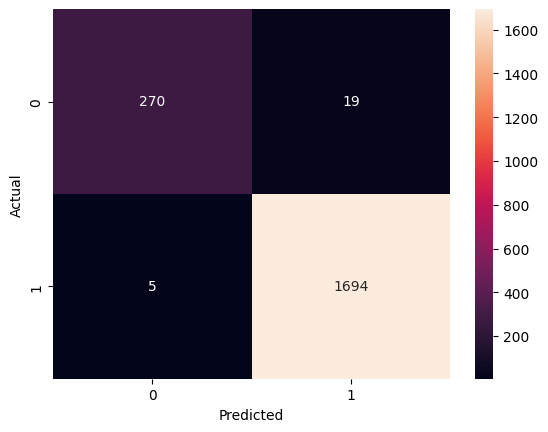

In [ ]:
nn_model_s3_v4, history_s3_v4 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 15,
    batch_size = 64,
    optimizer = "adam",
    hidden_layers = 2,
    units = 10
)

y_val_prob_s3_v4 = nn_model_s3_v4.predict(X_val, verbose = 0).flatten()
auc_s3_v4, loss_s3_v4, accuracy_s3_v4, precision_s3_v4, recall_s3_v4, tn_s3_v4, fp_s3_v4, fn_s3_v4, tp_s3_v4 = evaluate_nn_model(y_val, y_val_prob_s3_v4)

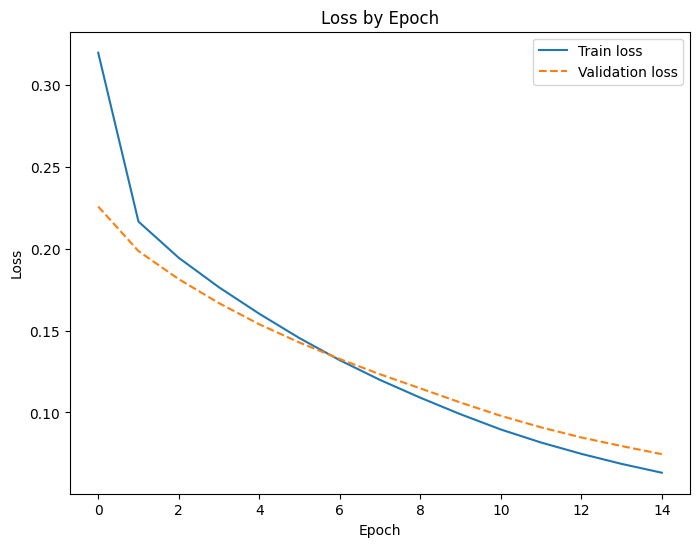

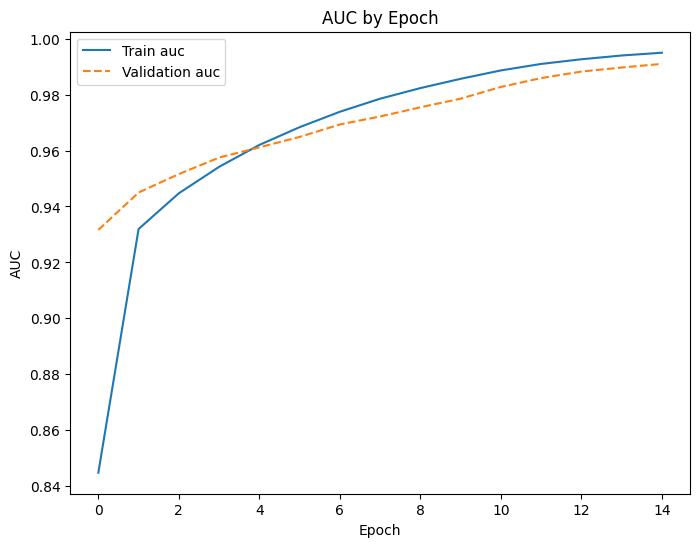

Accuracy: 0.9768611670020121
Precision: 0.978021978021978
Recall: 0.9952913478516775
AUC: 0.9917293095266706
Confusion Matrix:
[[ 251   38]
 [   8 1691]]


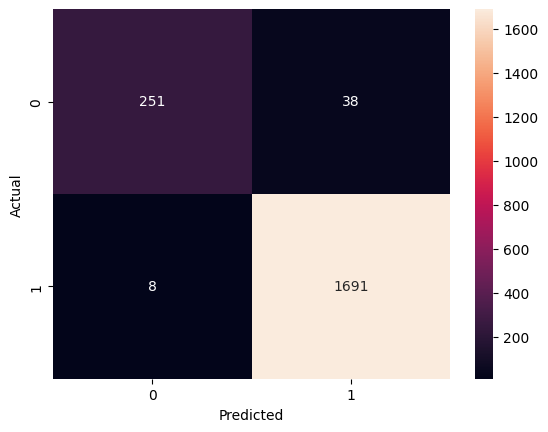

In [ ]:
nn_model_s3_v5, history_s3_v5 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 15,
    batch_size = 64,
    optimizer = "adam",
    hidden_layers = 1,
    units = 15
)

y_val_prob_s3_v5 = nn_model_s3_v5.predict(X_val, verbose = 0).flatten()
auc_s3_v5, loss_s3_v5, accuracy_s3_v5, precision_s3_v5, recall_s3_v5, tn_s3_v5, fp_s3_v5, fn_s3_v5, tp_s3_v5 = evaluate_nn_model(y_val, y_val_prob_s3_v5)

In [ ]:
# Now let's compare all the tuned models (v2-v5), which were evaluated on the validation dataset

nn_comparison_s3_df = pd.DataFrame([
    {"model": "nn_model_s3_v2", "epochs": 10, "batch_size": 32, "optimizer": "rmsprop", "hidden_layers": 1, "units": 10, "auc": auc_s3_v2, "loss": loss_s3_v2, "accuracy": accuracy_s3_v2, "precision": precision_s3_v2, "recall": recall_s3_v2, "tn": tn_s3_v2, "fp": fp_s3_v2, "fn": fn_s3_v2, "tp": tp_s3_v2},
    {"model": "nn_model_s3_v3", "epochs": 15, "batch_size": 64, "optimizer": "adam", "hidden_layers": 1, "units": 10, "auc": auc_s3_v3, "loss": loss_s3_v3, "accuracy": accuracy_s3_v3, "precision": precision_s3_v3, "recall": recall_s3_v3, "tn": tn_s3_v3, "fp": fp_s3_v3, "fn": fn_s3_v3, "tp": tp_s3_v3},
    {"model": "nn_model_s3_v4", "epochs": 15, "batch_size": 64, "optimizer": "adam", "hidden_layers": 2, "units": 10, "auc": auc_s3_v4, "loss": loss_s3_v4, "accuracy": accuracy_s3_v4, "precision": precision_s3_v4, "recall": recall_s3_v4, "tn": tn_s3_v4, "fp": fp_s3_v4, "fn": fn_s3_v4, "tp": tp_s3_v4},
    {"model": "nn_model_s3_v5", "epochs": 15, "batch_size": 64, "optimizer": "adam", "hidden_layers": 1, "units": 15, "auc": auc_s3_v5, "loss": loss_s3_v5, "accuracy": accuracy_s3_v5, "precision": precision_s3_v5, "recall": recall_s3_v5, "tn": tn_s3_v5, "fp": fp_s3_v5, "fn": fn_s3_v5, "tp": tp_s3_v5}
])

nn_comparison_s3_df

,model,epochs,batch_size,optimizer,hidden_layers,units,auc,loss,accuracy,precision,recall,tn,fp,fn,tp
0,nn_model_s3_v2,10,32,rmsprop,1,10,0.972675,0.132330,0.960262,0.969293,0.984697,236,53,26,1673
1,nn_model_s3_v3,15,64,adam,1,10,0.982886,0.095729,0.971831,0.974033,0.993526,244,45,11,1688
2,nn_model_s3_v4,15,64,adam,2,10,0.997088,0.040467,0.987928,0.988908,0.997057,270,19,5,1694
3,nn_model_s3_v5,15,64,adam,1,15,0.991729,0.074508,0.976861,0.978022,0.995291,251,38,8,1691


Several neural network configurations were tested in Stage 3 to evaluate the impact of different hyperparameters on model performance. Overall, all models achieved very high AUC values, indicating strong predictive capability.

Among the tested models, **v4** achieved the highest AUC of 0.997, outperforming the other configurations. This model uses 15 epochs, a batch size of 64, the Adam optimizer, two hidden layers, and 10 units, suggesting that increasing the network depth improved the model's ability to capture patterns in the data.

The remaining models also performed well, with v3 achieving an AUC of 0.983, v5 reaching 0.992, and v2 achieving 0.973. However, their performance remains slightly below that of v4.

Overall, based on AUC, **v4** is the best-performing model, demonstrating the strongest ability to distinguish between students who complete the course and those who do not.

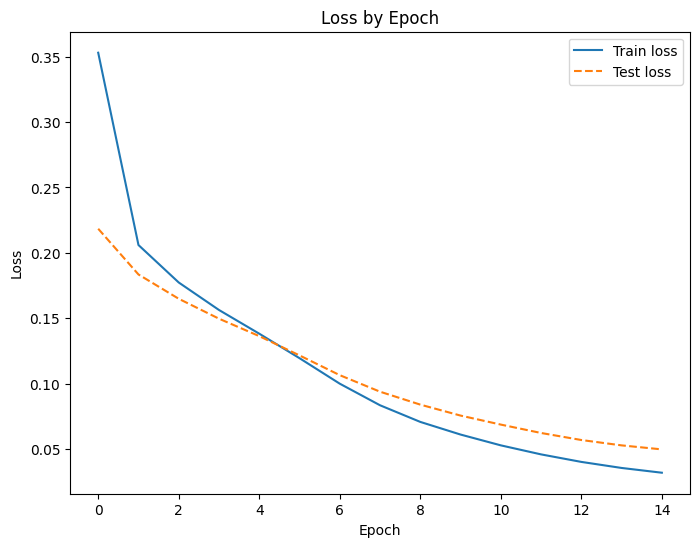

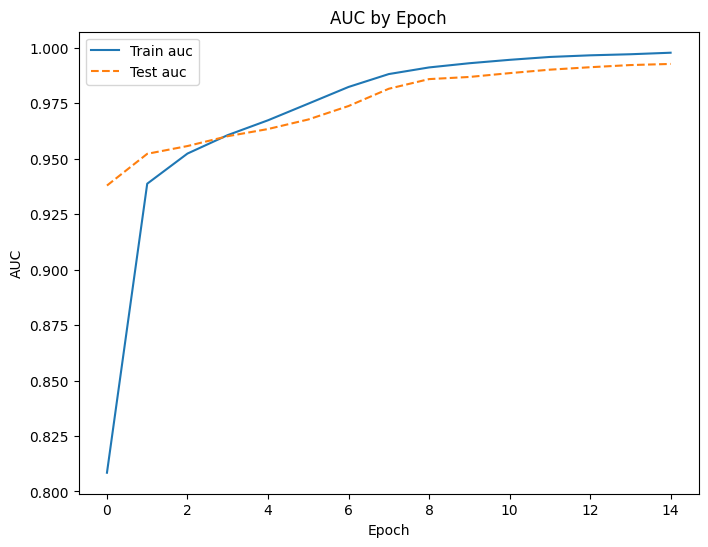

Accuracy: 0.9790786562059948
Precision: 0.9778648835600645
Recall: 0.9981172040480113
AUC: 0.9900335030761679
Confusion Matrix:
[[ 626   96]
 [   8 4241]]


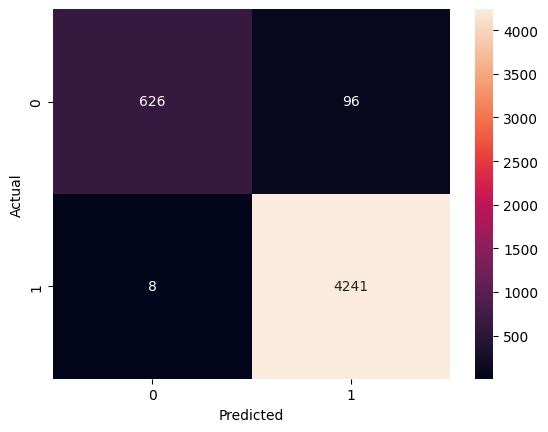

In [ ]:
# Now let's evaluate the best tuned model (v4) on test data this time

nn_model_s3_v4, history_s3_v4 = train_nn_model(
    X_train, y_train, X_val, y_val,
    epochs = 15,
    batch_size = 64,
    optimizer = "adam",
    hidden_layers = 2,
    units = 10,
    eval_name = "Test"
)

y_test_prob_s3_v4 = nn_model_s3_v4.predict(X_test, verbose = 0).flatten()
auc_s3_v4, loss_s3_v4, accuracy_s3_v4, precision_s3_v4, recall_s3_v4, tn_s3_v4, fp_s3_v4, fn_s3_v4, tp_s3_v4 = evaluate_nn_model(y_test, y_test_prob_s3_v4)

In [ ]:
# Compare the v1 (baseline model) vs v4 (evaluated on test dataset this time)

nn_final_comparison_df = pd.DataFrame([
    {"model": "nn_model_s3_v1", "epochs": 10, "batch_size": 32, "optimizer": "adam", "hidden_layers": 1, "units": 10, "auc": auc_s3_v1, "loss": loss_s3_v1, "accuracy": accuracy_s3_v1, "precision": precision_s3_v1, "recall": recall_s3_v1, "tn": tn_s3_v1, "fp": fp_s3_v1, "fn": fn_s3_v1, "tp": tp_s3_v1},
    {"model": "nn_model_s3_v4", "epochs": 15, "batch_size": 64, "optimizer": "adam", "hidden_layers": 2, "units": 10, "auc": auc_s3_v4, "loss": loss_s3_v4, "accuracy": accuracy_s3_v4, "precision": precision_s3_v4, "recall": recall_s3_v4, "tn": tn_s3_v4, "fp": fp_s3_v4, "fn": fn_s3_v4, "tp": tp_s3_v4}
])

nn_final_comparison_df

,model,epochs,batch_size,optimizer,hidden_layers,units,auc,loss,accuracy,precision,recall,tn,fp,fn,tp
0,nn_model_s3_v1,10,32,adam,1,10,0.982897,0.101938,0.967411,0.968370,0.994352,584,138,24,4225
1,nn_model_s3_v4,15,64,adam,2,10,0.990034,0.067406,0.979079,0.977865,0.998117,626,96,8,4241


The baseline model (v1) achieved an AUC of 0.983 on the test set, indicating very strong predictive performance. After hyperparameter tuning, model v4 achieved an AUC of 0.997 on the validation set, suggesting a noticeable improvement during model selection.

When evaluated on the test set, model v4 achieved an AUC of 0.990, which is slightly higher than the baseline model. This indicates that while the improvement over the baseline is relatively small, v4 still performs best overall, suggesting a modest gain from hyperparameter tuning.

# Declaration
By submitting your project, you indicate that the work is your own and has been created with academic integrity. Refer to the **Cambridge plagiarism regulations**.
